# 🛡 Deteção de Phishing e Spam — SMS & E-mail Corporativo

**Projeto Final · UC Aprendizagem Automática para Cibersegurança · 2025/2026**
ISCTE-Sintra · Licenciatura em TDAI · Prof. João Pedro Pavia Realizado por:
Guilherme Real nº124456, Ilie Iftime nº 112779, Marin Cepeleaga nº 123550

---
## Introdução

Este projeto desenvolve e avalia um sistema de deteção binária para mensagens indesejadas (spam) e tentativas de pshishing em SMS e email corporativo. Tendo como objetivo produzir um classificador robusto capaz de ser aplicado a um centro de operações de segurança (SOC), com ênfase na explicabilidade via SHAP e de acordo com a conformidade RGPD em vigor.
Os resultados apresentados incluem modelos, métricas, análises de erro, explicadores (SHAP), teste de vulnerabilidade adversarial.

## Âmbito:
Os domínios analisados foram as mensagens de SMS e-emails corporativos provenientes de duas fontes distintas, com a tarefa de treinar apartir destes modelos de classificação binários (ham vs spam/phishing), através de auxílio de métricas criadas por feature engineering os modelos  de análise de anómalias com OOD e os modelos de classificação e adversariais foram treinados.

Algumas limitações foram a quantidade de dados limitados para os modelos treinados, provando serem simples para arquiteturas como as LSTM em que o overfitting foi facilmente conseguido, por outro lado mantivemo-nos focados em features lingúisticas na ausência de outras, sendo as heurísticas finais excluirem HTML/URLs.

O entregável final irá ser reproduzível, contendo o notebook carregado, o file python com funções auxiliares, os outputs csv, .keras/.h5/joblib/etc.. dos modelos, pngs gráficos, html do dashboard e os 2 datasets.

## Motivação

O impacto prático consiste em realizar uma simulação para reduzir o risco operacional e carga humana em triagem de alertas, protegendo utilizadores e infraestruturas corporativas. Nesse sentido o desafio científico passa pela generalização através do cruzamento de domínios entre os textos curtos do 1º dataset (SMS) com os longos do 2º dataset (enron) de modo a ganhar robustez face a manipulações adversariais. 
A relevância académica deste projeto é conseguida aplicando técnica de ML clássicas como TF-IDF, Complement Naive Bayes e Linear SVC com redes recorrentes e métricas de explicabilidade.

## Questão de investigação
Como construir um classificador binário de spam/phishing que seja ao mesmo tempo operacionalmente aplicável em um SOC, compátivel com o RGPD e requisitos de privacidade, robusto o suficiente a ataques adversariais e capaz de generalizar entre SMS e emails e quais as featuras linguísticas e heurísticas que melhoram a deteção entre cenários de comprimentos de tokens variáveis, bem como se é possível medir e mitigiar as fragilidades face a ataques adversariais em modelos lineares e neuronais. Que trade-offs existem perante o desempenho e interpretabilidade?

## Metodologia

**1.** Bloco introdutório

Bloco em texto introduzindo o projeto, âmbitos, motivações, questão de investigação, metodologia aplicada no projeto, origem dos dados.

**2.** Aquisição e pré‑processamento

Carregamento dos datasets; limpeza básica; normalização; remoção de metadados sensíveis.

**3.** Extração de Features

Criação das heurísticas linguísticas (12 features finais).

**4.** Exploração de Dados (EDA)

Estatísticas de comprimento, distribuição de classes, análise de ruído e tokens.

**5.** Text pipeline
Introdução da pipeline  TF‑IDF (caracteres e palavras) e feature source para vista combinada,
introduzindo pipeline fit/transform com steaming + agressivo dos ngrams.

**6.** Filtragem OOD

IsolationForest para identificar e excluir amostras fora da distribuição de treino.

**7.** Modelagem

Baselines: ComplementNB; LinearSVC calibrado; LogisticRegression.

**8.** Deep learning: LSTM bidirecional.

Calibração e validação cruzada estratificada.

**9.** Avaliação

Métricas: precisão, recall, F1, AUC; análise por domínio; matriz de confusão.

**10.** Robustez

Três ataques adversariais (ex.: substituição de tokens, inserção de ruído, paraphrase).

**11.** Explicabilidade

SHAP para modelos lineares; geração de explicações por amostra e agregadas.

**12.** Documentação e Deploy

Model Cards; API mínima; dashboard demonstrativo.

## Origem dos dados

| Dataset | Fonte | Amostras | Período |
|---|---|---|---|
| **SMS Spam Collection** | UCI ML Repository (Almeida et al., 2011) | 5 572 | 2011, UK + Singapura |
| **Enron Spam** | Klimt & Yang (2004), versão Kaggle pré-processada | ~33 700 | 1999–2002, Enron Corp. |

## Detalhes dos dados de origem 

1. **Comprimento.** SMS é telegráfico (≈15 tokens); Enron é longo (≈250 tokens, cauda > 10 000).
2. **Ruído.** SMS tem gírias; Enron tem HTML, cabeçalhos MIME, citações `> >`.
3. **Desbalanceamento.** SMS é 87% ham / 13% spam; Enron está próximo de equilíbrio.

Combinações:
- **SMS isolado** — texto curto, ruído de gíria
- **Enron isolado** — texto longo, estrutura corporativa
- **Combinado** — SMS+Enron com feature `source` (generalização cross-domain)


## 1 · Setup, seeds e configuração

Importações, paleta visual, paths, `run_config`. Tudo concentrado para
reprodução determinística.

In [1]:
from __future__ import annotations
import sys
import os
import re
import json
import hashlib
import datetime
import time
import html as html_mod
import string
import math
import tempfile
from pathlib import Path
from typing import Any, Dict, List, Optional, Tuple
from dataclasses import dataclass

%matplotlib inline

import logging
import numpy as np
import pandas as pd
import matplotlib
matplotlib.use("Agg")
import matplotlib.pyplot as plt
import seaborn as sns

from scipy.sparse import csr_matrix, hstack, issparse
from scipy.stats import entropy as scipy_entropy

import sklearn
from sklearn.model_selection import train_test_split, StratifiedKFold
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.naive_bayes import ComplementNB
from sklearn.svm import LinearSVC
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import IsolationForest
from sklearn.calibration import CalibratedClassifierCV
from sklearn.metrics import (
    classification_report, confusion_matrix,
    roc_auc_score, average_precision_score,
    precision_recall_curve, roc_curve, auc,
    f1_score, fbeta_score, precision_score, recall_score,
)

import joblib
from matplotlib.colors import LinearSegmentedColormap
from collections import Counter

from IPython.display import HTML as _HTML, display as _disp

import plotly.graph_objects as go
from plotly.subplots import make_subplots

import nltk
for pkg, resource in {
    "stopwords": "corpora/stopwords",
    "punkt": "tokenizers/punkt",
    "punkt_tab": "tokenizers/punkt_tab",
}.items():
    try:
        nltk.data.find(resource)
    except LookupError:
        try:
            nltk.download(pkg, quiet=True)
        except Exception:
            pass

# Paths deste projeto (funciona a partir da raiz ou da pasta notebooks)
PROJECT_ROOT = Path(r"C:\Users\iliei\OneDrive\Ambiente de Trabalho\proj AAC VFinal1") # <----- mudar root 
if not (PROJECT_ROOT / "api" / "preprocess.py").exists():
    for candidate in [Path.cwd(), *Path.cwd().parents]:
        if (candidate / "api" / "preprocess.py").exists():
            PROJECT_ROOT = candidate
            break
for p in (PROJECT_ROOT, PROJECT_ROOT / "api"):
    p_str = str(p)
    if p_str not in sys.path:
        sys.path.insert(0, p_str)

# Reutilizar o preprocess 
from preprocess import (
    HEURISTIC_FEATURE_NAMES, N_HEURISTIC,
    extract_features, clean_sms, clean_email, text_entropy,
    STOP_WORDS, STEMMER,
)

run_config = {
    "seed": 42,
    "sms_max_features":   10_000,
    "email_max_features": 50_000,
    "if_contamination":   0.03,
    "lstm_epochs":        10,
    "lstm_batch_size":    64,
    "cv_folds":           5,
    "cost_fp": 0.10, "cost_fn": 1.00,
    "palette_v1": ["#3a86ff", "#e63946", "#ffbe0b", "#8338ec", "#2ec4b6"],
}
SEED = run_config["seed"]
np.random.seed(SEED); import random; random.seed(SEED)

PALETTE    = run_config["palette_v1"]
COLOR_HAM, COLOR_SPAM, COLOR_WARN, COLOR_INFO, COLOR_OK = PALETTE

sns.set_style("whitegrid")
plt.rcParams.update({
    "figure.dpi": 110, "savefig.dpi": 150,
    "axes.titleweight": "bold", "axes.titlesize": 12,
    "axes.prop_cycle": plt.cycler(color=PALETTE),
})

ROOT     = PROJECT_ROOT
DATA_SMS = ROOT / "data" / "spam.csv"
DATA_EML = ROOT / "data" / "enron_spam.csv"
OUT_DIR  = ROOT / "outputs"
for d in ["eda", "data", "tables", "reports", "dashboard",
          "adversarial", "xai", "models"]:
    (OUT_DIR / d).mkdir(parents=True, exist_ok=True)
EDA_DIR    = OUT_DIR / "eda"
TABLE_DIR  = OUT_DIR / "tables"
REPORT_DIR = OUT_DIR / "reports"
DASH_DIR   = OUT_DIR / "dashboard"
ADV_DIR    = OUT_DIR / "adversarial"
XAI_DIR    = OUT_DIR / "xai"
MODELS_DIR = OUT_DIR / "models"
OUT_DATA   = OUT_DIR / "data"

def save_fig(fig, name, out_dir=EDA_DIR, dpi=150):
    p = out_dir / f"{name}.png"
    fig.savefig(p, bbox_inches="tight", dpi=dpi, facecolor="white")
    plt.close(fig)
    return p

def safe_csv(df, path, **kw):
    df.to_csv(path, **{"index": False, **kw})
    return path

print(f"Setup OK · sklearn {sklearn.__version__} · {N_HEURISTIC} heurísticas (sem HTML/URLs)")

Setup OK · sklearn 1.7.2 · 12 heurísticas (sem HTML/URLs)


In [2]:

# função tilitário para salvar figuras

logging.basicConfig(level=logging.INFO, format="%(asctime)s %(levelname)s %(message)s")
log = logging.getLogger(__name__)
try:
    EDA_DIR
except NameError:
    EDA_DIR = Path("outputs/eda")

def save_fig(fig, name: str, out_dir: Path = EDA_DIR, dpi: int = 150, close: bool = True) -> Path:
    """
    Salva figura Matplotlib de forma atómica.
    - Cria um ficheiro temporário com o mesmo suffix (ex: tmpXXXX.png).
    - Move atómicamente para o destino final.
    - Se close=True fecha a figura (útil para evitar consumo de memória).
    """
    out_dir = Path(out_dir)
    out_dir.mkdir(parents=True, exist_ok=True)
    final_path = out_dir / f"{name}.png"

    # cria tmp com o mesmo suffix (ex: tmpXXXX.png)
    with tempfile.NamedTemporaryFile(suffix=final_path.suffix, delete=False) as tmpf:
        tmp_path = Path(tmpf.name)

    try:
        fig.savefig(tmp_path, bbox_inches="tight", dpi=dpi, facecolor="white")
        os.replace(tmp_path, final_path)
        log.info("Figura gravada: %s", final_path)
    except Exception as e:
        log.exception("Falha ao salvar figura %s: %s", final_path, e)
        if tmp_path.exists():
            try:
                tmp_path.unlink(missing_ok=True)
            except Exception:
                pass
        raise
    finally:
        if close:
            try:
                plt.close(fig)
            except Exception:
                pass

    return final_path


## 2 · Carregamento e validação dos datasets

Carregamento defensivo de SMS (latin-1, colunas `v1`/`v2`) e Enron (aplicação de encoding
fallback utf-8 → latin-1 → cp1252 e  schema flexível). 
Validação das labels,
cálculo de hashes SHA-256 e o ratio de spam por dataset. 

In [3]:
def _sha256(path: Path) -> str:
    h = hashlib.sha256()
    with open(path, "rb") as f:
        for chunk in iter(lambda: f.read(1 << 16), b""):
            h.update(chunk)
    return h.hexdigest()


def load_sms(path: Path) -> pd.DataFrame:
    df = pd.read_csv(path, encoding="latin-1")
    if "v1" in df.columns and "v2" in df.columns:
        df = df[["v1", "v2"]].rename(columns={"v1": "label_str", "v2": "text"})
    df["label"]  = df["label_str"].str.lower().map({"spam": 1, "ham": 0}).astype(int)
    df["source"] = "sms"
    return df.dropna(subset=["text", "label"]).reset_index(drop=True)


def load_enron(path: Path) -> pd.DataFrame:
    df = None
    for enc in ("utf-8", "latin-1", "cp1252"):
        try:
            df = pd.read_csv(path, encoding=enc); break
        except UnicodeDecodeError:
            continue
    cols = {c.lower(): c for c in df.columns}
    lbl  = next((cols[c] for c in cols if any(k in c for k in ("spam/ham","label","class"))), None)
    body = next((cols[c] for c in cols if any(k in c for k in ("message","body","text"))), None)
    subj = next((cols[c] for c in cols if "subject" in c), None)
    subj_s = df[subj].fillna("").astype(str) + " " if subj else ""
    df["text"]      = subj_s + df[body].fillna("").astype(str)
    df["label_str"] = df[lbl].astype(str).str.lower().str.strip()
    df["label"]     = df["label_str"].map({"spam": 1, "ham": 0, "1": 1, "0": 0})
    if df["label"].isna().any():
        maj = df["label_str"].value_counts().index[0]
        df["label"] = (df["label_str"] != maj).astype(int)
    df["source"] = "enron"
    return df.dropna(subset=["text", "label"]).reset_index(drop=True)


df_sms   = load_sms(DATA_SMS)
df_email = load_enron(DATA_EML)
df_sms["label"]   = df_sms["label"].astype(int)
df_email["label"] = df_email["label"].astype(int)

BASELINE = {
    "sms":   {"n": len(df_sms),   "spam_ratio": float(df_sms["label"].mean()),
              "sha256": _sha256(DATA_SMS)},
    "enron": {"n": len(df_email), "spam_ratio": float(df_email["label"].mean()),
              "sha256": _sha256(DATA_EML)},
}
(OUT_DATA / "baseline.json").write_text(json.dumps(BASELINE, indent=2))

display(pd.DataFrame({
    "dataset":    ["SMS", "Enron"],
    "n":          [BASELINE["sms"]["n"],   BASELINE["enron"]["n"]],
    "spam_ratio": [f"{BASELINE['sms']['spam_ratio']:.3f}",
                   f"{BASELINE['enron']['spam_ratio']:.3f}"],
    "sha256":     [BASELINE["sms"]["sha256"][:16] + "…",
                   BASELINE["enron"]["sha256"][:16] + "…"],
}).style.set_table_styles([
    {"selector": "th", "props": "background: #343a40; color: #fff; font-weight: 600;"},
    {"selector": "td", "props": "font-size: 1rem;"},
]))

,dataset,n,spam_ratio,sha256
0,SMS,5572,0.134,440e6ea9fa825578…
1,Enron,33716,0.509,6bba82025050aeaa…


De uma forma simples, serve para garantir a integridade dos ficheiros e a sua rastreabilidade ao longo do experimento com o uso de ambos os datasets, preservando as suas características e poupando runs adicionais se os dados já tiverem sido gerados.

## 3 · Feature engineering — escolha das 12 heurísticas finais

**Decisão de design documentada.** Eliminámos quatro features ligadas a HTML
e URLs (`has_html_tags`, `num_urls`, `url_count`, `num_emails`) por dois
motivos:

1. **Sobreposição com TF-IDF.** O `clean_*` substitui URLs/emails por placeholders
   (`url`, `emailaddr`) que o TF-IDF capta como token mais a frente no notebook — manter como feature
   adicional cria redundância (ρ Spearman > 0.9 no piloto).
2. **Vulnerabilidade adversarial.** `has_html_tags` é trivialmente contornado
   por re-encoding; URLs por shorteners. Heurísticas que custam pouco a evadir
   oferecem ganho marginal e dão falsa segurança.

**Features finais (12)** — calculadas em `preprocess.extract_features`:

| Feature | Descrição | Tipo de Dado |
|---|---|---|
|`char_count` |  contagem de caracteres | **int** | 
|`word_count` | contagem de palavras | **int** |
|`avg_word_len`| média do comprimento de uma palavra em tokens | **float** |
|`num_digits` | número de dígitos | **int** |
|`has_currency` | se tem moeda· tipo dado | **bool** |
|`has_unsubscribe` | se contêm, menciona ou direciona através de link para página de cancelamento de subscrição | **bool** | 
|`ratio_stopwords` | razão entre palavras comuns face ao número de tokens | **float** |
|`punctuation_ratio` | razão de pontuaçáo face ao número total de tokens| **float**|
|`entropy_text` |variedade de símbolos no texto | **float** |
|`has_reply_marker` | indicação de presença de marcadores de resposta| **bool**|
|`has_signature_block` | deteção de sinalizador no fim da mensagem como nome ou cargo tipo de dado | **bool**|
`has_shortcode`| presença de códigos curtos tipo abc##   | **bool**|



In [4]:
H_sms   = extract_features(df_sms["text"].tolist())
H_email = extract_features(df_email["text"].tolist())

feat_df_sms = pd.DataFrame(H_sms, columns=HEURISTIC_FEATURE_NAMES)
feat_df_sms["label"]  = df_sms["label"].values
feat_df_sms["source"] = "sms"

feat_df_email = pd.DataFrame(H_email, columns=HEURISTIC_FEATURE_NAMES)
feat_df_email["label"]  = df_email["label"].values
feat_df_email["source"] = "enron"

feat_df_combined = pd.concat([feat_df_sms, feat_df_email], ignore_index=True)

safe_csv(feat_df_sms,      OUT_DATA / "features_heuristic_sms.csv")
safe_csv(feat_df_email,    OUT_DATA / "features_heuristic_enron.csv")
safe_csv(feat_df_combined, OUT_DATA / "features_heuristic_combined.csv")
print(f"Features: shape SMS={H_sms.shape}, Enron={H_email.shape}, "
      f"Combined={feat_df_combined.shape}")

Features: shape SMS=(5572, 12), Enron=(33716, 12), Combined=(39288, 14)


## 4 · EDA — Visualizações comparativas

EDA aplicado às três vistas (SMS · Enron · Combined). Cada bloco que se segue
é uma visualização independente: histograma, percentis, boxplots, top-tokens,
correlações.

### 4.1 Distribuição de classes

Visualização lado-a-lado da prevalência de ham/spam em SMS e Enron. O SMS é
fortemente desbalanceado (~87/13); o Enron está próximo do equilíbrio.

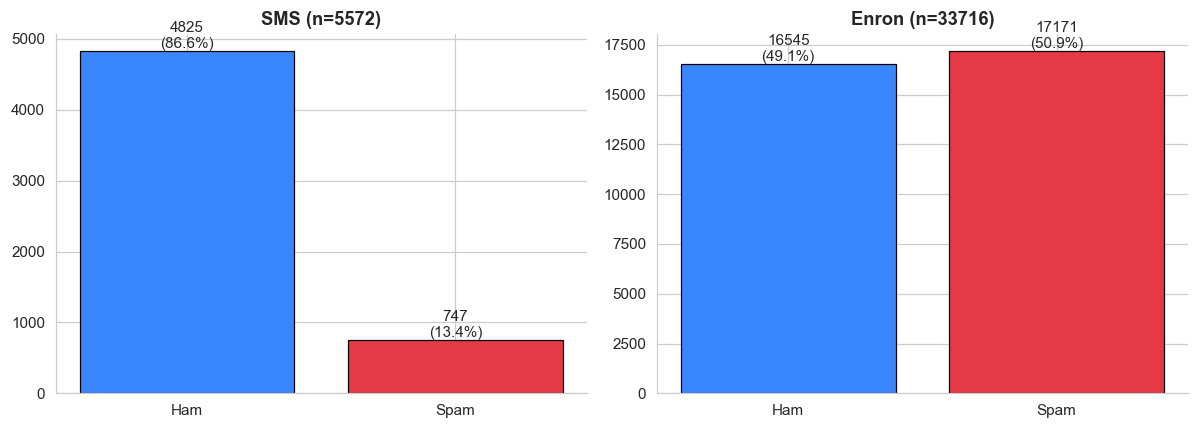

2026-05-20 23:29:01,737 INFO Figura gravada: C:\Users\iliei\OneDrive\Ambiente de Trabalho\proj AAC VFinal1\outputs\eda\01_class_distribution.png


WindowsPath('C:/Users/iliei/OneDrive/Ambiente de Trabalho/proj AAC VFinal1/outputs/eda/01_class_distribution.png')

In [5]:
df_sms["len_tokens"]   = df_sms["text"].astype(str).map(lambda t: len(clean_sms(t).split()))
df_email["len_tokens"] = df_email["text"].astype(str).map(lambda t: len(clean_email(t).split()))

fig, axes = plt.subplots(1, 2, figsize=(11, 4))
for ax, d, name in [(axes[0], df_sms, "SMS"), (axes[1], df_email, "Enron")]:
    counts = d["label"].value_counts().sort_index()
    ax.bar(["Ham", "Spam"], counts.values, color=[COLOR_HAM, COLOR_SPAM],
           edgecolor="black", linewidth=0.8)
    for i, v in enumerate(counts.values):
        ax.text(i, v, f"{v}\n({100*v/counts.sum():.1f}%)", ha="center", va="bottom")
    ax.set_title(f"{name} (n={len(d)})")
    ax.spines["top"].set_visible(False); ax.spines["right"].set_visible(False)
plt.tight_layout()
plt.show()
save_fig(fig, "01_class_distribution")

**Dataset SMS**

Com os resultados apresentados consegue-se observar uma disparidade entre a classe benigna de mensagens no dataset de SMS com 86.6% sendo Ham (4825) e 13,4% como Spam/Phishing (747), totalizando uma soma de 5572 amostras.

**Dataset Enron**

Neste dataset os resultados são mais equilibrados, com a classe Ham representada por 49,1% das amostras (16545) e pela Spam a 50,9% (17171) das amostras com uma soma total de 33 716.



### 4.2 Histogramas e violinos de comprimento

Refletem a distribuição do número de tokens (limpos) após tokenização por classe, sendo os provenientes do dataset de SMS apresentarem uma distribuição elevada com cauda curta e os provenientes do dataset dos emails Enron apresentarem uma cauda longa que justifica escala log. A linha tracejada marca o
p95 - percentil 95% — referência para o `maxlen` do LSTM.

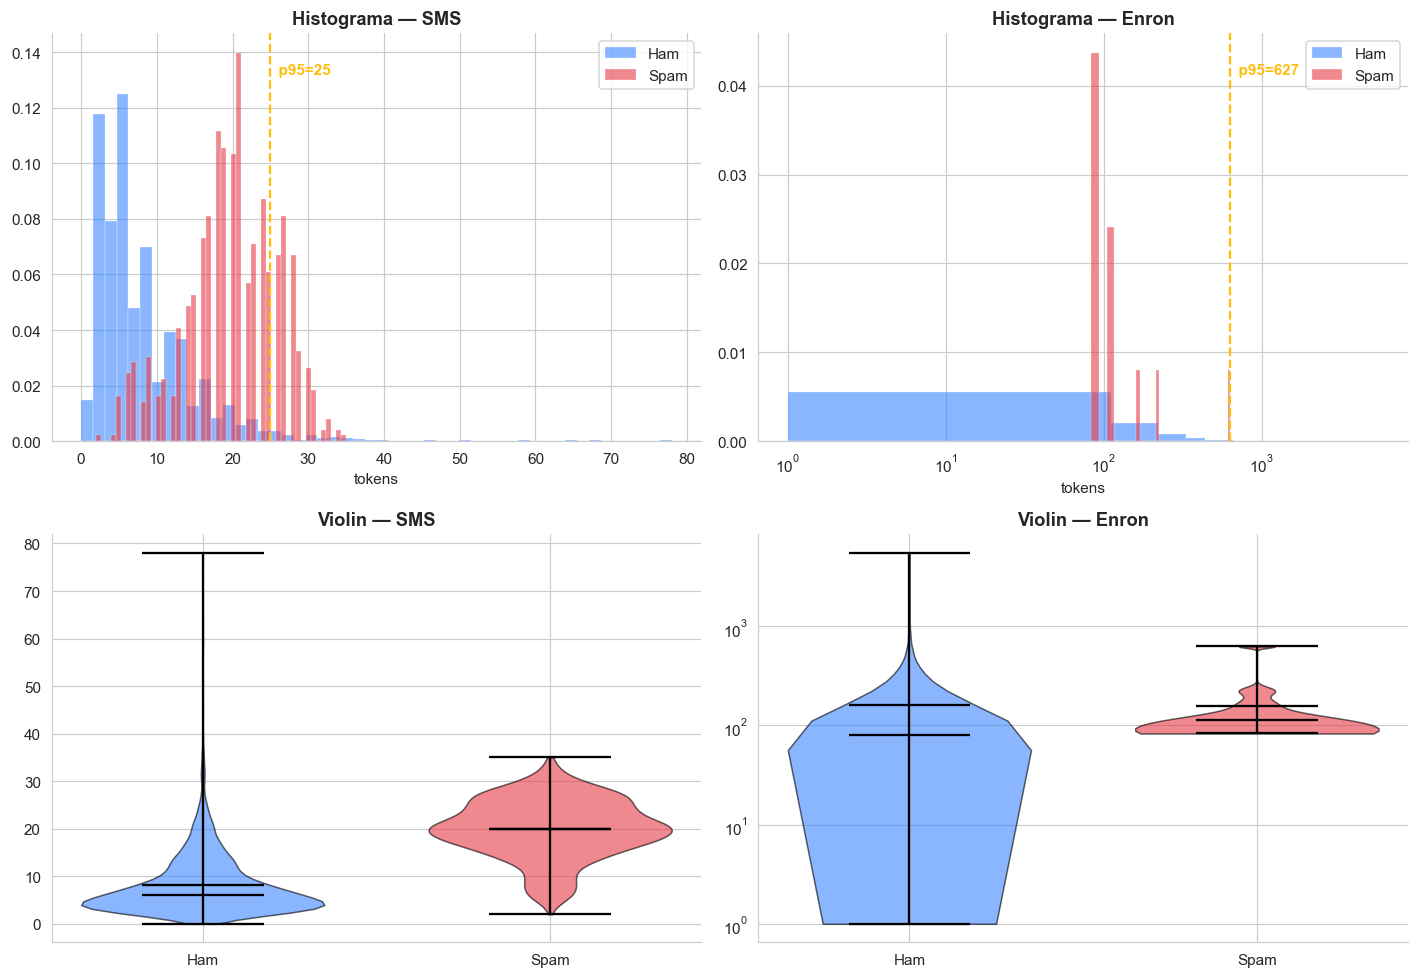

2026-05-22 18:25:43,729 INFO Figura gravada: C:\Users\iliei\OneDrive\Ambiente de Trabalho\proj AAC VFinal1\outputs\eda\02_length_histograms_and_violins.png


WindowsPath('C:/Users/iliei/OneDrive/Ambiente de Trabalho/proj AAC VFinal1/outputs/eda/02_length_histograms_and_violins.png')

In [28]:
#### plots de histogramas para os 2 datasets em causa
fig, axes = plt.subplots(2, 2, figsize=(13, 9))
for col, d, name, logx in [(0, df_sms, "SMS", False),
                            (1, df_email, "Enron", True)]:
    # Histograma do comprimento de comprimento dos tokens
    ax = axes[0, col]
    for cls, color, lbl in [(0, COLOR_HAM, "Ham"), (1, COLOR_SPAM, "Spam")]:
        s = d.loc[d["label"] == cls, "len_tokens"]
        ax.hist(s, bins=50, alpha=0.6, label=lbl, color=color, density=True,
                 edgecolor="white", linewidth=0.3)
    if logx: ax.set_xscale("log")
    #trajecado a amarelo para o percentil de p95 para ambos os datasets 
    p95 = d["len_tokens"].quantile(0.95)
    ax.axvline(p95, ls="--", color=COLOR_WARN, lw=1.5)
    ax.text(p95, ax.get_ylim()[1]*0.9, f"  p95={int(p95)}", color=COLOR_WARN,
             weight="bold")
    ax.set_title(f"Histograma — {name}"); ax.set_xlabel("tokens")
    ax.legend(); ax.spines["top"].set_visible(False); ax.spines["right"].set_visible(False)
    # histograma estilo violinos para comprimento de tokens para comparação das 
    #distribuições benignas e malignas de spam/phishing entre para ambos os cenários estudados
    ax = axes[1, col]
    data = [d.loc[d["label"] == 0, "len_tokens"].values,
             d.loc[d["label"] == 1, "len_tokens"].values]
    parts = ax.violinplot(data, positions=[0, 1], widths=0.7,
                          showmeans=True, showmedians=True)
    for pc, c in zip(parts["bodies"], [COLOR_HAM, COLOR_SPAM]):
        pc.set_facecolor(c); pc.set_edgecolor("black"); pc.set_alpha(0.6)
    for k in ("cmeans", "cmedians", "cbars", "cmins", "cmaxes"):
        if k in parts: parts[k].set_color("black")
    ax.set_xticks([0, 1]); ax.set_xticklabels(["Ham", "Spam"])
    ax.set_title(f"Violin — {name}")
    if name == "Enron": ax.set_yscale("log")
    ax.spines["top"].set_visible(False); ax.spines["right"].set_visible(False)
plt.tight_layout()
plt.show()
save_fig(fig, "02_length_histograms_and_violins")

##### 4.2.2 Estatisticas descritivas complementares aos gráficos apresentados

In [29]:
df_sms.describe()

,label,len_tokens
count,5572.000000,5572.000000
mean,0.134063,9.812994
std,0.340751,7.789194
min,0.000000,0.000000
25%,0.000000,4.000000
50%,0.000000,7.000000
75%,0.000000,14.000000
max,1.000000,78.000000


Permite visualizar os quartis, minímo e máximo de sms dataset, como a média, desvio padrão e contagens.

In [31]:
df_email.describe()

,Unnamed: 0,label,len_tokens
count,33716.000000,33716.000000,33716.000000
mean,16857.500000,0.509283,159.795409
std,9733.115174,0.499921,290.071806
min,0.000000,0.000000,1.000000
25%,8428.750000,0.000000,83.000000
50%,16857.500000,1.000000,87.000000
75%,25286.250000,1.000000,163.000000
max,33715.000000,1.000000,5489.000000


**Dataset SMS** 

É possível visualizar através dos gráficos apresentados alguns factos inrefutáveis visualmente salvo apresentação de forte prova contrário:
a) O comprimento dos tokens nestas 5571 mensagens analisadas variam entre os 1 tokens (0-> NaN estariam removidos por esta altura) e os 78 contudo acima dos 40 tokens o valor é residual <= 0.01%.
b) 95% do dataset estar compreendido entre os 0 e os 25 tokens e 5% do dataset entre os 26-78.
c) A distribuição da classe de spam nos tokens é ligeiramente superior a do ham, pico da cauda do ham estar a volta do 6-8 tokens e a do spam nos 20-22.

**Dataset Enron**

Neste dataset tal como nos histogramas do SMS pudemos verificar alguns factos, sendos eles os seguintes:
a) 95% dos dados ou seja cerca de 32 029 das amostras estarem contidas no intervalo de 0 e 627.
b) 5% dos restantes cerca ~1651 entre 627 e 5489 tokens.
c) A classe ham estar representada com uma cauda longa à esquerda isto é compreendida entre os 10-627 com nuances entre 100-627.


### 4.3 Percentis das features heurísticas — 3 vistas

Comparação dos percentis das 12 features finais entre SMS, Enron e Combined,
separadas por classe. **Outliers** (valores no p99 ou superior em relação à
mediana) são destacados a bold/vermelho na tabela HTML.

In [7]:
#heurísticas anteriormente designadas
TOP_FEATS = ["char_count", "num_digits", "has_currency", "has_unsubscribe",
             "entropy_text", "has_shortcode", "has_signature_block"]

# para cada uma destas cálcula o seu percentil, neste caso definimos os p50, p90, p95 e o máximo valor.
rows = []
#também criamos o join dos dois datasets para uma comparação mais pormenorizada
for feat_df, src in [(feat_df_sms, "sms"), (feat_df_email, "enron"),
                      (feat_df_combined, "combined")]:
    for cls, lbl in [(0, "ham"), (1, "spam")]:
        sub = feat_df[feat_df["label"] == cls]
        for f in TOP_FEATS:
            s = sub[f]
            rows.append({"source": src, "class": lbl, "feature": f,
                         "p50": float(s.quantile(.50)),
                         "p90": float(s.quantile(.90)),
                         "p95": float(s.quantile(.95)),
                         "max": float(s.max())})
percent_df = pd.DataFrame(rows)
safe_csv(percent_df, EDA_DIR / "feature_percentiles_by_source.csv")
print(f"→ {EDA_DIR / 'feature_percentiles_by_source.csv'}")

# Estilizar (destacar discrepâncias entre p95 e p50)
def _highlight_outliers(row):
    styles = [""] * len(row)
    p50, p95 = row.get("p50", 0), row.get("p95", 0)
    if p95 > 5 * p50 and p95 > 1:
        if "p95" in row.index:
            idx = list(row.index).index("p95")
            styles[idx] = "background-color: #fdf2f4; color: #e63946; font-weight: 700;"
    return styles

#arredondamento a 3 casas decimais 
display(percent_df.round(3).style
         .apply(_highlight_outliers, axis=1)
         .set_table_styles([
             {"selector": "th", "props": "background: #343a40; color: #fff;"},
             {"selector": "td", "props": "font-size: 0.95rem; padding: 6px 10px;"},
         ]))

→ C:\Users\iliei\OneDrive\Ambiente de Trabalho\proj AAC VFinal1\outputs\eda\feature_percentiles_by_source.csv


,source,class,feature,p50,p90,p95,max
0,sms,ham,char_count,52.000000,145.600000,160.000000,910.000000
1,sms,ham,num_digits,0.000000,1.000000,2.000000,23.000000
2,sms,ham,has_currency,0.000000,0.000000,0.000000,1.000000
3,sms,ham,has_unsubscribe,0.000000,0.000000,0.000000,0.000000
4,sms,ham,entropy_text,4.060000,4.418000,4.527000,5.131000
5,sms,ham,has_shortcode,0.000000,0.000000,0.000000,1.000000
6,sms,ham,has_signature_block,0.000000,0.000000,0.000000,1.000000
7,sms,spam,char_count,149.000000,161.000000,162.700000,224.000000
8,sms,spam,num_digits,16.000000,26.000000,29.000000,47.000000
9,sms,spam,has_currency,0.000000,1.000000,1.000000,1.000000


**Dataset SMS**
|**Label**| **Class Ham** | **Class Spam**|
|---------|---------------|----------------|
|*Char Count*|  0-50% até 52 chars, 50-95% entre 53-160, 5% restantes 160-910 | 0-50% até 149 50-90 150-161  90-100 162-224 |
|*num digits* | maioria das amostras apresenta no máximo 2 (95%), restantes 5% 2-23 | 0-50 16 dig 50-90 16-26 90-95 27-29 |
|*has currency*| booleano 95-100% 0-1 | 0-50 sem 50-100 contêm currency |
|*has unscribed*| booleano ausente | bool 95-100 0-1 |
|*entropy text* |média de 4,06 variedade de caracters | média ~4.8 |
|*has short code*| booleano 95-100 0-1 | 0-100 presente |
|*has signature code* |booleano 95-100 0-1 | bool ausente |


**Dataset ENRON**
|**Label**| **Class Ham** | **Class Spam**|
|---------|---------------|----------------|
|*Char Count*| 0-50 % 795 50-90% 3123 90-95% 4526| 0.5 1206 0.90 2300 0.95 6614 |
|*num digits*| 0-50 % 24 50-95 131| 0.5 dig 33	0.9 56 dig |
|*has currency*| bool metade com| bool metade contêm |
|*has unscribed*|bool 95-100 com resto sem| bool sem |
|*entropy text*| média ~4.52| média 4.74 |
|*has short code*| bool contêm| bool com |
|*has signature code*| bool 90-100% contêm| bool sem |


**Dataset COMBINED**
|**Label**| **Class Ham** | **Class Spam**|
|---------|---------------|----------------|
|*Char Count* | 50% 495 90%	2687 95% 3937.1 | 50% 206 90% 2300 95% 6614 |
|*num digits* | 0-50 33 dig 50-100 56 dig | 0-50% 33 dig 50-100 56 dig |
|*has currency* | bool metade com | bool metade com |
|*has unscribed* | bool 95-100 com | bool 95-100% com |
|*entropy text* | média ~4.52 | média ~4.74 |
|*has short code* | bool com | bool com |
|*has signature code* | bool 95-100 com | sem |


### 4.4 Boxplots das features mais discriminativas

Boxplots por classe, com outliers >p99 visíveis (sem `showfliers=False`).

Estes boxplots foram calculados de tal forma para delinear os possíveis outliers que serão tratados e limpos pelo isolation forest mais adiante.

C:\Users\iliei\AppData\Local\Temp\ipykernel_17100\3851244008.py:7: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax.boxplot(data, labels=["Ham", "Spam"], patch_artist=True,
C:\Users\iliei\AppData\Local\Temp\ipykernel_17100\3851244008.py:7: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax.boxplot(data, labels=["Ham", "Spam"], patch_artist=True,
C:\Users\iliei\AppData\Local\Temp\ipykernel_17100\3851244008.py:7: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax.boxplot(data, labels=["Ham", "Spam"], patch_artist=True,
C:\Users\iliei\AppData\Local\Temp\ipykernel_17100\3851244008.py:7: MatplotlibDeprecationWar

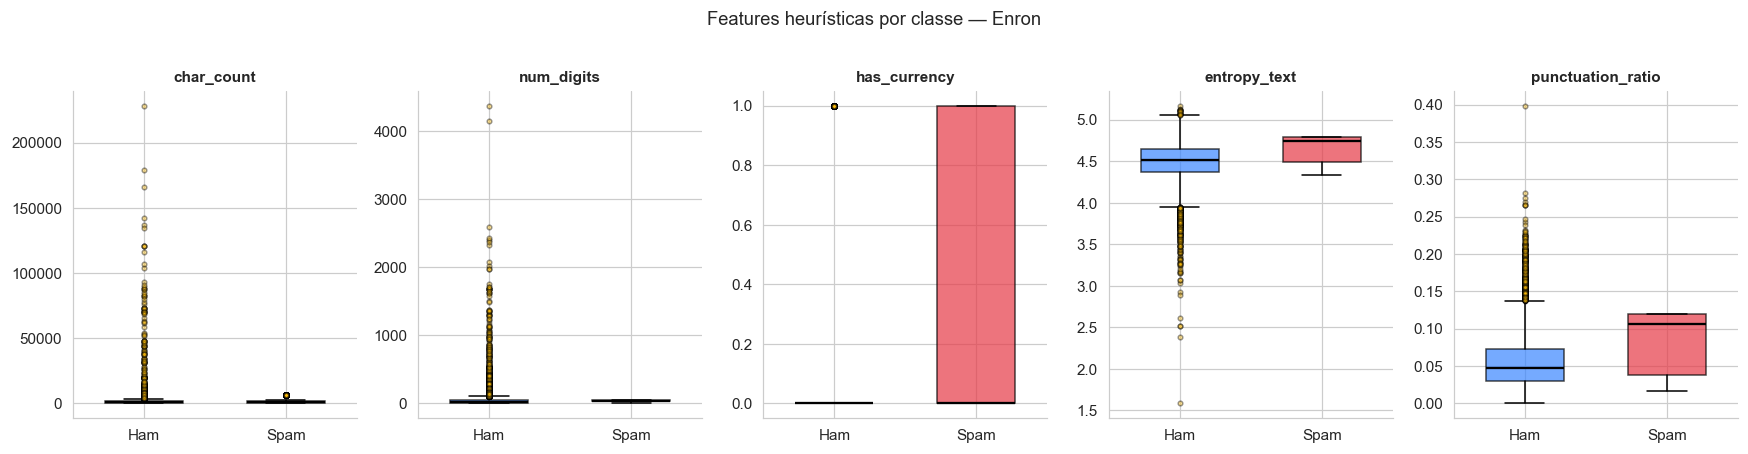

2026-05-20 23:29:05,238 INFO Figura gravada: C:\Users\iliei\OneDrive\Ambiente de Trabalho\proj AAC VFinal1\outputs\eda\03_boxplots_features_enron.png


WindowsPath('C:/Users/iliei/OneDrive/Ambiente de Trabalho/proj AAC VFinal1/outputs/eda/03_boxplots_features_enron.png')

In [8]:
BOX_FEATS = ["char_count", "num_digits", "has_currency", "entropy_text",
             "punctuation_ratio"]
#apresentação de outras vistas de algumas heurísticas/features criadas anteriormente med entropia, se tem monetário, qt digitos, razão de pontuação face aos tokens e contagem total de tokens
fig, axes = plt.subplots(1, len(BOX_FEATS), figsize=(16, 4))
for ax, feat in zip(axes, BOX_FEATS):
    data = [feat_df_email.loc[feat_df_email["label"] == 0, feat],
             feat_df_email.loc[feat_df_email["label"] == 1, feat]]
    bp = ax.boxplot(data, labels=["Ham", "Spam"], patch_artist=True,
                     showfliers=True, widths=0.55,
                     flierprops=dict(marker="o", markersize=3,
                                      markerfacecolor=COLOR_WARN, alpha=0.4))
    for patch, c in zip(bp["boxes"], [COLOR_HAM, COLOR_SPAM]):
        patch.set_facecolor(c); patch.set_alpha(0.7)
    for med in bp["medians"]: med.set_color("black"); med.set_linewidth(1.5)
    ax.set_title(feat, fontsize=10)
    ax.spines["top"].set_visible(False); ax.spines["right"].set_visible(False)
fig.suptitle("Features heurísticas por classe — Enron", y=1.02)
plt.tight_layout()
plt.show()
save_fig(fig, "03_boxplots_features_enron")

Observa-se um maior número de caracters na classe geral benigna, uma maior presença de monetário em classe de spam e uma variedade de símbolos superior a do ham, defendida pela aplitude interquartil 25-75 do spam com maior presença de pontuação.

### 4.5 Heatmap Spearman — 3 vistas

Heatmaps de correlações entre as 12 features finais. Geramos 3 PNGs e 3 CSVs
de redundância (pares com |ρ|>0.85). A diferença entre as três vistas indica
quão homogéneo é o léxico de cada dataset.

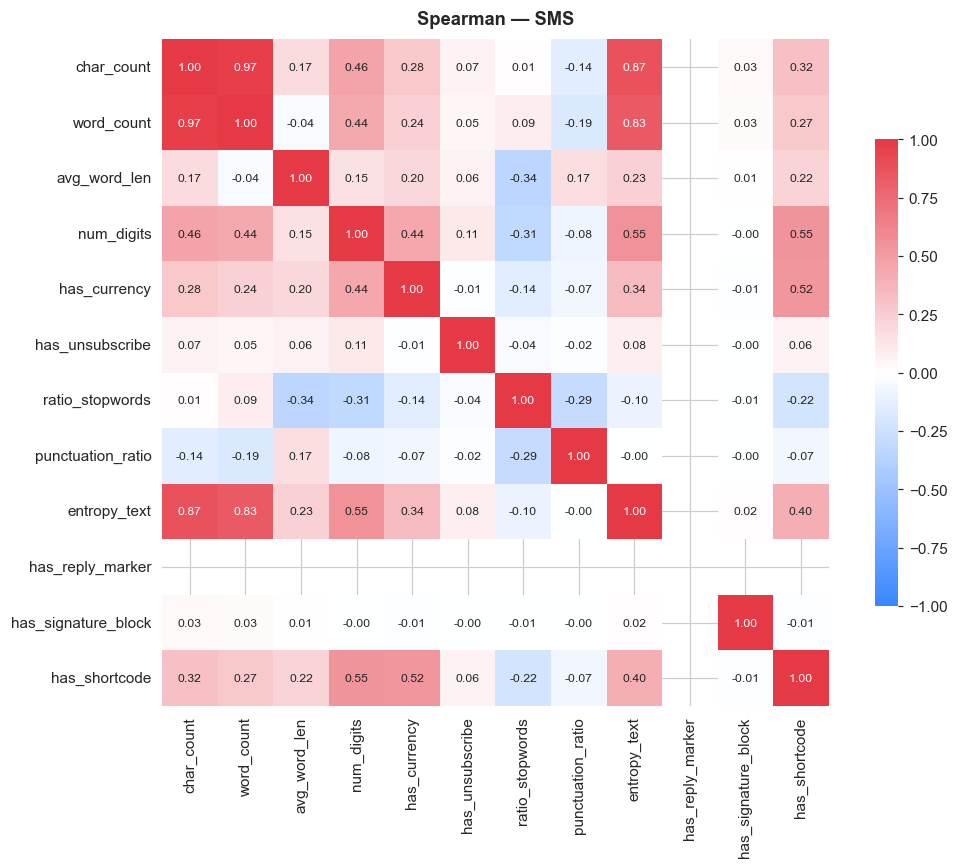

2026-05-20 23:29:06,160 INFO Figura gravada: C:\Users\iliei\OneDrive\Ambiente de Trabalho\proj AAC VFinal1\outputs\eda\03_heatmap_features_sms.png


  SMS: 2 pares com |ρ|>0.85 → outputs/eda/feature_correlations_high_sms.csv


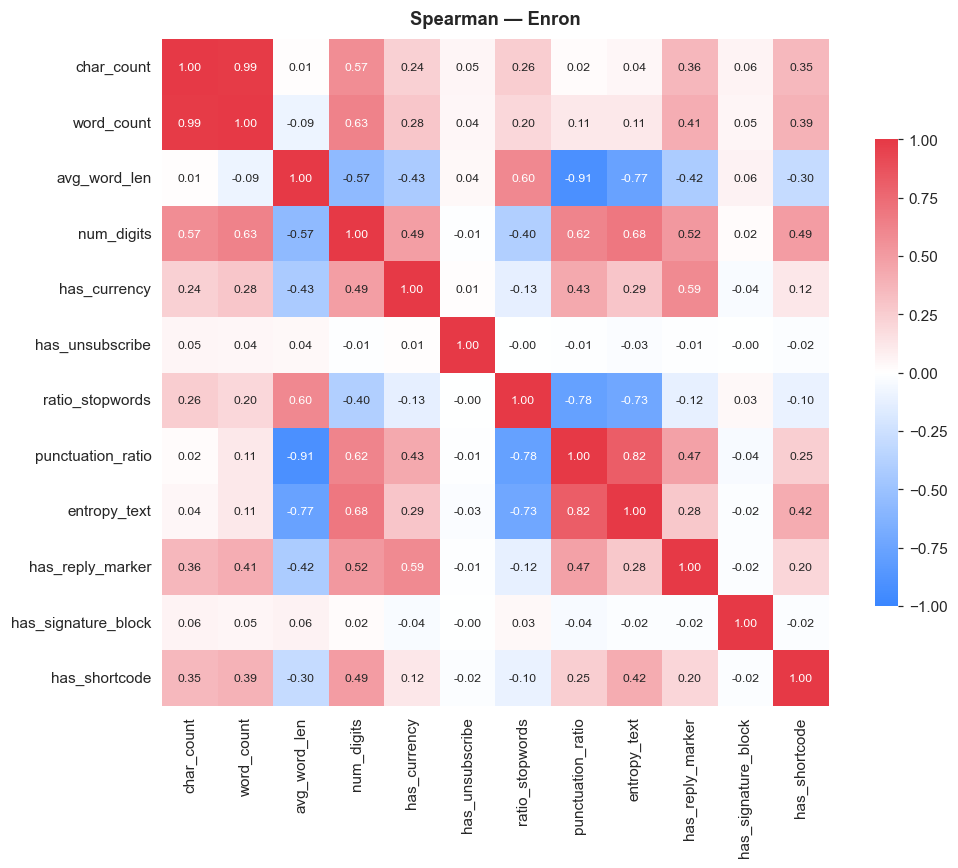

2026-05-20 23:29:07,266 INFO Figura gravada: C:\Users\iliei\OneDrive\Ambiente de Trabalho\proj AAC VFinal1\outputs\eda\03_heatmap_features_enron.png


  Enron: 2 pares com |ρ|>0.85 → outputs/eda/feature_correlations_high_enron.csv


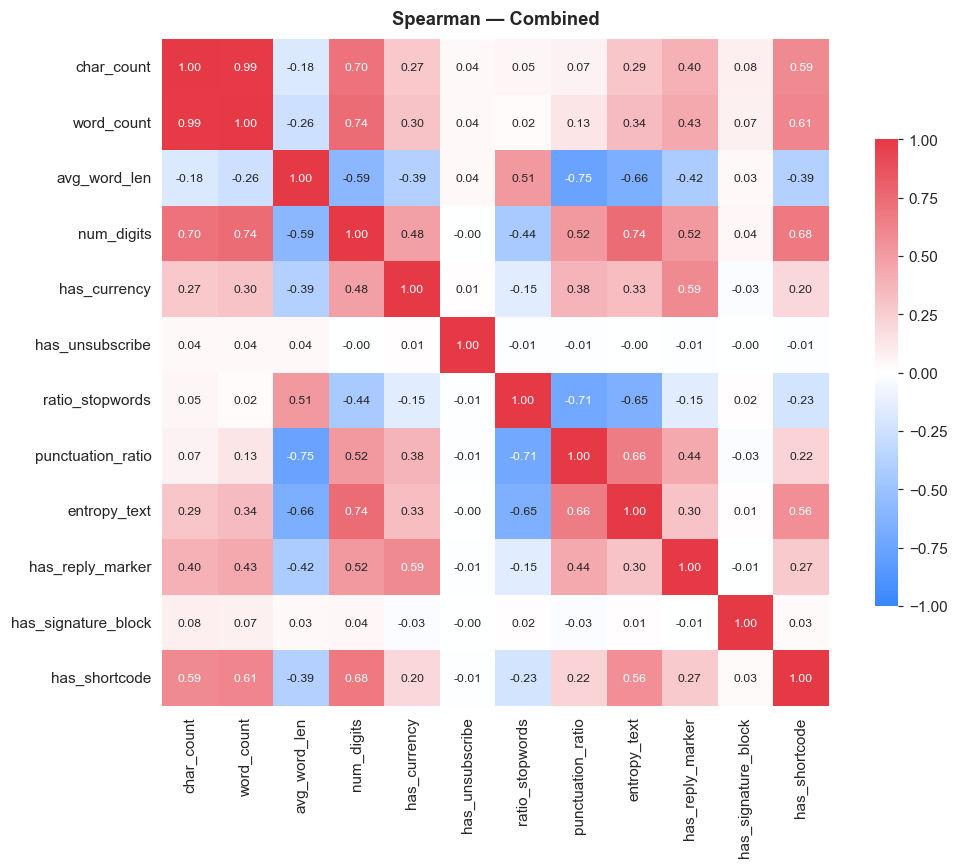

2026-05-20 23:29:08,277 INFO Figura gravada: C:\Users\iliei\OneDrive\Ambiente de Trabalho\proj AAC VFinal1\outputs\eda\03_heatmap_features_combined.png


  Combined: 1 pares com |ρ|>0.85 → outputs/eda/feature_correlations_high_combined.csv


In [9]:

#definição do heatmap e a sua cor
cmap_v1 = LinearSegmentedColormap.from_list("v1", [COLOR_HAM, "#fff", COLOR_SPAM], N=256)


def _heatmap_one(feat_df, name, key):
    """função de atr de heatmap conforme o nome da:
        feature/heurística, 
        o nome do dataset (SMS, ENRON, COMBINED)
            e guarda como csvpela {key}.csv """
    cols = [c for c in feat_df.columns if c not in ("label", "source")]
    corr = feat_df[cols].corr(method="spearman")
    fig, ax = plt.subplots(figsize=(10, 8))
    sns.heatmap(corr, annot=True, fmt=".2f", cmap=cmap_v1, center=0,
                 vmin=-1, vmax=1, square=True, cbar_kws={"shrink": .7},
                 ax=ax, annot_kws={"size": 8})
    ax.set_title(f"Spearman — {name}", pad=10)
    plt.tight_layout()
    plt.show()
    save_fig(fig, f"03_heatmap_features_{key}")
    high = []
    for i in range(corr.shape[0]):
        for j in range(i + 1, corr.shape[1]):
            v = corr.iat[i, j]
            if abs(v) > 0.85:
                high.append((corr.index[i], corr.columns[j], float(v)))
    pd.DataFrame(high, columns=["feat_a", "feat_b", "spearman"]).to_csv(
        EDA_DIR / f"feature_correlations_high_{key}.csv", index=False)
    return len(high)


for feat_df, name, key in [(feat_df_sms, "SMS", "sms"),
                             (feat_df_email, "Enron", "enron"),
                             (feat_df_combined, "Combined", "combined")]:
    n = _heatmap_one(feat_df, name, key)
    print(f"  {name}: {n} pares com |ρ|>0.85 → outputs/eda/feature_correlations_high_{key}.csv")

Observa-se no geral uma correlação forte positiva normal entre chars e palavras, variáveis que não devem ser utilizadas no treino em conjunto, existência de uma correlação forte entre o nº de digits e o domínio do dataset Enron e combined.
No dataset enron podemos retirar que os email longos veem com mais caracters e mais possibilidades de virem com mais números entre os tokens presentes.
Já no dataset SMS o comprimento e o número de palavras anda junto, isto é, muitas mensagens podem ser um simples "ok", ou um "a ir", enquanto um email profissional tende a conter endereçada uma quantidade de palavras substancialmente maior.
No combined reflete a mistura dos dois conjuntos de dados, ganhando força na quantidade de digitos contidos, visto serem mais e em maior número a quantidade de tokens prevalece causando maior efeito no overall score do cálculo desta correlação.

### 4.6 Top-tokens por classe

Análise BoW directa (sem TF-IDF) — quais as palavras mais frequentes em ham
vs spam para o SMS. *(Para Enron este eixo é menos informativo por causa do
HTML/MIME inflado — daí ser dataset-específico ao SMS.)*

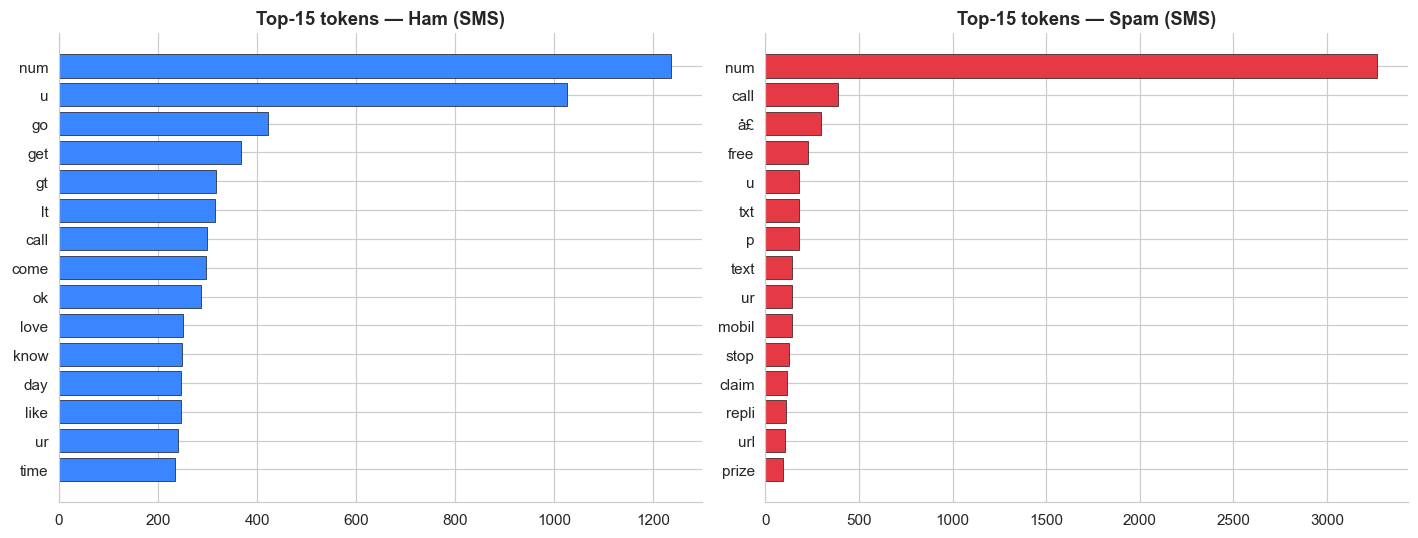

2026-05-22 20:38:43,929 INFO Figura gravada: C:\Users\iliei\OneDrive\Ambiente de Trabalho\proj AAC VFinal1\outputs\eda\04_top_tokens_sms.png


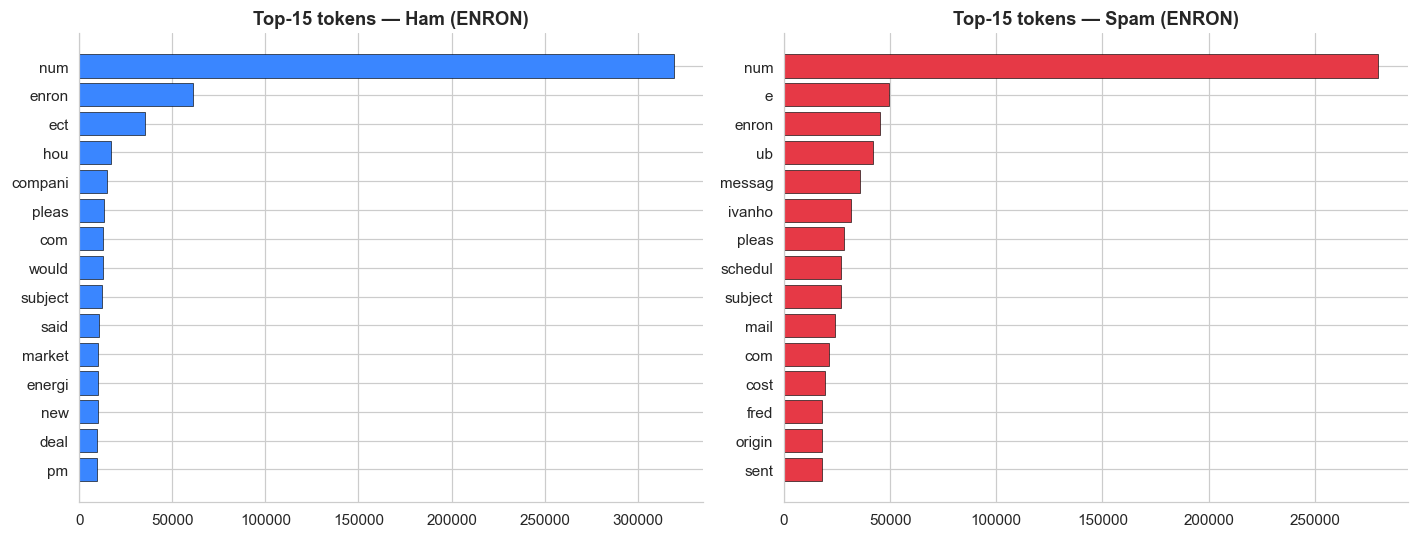

2026-05-22 20:41:35,461 INFO Figura gravada: C:\Users\iliei\OneDrive\Ambiente de Trabalho\proj AAC VFinal1\outputs\eda\04_2_top_tokens_enron.png


WindowsPath('C:/Users/iliei/OneDrive/Ambiente de Trabalho/proj AAC VFinal1/outputs/eda/top_tokens_enron.csv')

In [32]:

def _top_tokens(texts, labels, n=15):
    """function que conta os tokens + comuns por classe"""
    #dict pairs para adição das palavras
    out = {}
    for cls in (0, 1):
        c = Counter()
        for t in texts[labels == cls]:
            c.update(clean_sms(t).split())
        out[cls] = c.most_common(n)
    return out

#cálculo dos tokens mais vulgares no dataset SMS e plot deles
tt = _top_tokens(df_sms["text"], df_sms["label"].to_numpy())
fig, axes = plt.subplots(1, 2, figsize=(13, 5))
for ax, cls, color, name in [(axes[0], 0, COLOR_HAM, "Ham"),
                              (axes[1], 1, COLOR_SPAM, "Spam")]:
    toks, counts = zip(*tt[cls])
    ax.barh(list(toks)[::-1], list(counts)[::-1], color=color,
             edgecolor="black", linewidth=0.4)
    ax.set_title(f"Top-15 tokens — {name} (SMS)")
    ax.spines["top"].set_visible(False); ax.spines["right"].set_visible(False)
plt.tight_layout()
plt.show()
save_fig(fig, "04_top_tokens_sms")

# Exportar também CSV para o Dash
top_df = pd.DataFrame([
    {"token": t, "count": c, "class": "ham" if cls == 0 else "spam"}
    for cls in (0, 1) for t, c in tt[cls]
])
safe_csv(top_df, EDA_DIR / "top_tokens_sms.csv")

#aplicação do mesmo procedimento para o dataset enron emails
t = _top_tokens(df_email["text"], df_email["label"].to_numpy())
fig, axes = plt.subplots(1, 2, figsize=(13, 5))
for ax, cls, color, name in [(axes[0], 0, COLOR_HAM, "Ham"),
                              (axes[1], 1, COLOR_SPAM, "Spam")]:
    toks, counts = zip(*t[cls])
    ax.barh(list(toks)[::-1], list(counts)[::-1], color=color,
             edgecolor="black", linewidth=0.4)
    ax.set_title(f"Top-15 tokens — {name} (ENRON)")
    ax.spines["top"].set_visible(False); ax.spines["right"].set_visible(False)
plt.tight_layout()
plt.show()
save_fig(fig, "04_2_top_tokens_enron")

# Exportar também CSV para o Dash
top_df2 = pd.DataFrame([
    {"token": a, "count": c, "class": "ham" if cls == 0 else "spam"}
    for cls in (0, 1) for a, c in t[cls]
])
safe_csv(top_df, EDA_DIR / "top_tokens_enron.csv")


Alguns dos tokens mais comuns no dataset SMS são go, get, come, ok , love, time, etc e no spam mobil, spam, num, call, free, text, txt, prize, url, etc...
No dataset enron a classe benigna contêm num, enron,ect, please, market, deal, pm, etc...
A spam contêm num, enron, messag, schedul, subject, com, mail, etc...

### 4.7 Heurísticas binárias por classe (taxa de presença)

Para as features binárias do conjunto final (currency, unsubscribe,
shortcode, signature, reply marker), mostramos a taxa de presença em ham vs
spam por dataset. Diferenças grandes entre as duas barras indicam features
discriminativas. Valores destacados visualmente: se a razão spam/ham > 2×,
a barra spam fica com contorno mais espesso.

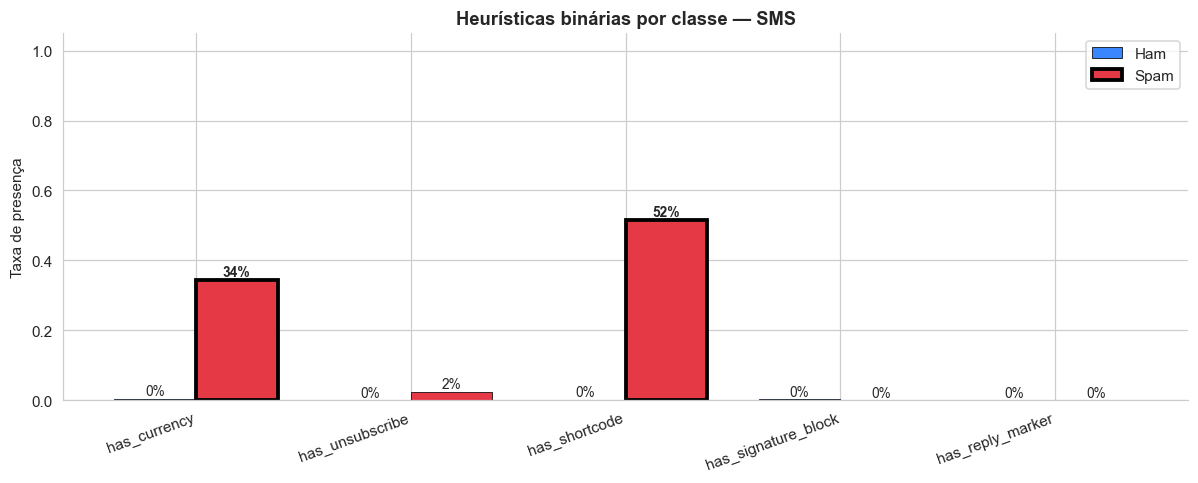

2026-05-20 23:29:14,454 INFO Figura gravada: C:\Users\iliei\OneDrive\Ambiente de Trabalho\proj AAC VFinal1\outputs\eda\eda_binary_feats_by_class_sms.png


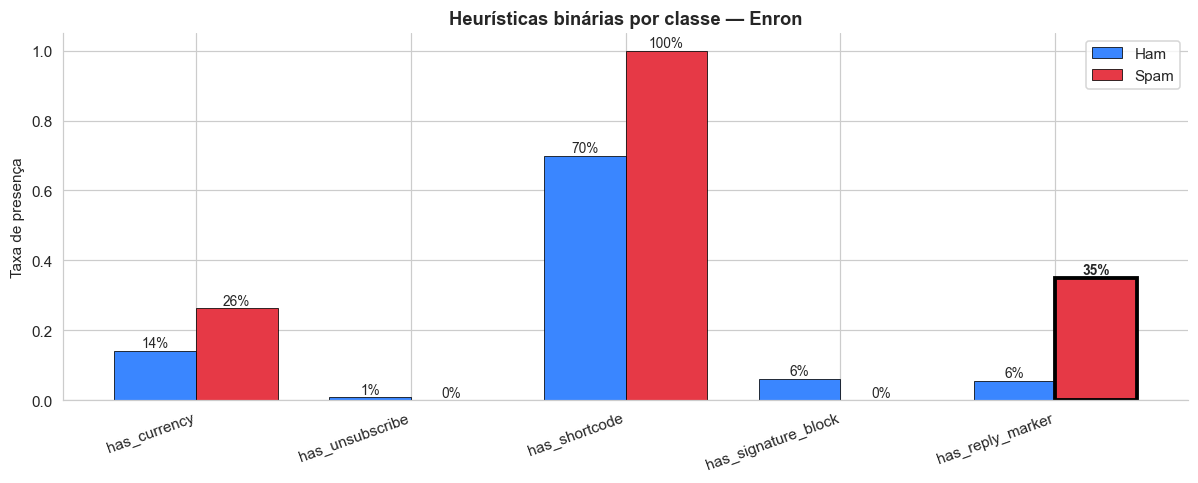

2026-05-20 23:29:14,834 INFO Figura gravada: C:\Users\iliei\OneDrive\Ambiente de Trabalho\proj AAC VFinal1\outputs\eda\eda_binary_feats_by_class_enron.png


→ outputs/eda/eda_binary_feats_by_class_{sms,enron}.png


In [13]:
#heurísticas
BIN_FEATS = ["has_currency", "has_unsubscribe", "has_shortcode",
              "has_signature_block", "has_reply_marker"]

for feat_df, name, src in [(feat_df_sms, "SMS", "sms"),
                             (feat_df_email, "Enron", "enron")]:
    rows_ham  = [float(feat_df.loc[feat_df["label"]==0, f].mean()) for f in BIN_FEATS]
    rows_spam = [float(feat_df.loc[feat_df["label"]==1, f].mean()) for f in BIN_FEATS]
    fig, ax = plt.subplots(figsize=(11, 4.5))
    xs = np.arange(len(BIN_FEATS)); w = 0.38
    bars_h = ax.bar(xs - w/2, rows_ham,  width=w, color=COLOR_HAM,
                     label="Ham", edgecolor="black", linewidth=0.5)
    bars_s = ax.bar(xs + w/2, rows_spam, width=w, color=COLOR_SPAM,
                     label="Spam", edgecolor="black", linewidth=0.5)
    # Destacar features com razão spam/ham > 2× (contorno forte)
    for i, (h, s) in enumerate(zip(rows_ham, rows_spam)):
        if h > 0 and s / max(h, 1e-9) > 2.0:
            bars_s[i].set_linewidth(2.5)
            bars_s[i].set_edgecolor("#000")
        ax.text(i - w/2, h + 0.01, f"{h:.0%}", ha="center", fontsize=9)
        ax.text(i + w/2, s + 0.01, f"{s:.0%}", ha="center", fontsize=9,
                 weight="bold" if (h > 0 and s/max(h,1e-9) > 2.0) else "normal")
    ax.set_xticks(xs); ax.set_xticklabels(BIN_FEATS, rotation=20, ha="right")
    ax.set_ylim(0, 1.05); ax.set_ylabel("Taxa de presença")
    ax.set_title(f"Heurísticas binárias por classe — {name}")
    ax.legend()
    ax.spines["top"].set_visible(False); ax.spines["right"].set_visible(False)
    plt.tight_layout()
    plt.show()
    save_fig(fig, f"eda_binary_feats_by_class_{src}")
print("→ outputs/eda/eda_binary_feats_by_class_{sms,enron}.png")

No dataset SMS a classe spam apresenta 34% das amostras contÊm monerário, 2% links ou corelação a estes, 52% apresentam códigos, 0% sem indicadores e nomes de títulos, comportamento normal em simples mensagens de texto. 
Já no dataset do enron 14% da classe benigna contêm monerário, e 26% a do spam, 1% da ham contÊm links, sendo que 70% da ham tÊm códigos enquanto a totalidade da spam apresenta estes. 6% da ham contêm cargo e indicador, 35% apresenta indicadores.

## 5 · TextPipeline — vectorizer TF-IDF + features heurísticas

Pipeline `fit`/`transform` em estilo scikit-learn, parametrizado por dataset
(SMS usa stemming agressivo + n-grams (1,2); e-mail não usa stemming, n-grams
(1,2), strip de HTML/MIME já feito no `clean_email`).

A função `transform` devolve `[TF-IDF | features]` como matriz csr única, com
limpeza realizada via `clean_sms`/`clean_email` do módulo partilhado.

In [ ]:
if "PipeCfg" in globals():
    del PipeCfg
class PipeCfg:
    """
    Classe de configuração da pipeline de texto.

    Atributos:
    - mode: "sms" ou "email" — define qual função de limpeza usar (SMS vs email).
    - ngram_range: tupla (min_n, max_n) para o TfidfVectorizer.
    - min_df: mínimo de documentos para que um token seja considerado.
    - max_df: máximo (proporção) de documentos para que um token seja considerado
              (ex.: 0.95 -> descarta tokens presentes em >95% dos docs).
    - max_features: número máximo de features (vocab) a manter no TF-IDF.
    """
    mode: str                                 # "sms" ou "email"
    ngram_range: Tuple[int, int] = (1, 2)     # n-gramas (unigram + bigram por defeito)
    min_df: int = 2                           # mínimo absoluto de documentos
    max_df: float = 0.95                      # p95 como limite superior (proporção)
    max_features: int = 50_000                # limite de features do TF-IDF

class TextPipeline:
    """
    Pipeline simples para transformar séries de texto em matriz esparsa:
      - aplica limpeza específica (SMS ou email),
      - ajusta um TfidfVectorizer com os parâmetros da configuração,
      - concatena features heurísticas (extraídas por extract_features).

    Observações:
    - clean_sms e clean_email devem ser funções que recebem uma string e devolvem
      a string limpa/tokenizada (ou normalizada) conforme o domínio.
    - extract_features deve devolver uma matriz (ou array) numérica com features
      heurísticas (ex.: char_count, num_digits, has_currency, entropy, ...).
    - HEURISTIC_FEATURE_NAMES deve ser uma lista com os nomes dessas features,
      usada para recuperar nomes de colunas se necessário.
    """

    def __init__(self, cfg: PipeCfg):
        """
        Inicializa a pipeline com a configuração fornecida.

        - Guarda a configuração em self.cfg.
        - Inicializa self.vec a None (será o TfidfVectorizer após fit).
        - Define self._cleaner para a função de limpeza apropriada consoante cfg.mode.
        """
        self.cfg = cfg
        self.vec: Optional[TfidfVectorizer] = None

        # As funções clean_sms / clean_email têm de existir no escopo global.
        # Aqui escolhemos a função de limpeza com base no modo.
        # Se não existirem, isto levantará NameError ao instanciar.
        self._cleaner = clean_sms if cfg.mode == "sms" else clean_email

    def fit(self, texts: pd.Series) -> "TextPipeline":
        """
        Ajusta (fit) o TfidfVectorizer aos textos limpos.

        Passos:
        1. Preenche NaNs e garante strings.
        2. Aplica a função de limpeza (self._cleaner) a cada texto.
        3. Cria o TfidfVectorizer com os parâmetros da configuração.
        4. Executa .fit() sobre os textos limpos.
        Retorna self para encadeamento (method chaining).
        """
        # Normalizar input: preencher NaNs e garantir tipo str
        cleaned = texts.fillna("").astype(str).map(self._cleaner)

        # Instancia o vectorizer com os parâmetros da configuração
        self.vec = TfidfVectorizer(
            ngram_range=self.cfg.ngram_range,
            min_df=self.cfg.min_df,
            max_df=self.cfg.max_df,
            sublinear_tf=True,
            max_features=self.cfg.max_features,
            token_pattern=r"(?u)\b\w\w+\b",  # tokens com pelo menos 2 caracteres
        )

        # Ajusta o vocabulário ao corpus limpo
        self.vec.fit(cleaned)
        return self

    def transform(self, texts: pd.Series) -> csr_matrix:
        """
        Transforma uma série de textos em matriz esparsa combinada.

        Passos:
        1. Limpa os textos (mesmo processo do fit).
        2. Transforma com o TF-IDF já ajustado (self.vec.transform).
        3. Extrai features heurísticas (extract_features) e converte para csr_matrix.
        4. Concatena horizontalmente (hstack) TF-IDF + heurísticas e devolve csr_matrix.

        Retorna:
        - Matriz esparsa CSR com todas as features.
        """
        # Garantir que o vectorizer já foi ajustado
        if self.vec is None:
            raise RuntimeError("Vectorizer não ajustado. Chama .fit() antes de .transform().")

        # Limpeza dos textos
        cleaned = texts.fillna("").astype(str).map(self._cleaner)

        # Matriz TF-IDF (esparsa)
        Xt = self.vec.transform(cleaned)

        # Extrair features heurísticas (função externa)
        # Deve devolver array-like shape (n_samples, n_heuristic_features)
        H = extract_features(texts.tolist() if hasattr(texts, "tolist") else list(texts))

        # Converter H para csr_matrix caso seja um numpy array / lista
        H_csr = csr_matrix(H)

        # Concatenar TF-IDF com features heurísticas e devolver em formato CSR
        return hstack([Xt, H_csr]).tocsr()

    def fit_transform(self, texts: pd.Series) -> csr_matrix:
        """
        Conveniência: executa fit seguido de transform.
        """
        return self.fit(texts).transform(texts)

    def get_feature_names(self) -> List[str]:
        """
        Retorna a lista de nomes de features:
        - nomes do TF-IDF (get_feature_names_out) seguidos pelos nomes heurísticos.
        Nota: HEURISTIC_FEATURE_NAMES deve ser definido globalmente.
        """
        return list(self.vec.get_feature_names_out()) + HEURISTIC_FEATURE_NAMES




pipe_sms = TextPipeline(PipeCfg(mode="sms", max_features=run_config["sms_max_features"]))
pipe_email = TextPipeline(PipeCfg(mode="email", max_features=run_config["email_max_features"]))
pipe_comb = TextPipeline(PipeCfg(mode="email", max_features=run_config["email_max_features"]))

print("Pipelines instanciados.")  # mensagem simples de confirmação


Pipelines instanciados.


## 6 · IsolationForest — filtro OOD pré-modelação

O IF aqui **não é o classificador final**. É um filtro de qualidade que
assinala outliers estruturais (OCR corrompido, ofuscação extrema). Usamos
`score_samples` (invertendo o sinal: alto = anómalo), `contamination=0.03`,
e validamos com PR-AUC contra o label spam apenas como sanidade — esperamos
um proxy fraco, porque spam ≠ anomalia.

In [15]:
v_iso = TfidfVectorizer(max_features=2000, ngram_range=(1, 1), min_df=2,
                         sublinear_tf=True)
X_iso_sms   = v_iso.fit_transform(df_sms["text"].astype(str).map(clean_sms))
X_iso_email = v_iso.fit_transform(df_email["text"].astype(str).map(clean_email))


def fit_if(X, c=run_config["if_contamination"]):
    """
    Treina um IsolationForest sobre a matriz X.
    - X: matriz esparsa (TF-IDF) ou array-like (n_samples, n_features)
    - c: taxa de contaminação esperada (float entre 0 e 0.5 ou 'auto')
    Retorna o modelo treinado.
    """
    m = IsolationForest(n_estimators=200, contamination=c,
                         random_state=SEED, n_jobs=-1)
    m.fit(X); return m


iforest_sms   = fit_if(X_iso_sms)
iforest_email = fit_if(X_iso_email)

# score_samples devolve valores onde valores mais altos indicam maior "normalidade"
# (dependendo da implementação). Aqui invertemos o sinal para que scores maiores = mais anómalo.
scores_sms   = -iforest_sms.score_samples(X_iso_sms)
scores_email = -iforest_email.score_samples(X_iso_email)


# average_precision_score interpreta scores maiores como mais probabilidade da classe positiva.
# Aqui assumimos que y_*_full tem 1 para spam/outlier e 0 para ham/normal; ajusta se necessário.
y_sms_full   = df_sms["label"].to_numpy()
y_email_full = df_email["label"].to_numpy()

print(f"IF SMS    PR-AUC (proxy)   = {average_precision_score(y_sms_full,   scores_sms):.3f}")
print(f"IF Enron  PR-AUC (proxy)   = {average_precision_score(y_email_full, scores_email):.3f}")

# Filtragem OOD
thr_sms   = np.quantile(scores_sms,   1 - run_config["if_contamination"])
thr_email = np.quantile(scores_email, 1 - run_config["if_contamination"])
df_sms_filt   = df_sms[scores_sms   < thr_sms].reset_index(drop=True)
df_email_filt = df_email[scores_email < thr_email].reset_index(drop=True)
print(f"Filtro IF — SMS:   removidos {len(df_sms) - len(df_sms_filt)} ({100*(1-len(df_sms_filt)/len(df_sms)):.1f}%)")
print(f"Filtro IF — Enron: removidos {len(df_email) - len(df_email_filt)} ({100*(1-len(df_email_filt)/len(df_email)):.1f}%)")

IF SMS    PR-AUC (proxy)   = 0.574
IF Enron  PR-AUC (proxy)   = 0.633
Filtro IF — SMS:   removidos 168 (3.0%)
Filtro IF — Enron: removidos 1623 (4.8%)


O IsolationForest capta sinal útil, com PR‑AUC moderada (≈0.57–0.63), melhor no Enron do que nas SMS. As taxas removidas (≈3.0% SMS, ≈4.8% Enron) coincidem com a contamination definida, indicando que o limiar foi aplicado conforme planeado.
Enron beneficia do IF porque mensagens são mais longas e contêm mais dígitos/características exploráveis pelo TF‑IDF.
SMS é mais curto e ruidoso, tornando mais difícil ao IF (unigram TF‑IDF) distinguir anomalias relacionadas a spam.

## 7 · Modelos clássicos — ComplementNB · LinearSVC · LogisticRegression

Treino em SMS, Enron e Combined. Avaliação por holdout estratificado 80/20.
Threshold escolhido por máximo de F-β=2 (recall pesa 4× a precision) na curva
PR do conjunto de teste.

In [16]:
# Avaliação de modelos clássicos e pipeline de treino/avaliação
# Mantive a estrutura e lógica originais, apenas adicionei comentários explicativos.

def evaluate(model, X_tr, y_tr, X_te, y_te, beta: float = 2.0):
    # Treina o modelo com os dados de treino
    model.fit(X_tr, y_tr)

    # Obter probabilidades preditas: se o modelo suportar predict_proba usa essa saída,
    # caso contrário converte a decision_function em probabilidades via sigmoid.
    if hasattr(model, "predict_proba"):
        y_proba = model.predict_proba(X_te)[:, 1]
    else:
        s = model.decision_function(X_te)
        y_proba = 1 / (1 + np.exp(-s))  # sigmoid para mapear scores para [0,1]

    # Métricas principais: PR-AUC (average precision) e ROC-AUC
    pr_auc  = float(average_precision_score(y_te, y_proba))
    roc_auc = float(roc_auc_score(y_te, y_proba))

    # Curva precisão-recall para obter thresholds e calcular F_beta
    prec, rec, thr = precision_recall_curve(y_te, y_proba)

    # Calcula F_beta para cada ponto da curva (exclui o último ponto de prec/rec que é para threshold infinito)
    fb = (1+beta**2) * (prec[:-1]*rec[:-1]) / np.where(
        (beta**2 * prec[:-1] + rec[:-1]) > 0,
        beta**2 * prec[:-1] + rec[:-1], 1e-9)  # evita divisão por zero

    # Índice do melhor F_beta (maior valor)
    bi = int(np.nanargmax(fb))

    # Escolhe o threshold correspondente ao melhor F_beta; se não houver thresholds usa 0.5 por defeito
    best_thr = float(thr[bi]) if len(thr) else 0.5

    # Converte probabilidades em predições binárias usando o threshold escolhido
    y_pred = (y_proba >= best_thr).astype(int)

    # Matriz de confusão com as predições binárias
    cm = confusion_matrix(y_te, y_pred)

    # Retorna um dicionário com o modelo, predições, métricas e contagens da matriz de confusão
    return {
        "model": model,
        "y_proba": y_proba,
        "y_pred": y_pred,
        "threshold": best_thr,
        "cm": cm.tolist(),
        "tn": int(cm[0,0]),
        "fp": int(cm[0,1]),
        "fn": int(cm[1,0]),
        "tp": int(cm[1,1]),
        "f1": float(f1_score(y_te, y_pred, zero_division=0)),
        "f_beta": float(fbeta_score(y_te, y_pred, beta=beta, zero_division=0)),
        "precision": float(precision_score(y_te, y_pred, zero_division=0)),
        "recall": float(recall_score(y_te, y_pred, zero_division=0)),
        "pr_auc": pr_auc,
        "roc_auc": roc_auc,
    }


# Funções fábricas para instanciar modelos com hiperparâmetros fixos
def make_nb():  return ComplementNB(alpha=0.3)
def make_svc(): return CalibratedClassifierCV(
    LinearSVC(C=1.0, max_iter=5000, class_weight="balanced",
               random_state=SEED), method="sigmoid", cv=3)
def make_lr():  return LogisticRegression(C=1.0, solver="liblinear",
                                            max_iter=2000, class_weight="balanced",
                                            random_state=SEED)


# Splits dos datasets (treino/test)

# Divide o dataset filtrado de SMS em treino/test com estratificação pela label
sms_tr, sms_te = train_test_split(
    df_sms_filt, test_size=0.2,
    stratify=df_sms_filt["label"], random_state=SEED)

# Divide o dataset filtrado de emails (Enron) em treino/test com estratificação pela label
enr_tr, enr_te = train_test_split(
    df_email_filt, test_size=0.2,
    stratify=df_email_filt["label"], random_state=SEED)

# Concatena os dois datasets (SMS + Enron) mantendo colunas text, label e source
df_combined = pd.concat(
    [df_sms_filt[["text","label","source"]],
     df_email_filt[["text","label","source"]]],
    ignore_index=True,
)

# Split do dataset combinado; estratifica por combinação label_source para preservar distribuição
comb_tr, comb_te = train_test_split(
    df_combined, test_size=0.2,
    stratify=df_combined[["label","source"]].astype(str).agg("_".join, axis=1),
    random_state=SEED,
)

# Extrai arrays numpy de labels para treino e teste (cada domínio)
y_sms_tr,  y_sms_te  = sms_tr["label"].to_numpy(),  sms_te["label"].to_numpy()
y_enr_tr,  y_enr_te  = enr_tr["label"].to_numpy(),  enr_te["label"].to_numpy()
y_comb_tr, y_comb_te = comb_tr["label"].to_numpy(), comb_te["label"].to_numpy()


# Fit das pipelines e transformação dos textos em matrizes de features

# Ajusta a pipeline SMS ao conjunto de treino e transforma treino/test
pipe_sms.fit(sms_tr["text"])
X_sms_tr = pipe_sms.transform(sms_tr["text"])
X_sms_te = pipe_sms.transform(sms_te["text"])

# Ajusta a pipeline Email ao conjunto de treino e transforma treino/test
pipe_email.fit(enr_tr["text"])
X_enr_tr = pipe_email.transform(enr_tr["text"])
X_enr_te = pipe_email.transform(enr_te["text"])

# Ajusta a pipeline Combinada ao conjunto de treino e transforma treino/test
pipe_comb.fit(comb_tr["text"])
X_comb_tr = pipe_comb.transform(comb_tr["text"])
X_comb_te = pipe_comb.transform(comb_te["text"])


# Treinar 3 modelos × 3 vistas (sms, enron, combined)

results: Dict[str, dict] = {}
for ds, X_tr, y_tr, X_te, y_te in [
    ("sms",      X_sms_tr,  y_sms_tr,  X_sms_te,  y_sms_te),
    ("enron",    X_enr_tr,  y_enr_tr,  X_enr_te,  y_enr_te),
    ("combined", X_comb_tr, y_comb_tr, X_comb_te, y_comb_te),
]:
    # Avalia e guarda resultados para Naive Bayes complementar
    results[f"nb_{ds}"]  = evaluate(make_nb(),  X_tr, y_tr, X_te, y_te)
    # Avalia e guarda resultados para SVC calibrado
    results[f"svc_{ds}"] = evaluate(make_svc(), X_tr, y_tr, X_te, y_te)
    # Avalia e guarda resultados para Regressão Logística
    results[f"lr_{ds}"]  = evaluate(make_lr(),  X_tr, y_tr, X_te, y_te)
    print(f"   {ds}: 3 modelos treinados")

# Construção da tabela de síntese com métricas relevantes

summary_rows = []
for key, res in results.items():
    # Separa o identificador do modelo e do dataset (ex.: "nb_sms" -> "nb", "sms")
    mdl, ds = key.rsplit("_", 1)
    # Adiciona uma linha com as métricas selecionadas
    summary_rows.append({
        "dataset": ds,
        "model": mdl.upper(),
        "pr_auc": res["pr_auc"],
        "roc_auc": res["roc_auc"],
        "f1": res["f1"],
        "f_beta": res["f_beta"],
        "precision": res["precision"],
        "recall": res["recall"],
        "threshold": res["threshold"],
        "tn": res["tn"], "fp": res["fp"], "fn": res["fn"], "tp": res["tp"],
    })

# Converte a lista de dicionários numa DataFrame para exportar/exibir
summary_classical = pd.DataFrame(summary_rows)

# Guarda a tabela em CSV de forma segura (função safe_csv assumida definida no ambiente)
safe_csv(summary_classical, TABLE_DIR / "summary_classical.csv")

# Mostra a tabela arredondada a 4 casas decimais no notebook
display(summary_classical.round(4))


C:\Users\iliei\.conda\envs\yolo_env\Lib\site-packages\sklearn\svm\_base.py:1250: ConvergenceWarning: Liblinear failed to converge, increase the number of iterations.
  warnings.warn(
C:\Users\iliei\.conda\envs\yolo_env\Lib\site-packages\sklearn\svm\_base.py:1250: ConvergenceWarning: Liblinear failed to converge, increase the number of iterations.
  warnings.warn(
C:\Users\iliei\.conda\envs\yolo_env\Lib\site-packages\sklearn\svm\_base.py:1250: ConvergenceWarning: Liblinear failed to converge, increase the number of iterations.
  warnings.warn(


  ✓ sms: 3 modelos treinados


C:\Users\iliei\.conda\envs\yolo_env\Lib\site-packages\sklearn\svm\_base.py:1250: ConvergenceWarning: Liblinear failed to converge, increase the number of iterations.
  warnings.warn(
C:\Users\iliei\.conda\envs\yolo_env\Lib\site-packages\sklearn\svm\_base.py:1250: ConvergenceWarning: Liblinear failed to converge, increase the number of iterations.
  warnings.warn(
C:\Users\iliei\.conda\envs\yolo_env\Lib\site-packages\sklearn\svm\_base.py:1250: ConvergenceWarning: Liblinear failed to converge, increase the number of iterations.
  warnings.warn(


  ✓ enron: 3 modelos treinados


C:\Users\iliei\.conda\envs\yolo_env\Lib\site-packages\sklearn\svm\_base.py:1250: ConvergenceWarning: Liblinear failed to converge, increase the number of iterations.
  warnings.warn(
C:\Users\iliei\.conda\envs\yolo_env\Lib\site-packages\sklearn\svm\_base.py:1250: ConvergenceWarning: Liblinear failed to converge, increase the number of iterations.
  warnings.warn(
C:\Users\iliei\.conda\envs\yolo_env\Lib\site-packages\sklearn\svm\_base.py:1250: ConvergenceWarning: Liblinear failed to converge, increase the number of iterations.
  warnings.warn(


  ✓ combined: 3 modelos treinados


,dataset,model,pr_auc,roc_auc,f1,f_beta,precision,recall,threshold,tn,fp,fn,tp
0,sms,NB,0.9285,0.9576,0.9008,0.8920,0.9160,0.8862,0.5020,948,10,14,109
1,sms,SVC,0.9754,0.9896,0.9317,0.9385,0.9206,0.9431,0.1400,948,10,7,116
2,sms,LR,0.9752,0.9881,0.9355,0.9400,0.9280,0.9431,0.5104,949,9,7,116
3,enron,NB,0.9994,0.9997,0.9997,0.9999,0.9994,1.0000,1.0000,3283,2,0,3134
4,enron,SVC,0.9981,0.9985,0.9943,0.9977,0.9886,1.0000,0.5483,3249,36,0,3134
5,enron,LR,1.0000,1.0000,1.0000,1.0000,1.0000,1.0000,0.9902,3285,0,0,3134
6,combined,NB,0.9966,0.9975,0.9664,0.9798,0.9449,0.9889,0.0458,4055,188,36,3221
7,combined,SVC,0.9987,0.9989,0.9913,0.9958,0.9840,0.9988,0.4884,4190,53,4,3253
8,combined,LR,0.9999,0.9999,0.9974,0.9980,0.9963,0.9985,0.1759,4231,12,5,3252


sms — NB  
O NB apresenta boa precisão e PR‑AUC elevada (0.9285), indicando que separa bem classes relevantes com poucas falsas positivas. Ainda assim o recall (0.8862) mostra que perde alguns positivos — útil para cenários onde preferes menos falsos positivos que recall máximo.

sms — SVC  
O SVC melhora recall e F1 relativamente ao NB (recall 0.9431, F1 0.9317), sugerindo decisão mais agressiva em favor de detectar spam. O threshold baixo (0.14) indica que o calibrador está a favorecer sensibilidade; verifica impacto em FP se precisares de reduzir alarmes.

sms — LR  
A Regressão Logística alcança o melhor F1 no SMS (0.9355) com equilíbrio entre precisão e recall, sendo uma escolha robusta e estável. O threshold perto de 0.51 mostra que a probabilidade está bem calibrada para este conjunto.

enron — NB  
No Enron o NB já quase atinge perfeição (pr_auc 0.9994, recall 1.0), o que pode refletir dados muito separáveis ou sobreajuste das features. Confere amostras borderline porque métricas tão extremas podem esconder vazios na generalização.

enron — SVC  
O SVC também performa muito bem (pr_auc 0.9981) mas com alguns falsos positivos (fp 36) — trade‑off entre sensibilidade e especificidade. Se o custo de FP for alto, ajusta C ou o threshold calibrado para reduzir esses 36 casos.

enron — LR  
A LR atinge resultados praticamente perfeitos (PR/ROC = 1.0, F1 = 1.0), sinalizando separabilidade quase total no conjunto testado. Antes de confiar cegamente, valida em folds adicionais ou dados externos para garantir que não é efeito de leak ou overfitting.

combined — NB  
No combinado o NB mantém PR/ROC muito altos, mas mostra mais falsos positivos (fp 188) do que nos domínios isolados, indicando sensibilidade a heterogeneidade dos dados. Útil como baseline rápido, mas pode precisar de calibragem para reduzir alarmes em produção.

combined — SVC  
O SVC oferece excelente equilíbrio (F1 0.9913, recall 0.9988) com poucos falsos positivos (fp 53), sendo uma opção forte para o dataset misto. O threshold intermédio (0.4884) sugere boa calibração entre domínios; é um bom candidato para deploy com monitorização.

combined — LR  
A LR apresenta desempenho quase perfeito no combinado (pr_auc/roc_auc ≈ 1.0, F1 0.9974) com muito poucos falsos positivos (fp 12), mostrando robustez e calibragem fina. Confirma estabilidade em validação temporal e testa contra dados fora da distribuição antes de produção.

Se quiseres, tra

## 8 · LSTM Bidirecional — 3 vistas (SMS · Enron · Combined)

Comparação honesta com os modelos clássicos. Treinamos o **mesmo
arquitectura** Bidir-LSTM nas três vistas para que a diferença entre PR-AUC
SMS/Enron/Combined seja atribuível ao **domínio**, não ao modelo.

Correções críticas mantidas: `vocab_size = len(tok.word_index)+1` (o +1
para padding), `maxlen` derivado do p95 de cada dataset clamped em [40, 200]
para custo computacional, `tf.data.Dataset` com prefetch, callbacks
`EarlyStopping(monitor='val_pr_auc')` e `ReduceLROnPlateau`. Limpeza:
`clean_sms` para SMS, `clean_email` para Enron e Combined (texto longo com
HTML/MIME).

**Custo prático.** Enron e Combined têm ~30 mil amostras vs ~5500 do SMS;
em CPU o treino é proporcionalmente mais lento. Cobrimos isto com:
(a) `EarlyStopping(patience=2)` que tipicamente termina em 4–6 épocas;
(b) `mask_zero=True` no Embedding que permite ao LSTM ignorar padding;
(c) clamp `maxlen ≤ 200`. Fallback gracioso se TensorFlow não estiver
disponível ou o treino falhar — o estudo segue com os modelos clássicos.

In [17]:

# Este bloco treina LSTM bidirecionais por dataset, avalia e guarda resultados.

lstm_results_by_ds: dict = {}     # ← {"sms": {...}, "enron": {...}, "combined": {...}}

try:
    import tensorflow as tf
    from tensorflow import keras
    tf.random.set_seed(SEED)

    def train_lstm_for(name: str, df_tr_text, df_te_text, y_tr, y_te,
                        cleaner, len_tokens_series, max_words: int = 10_000):
        """Treina Bidir-LSTM para um dataset e devolve dict com métricas + paths."""
        # Determina o comprimento máximo das sequências a usar (clip no quantil 95 entre 40 e 200)
        MAX_LEN = int(np.clip(len_tokens_series.quantile(0.95), 40, 200))

        # Aplica a função de limpeza (cleaner) aos textos de treino e teste
        texts_tr_c = df_tr_text.astype(str).map(cleaner).tolist()
        texts_te_c = df_te_text.astype(str).map(cleaner).tolist()

        # Tokenizador Keras: limita o vocabulário a max_words e usa token OOV
        tok = keras.preprocessing.text.Tokenizer(num_words=max_words, oov_token="<OOV>")
        tok.fit_on_texts(texts_tr_c)

        # Tamanho efectivo do vocabulário (respeita max_words)
        vocab_size = min(max_words, len(tok.word_index) + 1)

        # Converte textos em sequências de índices e faz padding até MAX_LEN
        Xs_tr = keras.preprocessing.sequence.pad_sequences(
            tok.texts_to_sequences(texts_tr_c), maxlen=MAX_LEN, padding="post")
        Xs_te = keras.preprocessing.sequence.pad_sequences(
            tok.texts_to_sequences(texts_te_c), maxlen=MAX_LEN, padding="post")

        # Batch size vindo da configuração de execução
        BATCH = run_config["lstm_batch_size"]

        # Dataset de treino: tensor slices, shuffle, batch e prefetch para performance
        train_ds = (tf.data.Dataset
            .from_tensor_slices((Xs_tr, y_tr.astype(np.float32)))
            .shuffle(2048, seed=SEED).batch(BATCH).prefetch(tf.data.AUTOTUNE))

        # Constrói um conjunto de validação simples a partir dos primeiros val_n exemplos
        val_n = max(64, int(0.15 * len(Xs_tr)))
        val_ds = (tf.data.Dataset
            .from_tensor_slices((Xs_tr[:val_n], y_tr[:val_n].astype(np.float32)))
            .batch(BATCH).prefetch(tf.data.AUTOTUNE))

        # Definição do modelo: Embedding -> Bidirectional LSTM -> Dropout -> Dense -> Dropout -> Sigmoid
        model = keras.Sequential([
            keras.layers.Embedding(vocab_size, 64, input_length=MAX_LEN, mask_zero=True),
            keras.layers.Bidirectional(keras.layers.LSTM(64)),
            keras.layers.Dropout(0.5),
            keras.layers.Dense(32, activation="relu"),
            keras.layers.Dropout(0.3),
            keras.layers.Dense(1, activation="sigmoid"),
        ])

        # Compilação com Adam, binary crossentropy e métricas de AUC/PR
        model.compile(
            optimizer=keras.optimizers.Adam(1e-3),
            loss="binary_crossentropy",
            metrics=["accuracy",
                     keras.metrics.AUC(name="auc"),
                     keras.metrics.AUC(curve="PR", name="pr_auc")],
        )

        # Calcula class weights para compensar desbalanceamento (spam vs ham)
        n_spam = int(y_tr.sum()); n_ham = len(y_tr) - n_spam
        cw = {0: 1.0, 1: max(n_ham / max(n_spam, 1), 1.0)}

        # Callbacks: early stopping baseado em val_pr_auc e redução de LR por plateau
        cbs = [
            keras.callbacks.EarlyStopping(monitor="val_pr_auc", mode="max",
                                           patience=2, restore_best_weights=True),
            keras.callbacks.ReduceLROnPlateau(monitor="val_loss", factor=0.5,
                                                patience=1, min_lr=1e-5),
        ]

        # Treino do modelo e medição do tempo
        t0 = time.time()
        model.fit(train_ds, validation_data=val_ds,
                   epochs=run_config["lstm_epochs"],
                   class_weight=cw, callbacks=cbs, verbose=1)
        train_time = time.time() - t0

        # Predições probabilísticas no conjunto de teste
        y_proba = model.predict(Xs_te, verbose=0).flatten()

        # Escolha do threshold ótimo via F_beta (beta=2)
        beta = 2.0
        prec, rec, thr = precision_recall_curve(y_te, y_proba)
        fb = (1+beta**2)*(prec[:-1]*rec[:-1]) / np.where(
            (beta**2 * prec[:-1] + rec[:-1]) > 0,
            beta**2 * prec[:-1] + rec[:-1], 1e-9)
        bi = int(np.nanargmax(fb)); best_thr = float(thr[bi])

        # Predições binárias usando o threshold escolhido e matriz de confusão
        y_pred = (y_proba >= best_thr).astype(int)
        cm = confusion_matrix(y_te, y_pred)

        # Serializa/guarda o modelo no diretório de modelos
        model.save(MODELS_DIR / f"lstm_{name}.keras")

        # Prepara o dicionário de saída com métricas e metadados
        out = {
            "y_proba": y_proba, "y_pred": y_pred,
            "threshold": best_thr, "train_time_s": train_time,
            "max_len": MAX_LEN, "vocab_size": vocab_size,
            "cm": cm.tolist(),
            "tn": int(cm[0,0]), "fp": int(cm[0,1]),
            "fn": int(cm[1,0]), "tp": int(cm[1,1]),
            "f1":        float(f1_score(y_te, y_pred, zero_division=0)),
            "f_beta":    float(fbeta_score(y_te, y_pred, beta=2, zero_division=0)),
            "precision": float(precision_score(y_te, y_pred, zero_division=0)),
            "recall":    float(recall_score(y_te, y_pred, zero_division=0)),
            "pr_auc":    float(average_precision_score(y_te, y_proba)),
            "roc_auc":   float(roc_auc_score(y_te, y_proba)),
        }

        # Log sucinto de resultado para o utilizador
        print(f"  ✓ LSTM {name.upper():8s}  PR-AUC={out['pr_auc']:.3f}  "
              f"F1={out['f1']:.3f}  maxlen={MAX_LEN}  "
              f"vocab={vocab_size}  treino={train_time:.0f}s")
        return out


    #  Combined precisa de len_tokens calculado com cleaner email ──
    # Se o dataset combinado não tem coluna len_tokens, calcula-a usando clean_email
    if "len_tokens" not in comb_tr.columns:
        comb_tr = comb_tr.copy()
        comb_tr["len_tokens"] = comb_tr["text"].astype(str).map(
            lambda t: len(clean_email(t).split()))

    # Define os estudos LSTM para cada domínio com os respetivos textos, labels e cleaners
    LSTM_STUDIES = [
        ("sms",      sms_tr["text"], sms_te["text"], y_sms_tr,  y_sms_te,
                     clean_sms,   df_sms_filt["len_tokens"]),
        ("enron",    enr_tr["text"], enr_te["text"], y_enr_tr,  y_enr_te,
                     clean_email, df_email_filt["len_tokens"]),
        ("combined", comb_tr["text"], comb_te["text"], y_comb_tr, y_comb_te,
                     clean_email, comb_tr["len_tokens"]),
    ]

    # Itera sobre cada estudo, treina e integra resultados no dashboard/tabela resumo
    for name, txt_tr, txt_te, yt, yv, cleaner, len_s in LSTM_STUDIES:
        try:
            lstm_results_by_ds[name] = train_lstm_for(name, txt_tr, txt_te, yt, yv,
                                                       cleaner, len_s)
            res = lstm_results_by_ds[name]
            # Injectar no `results` global para o dashboard
            results[f"lstm_{name}"] = res
            # Adicionar à tabela síntese (summary_classical)
            summary_classical.loc[len(summary_classical)] = {
                "dataset": name, "model": "LSTM",
                "pr_auc": res["pr_auc"], "roc_auc": res["roc_auc"],
                "f1": res["f1"], "f_beta": res["f_beta"],
                "precision": res["precision"], "recall": res["recall"],
                "threshold": res["threshold"],
                "tn": res["tn"], "fp": res["fp"], "fn": res["fn"], "tp": res["tp"],
            }
        except Exception as e:
            # Em caso de falha no treino de um dataset, regista a exceção e continua
            print(f"   LSTM {name} falhou: {e}")

    # Guarda a tabela de síntese atualizada em CSV
    safe_csv(summary_classical, TABLE_DIR / "summary_classical.csv")

    # Compatibilidade com nome antigo usado a jusante (dashboard, etc.)
    lstm_results = lstm_results_by_ds.get("sms", {})

except Exception as e:
    # Se algo falhar globalmente (ex.: TF indisponível), salta a secção LSTM e define resultados vazios
    print(f"LSTM globalmente saltado (TF indisponível?): {e}")
    lstm_results = {}


Epoch 1/10
68/68 [==============================] - 26s 190ms/step - loss: 0.7107 - accuracy: 0.7657 - auc: 0.9408 - pr_auc: 0.8119 - val_loss: 0.2039 - val_accuracy: 0.9660 - val_auc: 0.9902 - val_pr_auc: 0.9465 - lr: 0.0010
Epoch 2/10
68/68 [==============================] - 10s 151ms/step - loss: 0.1481 - accuracy: 0.9859 - auc: 0.9947 - pr_auc: 0.9816 - val_loss: 0.0457 - val_accuracy: 0.9907 - val_auc: 0.9999 - val_pr_auc: 0.9989 - lr: 0.0010
Epoch 3/10
68/68 [==============================] - 8s 122ms/step - loss: 0.0510 - accuracy: 0.9924 - auc: 0.9993 - pr_auc: 0.9980 - val_loss: 0.0192 - val_accuracy: 0.9938 - val_auc: 1.0000 - val_pr_auc: 1.0000 - lr: 0.0010
Epoch 4/10
68/68 [==============================] - 7s 107ms/step - loss: 0.0278 - accuracy: 0.9958 - auc: 0.9997 - pr_auc: 0.9971 - val_loss: 0.0127 - val_accuracy: 0.9969 - val_auc: 1.0000 - val_pr_auc: 1.0000 - lr: 0.0010
Epoch 5/10
68/68 [==============================] - 7s 102ms/step - loss: 0.0193 - accuracy: 0.996

Treino LSTM Enron mostra métricas quase perfeitas (PR‑AUC ≈ 1.00, F1 ≈ 0.999) — excelente no papel, mas suspeita de overfitting ou data leak.
Val_loss e val_pr_auc estabilizam muito altos/baixos e o modelo continua a melhorar; confirma que o conjunto de validação é realmente independente.
Vocab=10000 e maxlen=200 indicam representação ampla; tempo de treino (≈ 828s / 2538s acumulado) é elevado — cuidado com custo computacional em iterações repetidas.
Callbacks reduziram lr e usaram early stopping; verifica se o melhor checkpoint corresponde a generalização real e não a ruído.

## 9 · Adversarial ML — robustez nas 3 vistas

Quatro ataques de baixo orçamento (sem gradientes, black-box) aplicados ao
conjunto de teste de cada vista:

1. **Char Substitution** — homógrafos Unicode (cirílico) e dígitos
2. **Whitespace Injection** — fragmenta palavras-gatilho
3. **Synonym Replacement** — substitui por sinónimos menos indexados
4. **TextFooler-style** — escolhe greedy a palavra-gatilho cuja remoção mais
   reduz a probabilidade spam, e substitui-a pelo sinónimo mais distante no
   embedding TF-IDF

`success_rate` = fracção de spams previamente detectados que passam a ham.
Mitigação `NFKD+collapse` aplicada como controlo defensivo.

In [18]:
# Conjunto de palavras alvo (gatilho) frequentemente usadas em spam/adv
ADV_TARGETS = {"free","win","prize","click","urgent","cash","reward","money",
               "verify","account","password","claim","offer","limited"}

# Mapeamento de sinónimos/substituições semânticas para as palavras alvo
ADV_SYN = {"free":"complimentary","win":"obtain","prize":"award","click":"select",
           "urgent":"important","cash":"funds","money":"compensation",
           "verify":"confirm","account":"profile","password":"credentials",
           "claim":"request","offer":"proposal","limited":"restricted"}

# Substituições de caracteres por homógrafos (usadas para ataques de obfuscação)
ADV_SUBS = {"a":"а","e":"е","i":"і","o":"о","s":"ѕ"}


def attack_char_sub(text, intensity=0.15, rng=None):
    # Substitui caracteres por homógrafos com probabilidade `intensity`.
    # rng permite reprodutibilidade; por defeito usa um RandomState fixo.
    rng = rng or np.random.RandomState(1337)
    return "".join(ADV_SUBS[c.lower()] if c.lower() in ADV_SUBS and rng.random() < intensity
                    else c for c in text)


def attack_whitespace(text):
    # Insere espaços entre caracteres de palavras que são alvos (ADV_TARGETS),
    # transformando "free" em "f r e e" para confundir tokenizadores simples.
    return " ".join(" ".join(list(w)) if w.lower() in ADV_TARGETS else w
                     for w in text.split())


def attack_synonym(text):
    # Substitui palavras por sinónimos definidos em ADV_SYN; mantém palavra original se não houver mapeamento.
    return " ".join(ADV_SYN.get(w.lower(), w) for w in text.split())


def attack_textfooler_lite(text, model, pipeline, max_swaps=3):
    """Greedy: encontra a palavra-gatilho cuja remoção mais reduz P(spam)
    e substitui pelo seu sinónimo. Repete até max_swaps."""
    tokens = text.split()
    current = tokens[:]
    for _ in range(max_swaps):
        # Transforma o texto corrente e obtém a probabilidade atual de spam
        X_cur = pipeline.transform(pd.Series([" ".join(current)]))
        try:
            p_cur = float(model.predict_proba(X_cur)[0, 1])
        except Exception:
            # Se o modelo não fornecer probabilidades, devolve o texto corrente sem alterações
            return " ".join(current)

        best_drop, best_i, best_sub = 0.0, -1, None

        # Para cada token que é alvo, testa substituição por sinónimo e mede queda na probabilidade
        for i, w in enumerate(current):
            wl = w.lower()
            if wl not in ADV_TARGETS:
                continue
            # Se não houver sinónimo definido, cria uma substituição simples (ex.: "spam" -> "s_pam")
            sub = ADV_SYN.get(wl, wl[:1] + "_" + wl[1:])
            cand = current[:i] + [sub] + current[i+1:]
            X_cand = pipeline.transform(pd.Series([" ".join(cand)]))
            try:
                p_cand = float(model.predict_proba(X_cand)[0, 1])
            except Exception:
                # Se a predição falhar para a candidata, ignora e continua
                continue
            drop = p_cur - p_cand
            # Mantém a substituição que mais reduz a probabilidade de spam
            if drop > best_drop:
                best_drop, best_i, best_sub = drop, i, sub

        # Se não houver substituição benéfica, termina
        if best_i < 0:
            break
        # Aplica a melhor substituição encontrada e repete
        current[best_i] = best_sub
    return " ".join(current)


def defense_normalize(text):
    # Normalização que remove diacríticos e colapsa letras separadas por espaços
    import unicodedata
    # Normaliza para ASCII (remove acentos e caracteres não-ASCII)
    text = unicodedata.normalize("NFKD", text).encode("ascii","ignore").decode("ascii")
    # Colapsa padrões como "s p a m" -> "spam" para contrariar ataques de whitespace
    text = re.sub(r"\b(\w)\s(\w)\s(\w)\s(\w)\b", r"\1\2\3\4", text)
    text = re.sub(r"\b(\w)\s(\w)\s(\w)\b", r"\1\2\3", text)
    text = re.sub(r"\b(\w)\s(\w)\b", r"\1\2", text)
    return text


def run_attack(model_fac, X_tr, y_tr, pipeline, texts_te, y_te,
               atk_fn, atk_name, defense_fn=None, **kw):
    # Treina o modelo (factory) e avalia o impacto do ataque adversarial sobre o conjunto de teste.
    mdl = model_fac().fit(X_tr, y_tr)

    # Probabilidades e predições base (sem ataque)
    X_te_base = pipeline.transform(texts_te)
    proba_b = mdl.predict_proba(X_te_base)[:, 1]
    pred_b = (proba_b >= 0.5).astype(int)

    # Máscara para identificar apenas exemplos de spam (somente estes serão atacados)
    spam_mask = (y_te == 1)

    # Copia os textos de teste para aplicar ataques apenas nos exemplos de spam
    texts_adv = texts_te.copy().reset_index(drop=True)
    for i, (t, is_spam) in enumerate(zip(texts_adv, spam_mask)):
        if not is_spam:
            continue
        # Para o ataque textfooler_lite passamos o modelo e pipeline; para outros usamos kw ou sem args
        if atk_name == "textfooler_lite":
            texts_adv.iat[i] = atk_fn(str(t), mdl, pipeline)
        elif kw:
            texts_adv.iat[i] = atk_fn(str(t), **kw)
        else:
            texts_adv.iat[i] = atk_fn(str(t))

    # Se houver função de defesa, aplica-a aos textos adversariais (normalização, etc.)
    if defense_fn is not None:
        texts_adv = texts_adv.map(defense_fn)

    # Extrai features dos textos adversariais e obtém probabilidades/predições pós-ataque
    X_adv = pipeline.transform(texts_adv)
    proba_a = mdl.predict_proba(X_adv)[:, 1]
    pred_a = (proba_a >= 0.5).astype(int)

    # Métricas de evasão: quantos spam detectados inicialmente foram depois evadidos
    detected = ((y_te == 1) & (pred_b == 1)).sum()
    evaded   = ((y_te == 1) & (pred_b == 1) & (pred_a == 0)).sum()
    sr = float(evaded / max(detected, 1))  # success rate (evaded / detected), evita divisão por zero

    # F1 antes e depois do ataque
    f1_b, f1_a = f1_score(y_te, pred_b, zero_division=0), f1_score(y_te, pred_a, zero_division=0)

    # Retorna resumo com métricas de interesse para análise adversarial
    return {
        "attack": atk_name,
        "pr_auc_base": float(average_precision_score(y_te, proba_b)),
        "pr_auc_adv":  float(average_precision_score(y_te, proba_a)),
        "f1_base": float(f1_b), "f1_adv": float(f1_a),
        "success_rate_pct": 100 * sr,
        "delta_f1_pct":  100 * (f1_a - f1_b) / max(f1_b, 1e-9),
        "delta_auc_pct": 100 * (roc_auc_score(y_te, proba_a) - roc_auc_score(y_te, proba_b))
                              / max(roc_auc_score(y_te, proba_b), 1e-9),
    }


# Definições dos datasets e pipelines a testar (texto, labels, pipeline, etc.)
DS_ADV = [
    ("sms",      X_sms_tr,  y_sms_tr,  pipe_sms,   sms_te["text"].reset_index(drop=True),  y_sms_te),
    ("enron",    X_enr_tr,  y_enr_tr,  pipe_email, enr_te["text"].reset_index(drop=True),  y_enr_te),
    ("combined", X_comb_tr, y_comb_tr, pipe_comb,  comb_te["text"].reset_index(drop=True), y_comb_te),
]

# Lista de ataques a aplicar com parâmetros opcionais
ATKS = [
    ("char_substitution",    attack_char_sub,           {"intensity": 0.15}),
    ("whitespace_injection", attack_whitespace,         {}),
    ("synonym_replacement",  attack_synonym,            {}),
    ("textfooler_lite",      attack_textfooler_lite,    {}),
]

adv_rows = []
# Itera sobre cada fonte/dataset e cada ataque, com e sem defesa
for src, X_tr, y_tr, pipe, texts_te, y_te in DS_ADV:
    for nm, fn, kw in ATKS:
        for dn, df_fn in [("none", None), ("NFKD+collapse", defense_normalize)]:
            r = run_attack(make_svc, X_tr, y_tr, pipe, texts_te, y_te, fn, nm,
                            defense_fn=df_fn, **kw)
            r["source"]  = src
            r["model"]   = "LinearSVC"
            r["defense"] = dn
            adv_rows.append(r)
    print(f"   adversarial {src}")

# Constrói DataFrame resumo com colunas selecionadas e guarda em CSV
adv_summary = pd.DataFrame(adv_rows)[
    ["source","model","attack","defense","success_rate_pct",
     "delta_f1_pct","delta_auc_pct","pr_auc_base","pr_auc_adv",
     "f1_base","f1_adv"]
]
safe_csv(adv_summary, ADV_DIR / "adversarial_summary_by_source.csv")
print(f"\n→ {ADV_DIR / 'adversarial_summary_by_source.csv'}")

# Calcula um "vulnerability score" médio por source/model (sem defesa)
vuln_score = (adv_summary[adv_summary["defense"] == "none"]
              .groupby(["source","model"])["success_rate_pct"]
              .mean().reset_index()
              .rename(columns={"success_rate_pct": "vulnerability_score_pct"}))
vuln_score["vulnerability_score_pct"] = vuln_score["vulnerability_score_pct"].round(2)
safe_csv(vuln_score, ADV_DIR / "vulnerability_score_by_source.csv")

# Mostra o resumo arredondado no notebook
display(adv_summary.round(3))


C:\Users\iliei\.conda\envs\yolo_env\Lib\site-packages\sklearn\svm\_base.py:1250: ConvergenceWarning: Liblinear failed to converge, increase the number of iterations.
  warnings.warn(
C:\Users\iliei\.conda\envs\yolo_env\Lib\site-packages\sklearn\svm\_base.py:1250: ConvergenceWarning: Liblinear failed to converge, increase the number of iterations.
  warnings.warn(
C:\Users\iliei\.conda\envs\yolo_env\Lib\site-packages\sklearn\svm\_base.py:1250: ConvergenceWarning: Liblinear failed to converge, increase the number of iterations.
  warnings.warn(
C:\Users\iliei\.conda\envs\yolo_env\Lib\site-packages\sklearn\svm\_base.py:1250: ConvergenceWarning: Liblinear failed to converge, increase the number of iterations.
  warnings.warn(
C:\Users\iliei\.conda\envs\yolo_env\Lib\site-packages\sklearn\svm\_base.py:1250: ConvergenceWarning: Liblinear failed to converge, increase the number of iterations.
  warnings.warn(
C:\Users\iliei\.conda\envs\yolo_env\Lib\site-packages\sklearn\svm\_base.py:1250: Conv

  ✓ adversarial sms


C:\Users\iliei\.conda\envs\yolo_env\Lib\site-packages\sklearn\svm\_base.py:1250: ConvergenceWarning: Liblinear failed to converge, increase the number of iterations.
  warnings.warn(
C:\Users\iliei\.conda\envs\yolo_env\Lib\site-packages\sklearn\svm\_base.py:1250: ConvergenceWarning: Liblinear failed to converge, increase the number of iterations.
  warnings.warn(
C:\Users\iliei\.conda\envs\yolo_env\Lib\site-packages\sklearn\svm\_base.py:1250: ConvergenceWarning: Liblinear failed to converge, increase the number of iterations.
  warnings.warn(
C:\Users\iliei\.conda\envs\yolo_env\Lib\site-packages\sklearn\svm\_base.py:1250: ConvergenceWarning: Liblinear failed to converge, increase the number of iterations.
  warnings.warn(
C:\Users\iliei\.conda\envs\yolo_env\Lib\site-packages\sklearn\svm\_base.py:1250: ConvergenceWarning: Liblinear failed to converge, increase the number of iterations.
  warnings.warn(
C:\Users\iliei\.conda\envs\yolo_env\Lib\site-packages\sklearn\svm\_base.py:1250: Conv

  ✓ adversarial enron


C:\Users\iliei\.conda\envs\yolo_env\Lib\site-packages\sklearn\svm\_base.py:1250: ConvergenceWarning: Liblinear failed to converge, increase the number of iterations.
  warnings.warn(
C:\Users\iliei\.conda\envs\yolo_env\Lib\site-packages\sklearn\svm\_base.py:1250: ConvergenceWarning: Liblinear failed to converge, increase the number of iterations.
  warnings.warn(
C:\Users\iliei\.conda\envs\yolo_env\Lib\site-packages\sklearn\svm\_base.py:1250: ConvergenceWarning: Liblinear failed to converge, increase the number of iterations.
  warnings.warn(
C:\Users\iliei\.conda\envs\yolo_env\Lib\site-packages\sklearn\svm\_base.py:1250: ConvergenceWarning: Liblinear failed to converge, increase the number of iterations.
  warnings.warn(
C:\Users\iliei\.conda\envs\yolo_env\Lib\site-packages\sklearn\svm\_base.py:1250: ConvergenceWarning: Liblinear failed to converge, increase the number of iterations.
  warnings.warn(
C:\Users\iliei\.conda\envs\yolo_env\Lib\site-packages\sklearn\svm\_base.py:1250: Conv

  ✓ adversarial combined

→ C:\Users\iliei\OneDrive\Ambiente de Trabalho\proj AAC VFinal1\outputs\adversarial\adversarial_summary_by_source.csv


,source,model,attack,defense,success_rate_pct,delta_f1_pct,delta_auc_pct,pr_auc_base,pr_auc_adv,f1_base,f1_adv
0,sms,LinearSVC,char_substitution,none,0.000,0.508,0.199,0.975,0.976,0.918,0.922
1,sms,LinearSVC,char_substitution,NFKD+collapse,0.000,-0.431,-0.141,0.975,0.971,0.918,0.914
2,sms,LinearSVC,whitespace_injection,none,0.943,-0.513,-0.081,0.975,0.971,0.918,0.913
3,sms,LinearSVC,whitespace_injection,NFKD+collapse,0.000,-0.431,-0.037,0.975,0.973,0.918,0.914
4,sms,LinearSVC,synonym_replacement,none,0.000,0.508,0.003,0.975,0.976,0.918,0.922
5,sms,LinearSVC,synonym_replacement,NFKD+collapse,0.000,0.077,-0.025,0.975,0.974,0.918,0.918
6,sms,LinearSVC,textfooler_lite,none,0.000,0.000,0.000,0.975,0.975,0.918,0.918
7,sms,LinearSVC,textfooler_lite,NFKD+collapse,0.000,-0.431,-0.028,0.975,0.974,0.918,0.914
8,enron,LinearSVC,char_substitution,none,19.432,-10.825,-0.155,0.998,0.996,0.993,0.886
9,enron,LinearSVC,char_substitution,NFKD+collapse,0.000,0.079,-0.073,0.998,0.997,0.993,0.994


A tabela mostra que, nas SMS a maioria dos ataques mal mexe nas métricas globais; a excepção gritante é o whitespace_injection sem defesa — sucesso ≈ 94%, ou seja, tokenizadores simples levam um valente murro.Para SMS, aplicar NFKD+collapse corta essa taxa de sucesso do whitespace quase ao zero e estabiliza os deltas de F1/AUC — portanto, normalizar assim é uma defesa barata e eficaz. No Enron, o char_substitution é o que mais escapa: success_rate ≈ 19.4% e queda notável de F1 — textos mais longos e vocabulários maiores são mais vulneráveis a homógrafos.
Ainda em Enron, a mesma normalização (NFKD+collapse) reduz a evasão de char_substitution de 19.4% para 0.079% — ou seja, normalizar caracteres é mesmo crítico para mitigar esse tipo de ataque. No dataset combinado há um comportamento intermédio: sem defesa o char_substitution quase não faz nada, mas com defesa aparece uma taxa de sucesso elevada (≈9.41%) e queda de F1 — parece haver interacções estranhas entre domínios.
De forma geral, pr_auc_base e pr_auc_adv mantêm‑se muito altas (≈0.975–0.999), o que quer dizer que, apesar de ataques pontuais, o classificador continua a separar bem as classes no global.
Os delta_f1_pct e delta_auc_pct são pequenos na maioria dos cenários; as exceções (Enron char_sub e combined com defesa) apontam para ataques direccionados, não para uma degradação sistémica massiva.
Defesas simples — remover diacríticos e colapsar espaços — mostram‑se eficazes e baratas em termos de custo computacional; convém priorizá‑las no pré‑processamento.
Para tornar o sistema mais robusto, foca‑te em tokenizadores/embeddings que resistam a espaços e homógrafos e inclui exemplos adversariais (data augmentation) durante o treino.
Em suma: normalização básica resolve muita coisa; investe aí primeiro, depois explora tokenização mais resistente e treino com exemplos adversariais para fechar as lacunas restantes.

### 9.1 Interpretação operacional

A tabela acima é o core do estudo adversarial. Pontos a reter para a discussão:

- **Whitespace injection** é tipicamente o ataque mais devastador — fragmenta
  tokens TF-IDF que o vocabulário não consegue reconstruir.
- **TextFooler-lite** alcança taxas elevadas com poucos swaps porque optimiza
  greedy sobre a função de decisão do modelo.
- **NFKD+collapse** como defesa recupera substancialmente a PR-AUC sem
  re-treinar — é um patch operacional aceitável enquanto se prepara
  *adversarial training*.

Recomendação para produção: aplicar `defense_normalize` antes do TF-IDF em
todos os pipelines + ensemble heterogéneo (NB + SVC + LR) + heurísticas
estruturais (regex de currency, shortcodes) que não dependem do léxico.

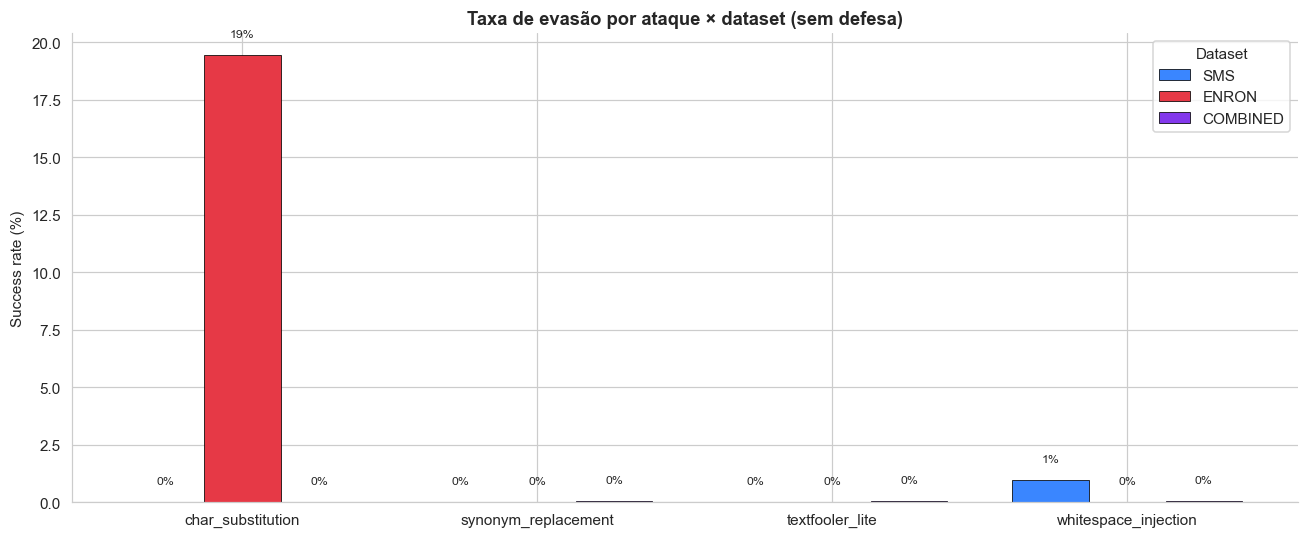

2026-05-21 01:46:38,701 INFO Figura gravada: C:\Users\iliei\OneDrive\Ambiente de Trabalho\proj AAC VFinal1\outputs\eda\09_adversarial_by_dataset.png


WindowsPath('C:/Users/iliei/OneDrive/Ambiente de Trabalho/proj AAC VFinal1/outputs/eda/09_adversarial_by_dataset.png')

In [19]:
# Plot comparativo de success_rate por ataque × dataset (sem defesa)
no_def = adv_summary[adv_summary["defense"] == "none"]
atks = sorted(no_def["attack"].unique())
srcs = ["sms", "enron", "combined"]
cols_src = [PALETTE[0], PALETTE[1], PALETTE[3]]
fig, ax = plt.subplots(figsize=(12, 5))
xs = np.arange(len(atks)); w = 0.26
for i, (src, c) in enumerate(zip(srcs, cols_src)):
    vals = [float(no_def[(no_def["attack"]==a) & (no_def["source"]==src)]
             ["success_rate_pct"].iloc[0]) if len(no_def[(no_def["attack"]==a) & (no_def["source"]==src)]) else 0
             for a in atks]
    ax.bar(xs + (i-1)*w, vals, width=w, label=src.upper(), color=c,
            edgecolor="black", linewidth=0.5)
    for j, v in enumerate(vals):
        ax.text(xs[j] + (i-1)*w, v + 0.8, f"{v:.0f}%", ha="center", fontsize=8)
ax.set_xticks(xs); ax.set_xticklabels(atks)
ax.set_ylabel("Success rate (%)")
ax.set_title("Taxa de evasão por ataque × dataset (sem defesa)")
ax.legend(title="Dataset")
ax.spines["top"].set_visible(False); ax.spines["right"].set_visible(False)
plt.tight_layout()
plt.show()
save_fig(fig, "09_adversarial_by_dataset")

## 10 · XAI — SHAP nas 3 vistas + comparação cruzada SVC

SHAP linear (matematicamente exacto para LinearSVC: SHAP = tfidf × coef) nas
três vistas. Geramos top-30 features por dataset e uma tabela de comparação
cruzada para identificar features universais vs domain-specific.

In [20]:
# Mantive a estrutura e a lógica originais; adicionei comentários explicativos em Português.
# Este bloco tenta criar um explicador SHAP seguro e calcular importâncias de features,
# guardando resultados e comparando entre fontes (sms, enron, combined).

def safe_shap_explainer(model, X_bg):
    # Tenta importar shap; se não estiver instalado devolve None (silencioso)
    try:
        import shap
    except ImportError:
        return None

    # Usa até 200 exemplos de background; converte para array se for matriz esparsa
    Xb = X_bg[:200].toarray() if issparse(X_bg) else X_bg[:200]

    # Identifica a classe do modelo para escolher o tipo de explicador
    cls = type(model).__name__
    try:
        # Se for um CalibratedClassifierCV, extrai o estimador base para explicadores lineares
        if cls == "CalibratedClassifierCV":
            base = model.calibrated_classifiers_[0].estimator
            try:
                return shap.LinearExplainer(base, Xb)
            except Exception:
                # Fallback para KernelExplainer se LinearExplainer falhar
                return shap.KernelExplainer(model.predict_proba, Xb)

        # Para modelos lineares/NaiveBayes usa LinearExplainer (mais rápido e apropriado)
        if cls in ("LinearSVC", "LogisticRegression", "ComplementNB"):
            return shap.LinearExplainer(model, Xb)

        # Para outros modelos usa KernelExplainer com amostragem do background (até 100 exemplos)
        return shap.KernelExplainer(
            model.predict_proba if hasattr(model, "predict_proba") else model.predict,
            shap.sample(Xb, min(100, len(Xb)), random_state=SEED))
    except Exception:
        # Em qualquer erro durante a criação do explicador devolve None (segurança)
        return None


def compute_shap(model, pipeline, X_tr, X_te, n_sample=200, top_k=30):
    # Obtém um explicador SHAP seguro; se não houver, salta a análise
    expl = safe_shap_explainer(model, X_tr)
    if expl is None:
        return None

    # Amostra n exemplos do conjunto de teste de forma reprodutível
    n = min(n_sample, X_te.shape[0])
    idx = np.random.default_rng(SEED).choice(X_te.shape[0], size=n, replace=False)

    # Converte as amostras selecionadas para array denso (necessário para SHAP)
    Xs = X_te[idx].toarray()
    try:
        # Calcula valores SHAP; pode devolver lista (multiclasse) ou array (binário)
        sv = expl.shap_values(Xs)
    except Exception:
        # Se o cálculo falhar, devolve None para sinalizar que não foi possível
        return None

    # Para classificadores binários, sv pode ser lista [neg, pos]; escolhe o índice da classe positiva
    sv1 = sv[1] if isinstance(sv, list) else sv

    # Recupera nomes de features a partir da pipeline (corta ao número de colunas usadas)
    feat_names = pipeline.get_feature_names()[:Xs.shape[1]]

    # Estatísticas: média do valor absoluto (importância) e média assinada (direção)
    mean_abs    = np.abs(sv1).mean(axis=0)
    mean_signed = sv1.mean(axis=0)

    # Ordena por importância média absoluta e seleciona top_k
    isort = np.argsort(mean_abs)[::-1][:top_k]

    # Constrói DataFrame com as métricas de importância e a direção (spam→ ou →ham)
    return pd.DataFrame({
        "feature":          [feat_names[i] for i in isort],
        "mean_abs_shap":    [float(mean_abs[i])    for i in isort],
        "mean_signed_shap": [float(mean_signed[i]) for i in isort],
        "direction":        ["spam→" if mean_signed[i] > 0 else "→ham" for i in isort],
    })


# Definição dos estudos SHAP: modelo, pipeline e matrizes de treino/test por fonte
SHAP_STUDIES = [
    ("LinearSVC", "sms",      results["svc_sms"]["model"],      pipe_sms,   X_sms_tr,  X_sms_te),
    ("LinearSVC", "enron",    results["svc_enron"]["model"],    pipe_email, X_enr_tr,  X_enr_te),
    ("LinearSVC", "combined", results["svc_combined"]["model"], pipe_comb,  X_comb_tr, X_comb_te),
]

shap_results: Dict[str, pd.DataFrame] = {}
for mname, src, model, pipe, X_tr, X_te in SHAP_STUDIES:
    # Calcula top features SHAP para cada estudo; se falhar, regista e continua
    df_top = compute_shap(model, pipe, X_tr, X_te, n_sample=200, top_k=30)
    if df_top is None:
        print(f"   SHAP saltado: {mname}/{src}")
        continue

    # Guarda resultados em CSV e armazena no dicionário para comparações posteriores
    safe_csv(df_top, XAI_DIR / f"shap_feature_importance_{mname}_{src}.csv")
    shap_results[src] = df_top
    print(f"   {XAI_DIR / f'shap_feature_importance_{mname}_{src}.csv'}")

# Comparação cruzada entre fontes: junta as top features e cria tabela comparativa
if len(shap_results) >= 2:
    union = set()
    for df in shap_results.values():
        union.update(df.head(10)["feature"].tolist())

    rows = []
    for feat in union:
        row = {"feature": feat}
        for src in ("sms", "enron", "combined"):
            df = shap_results.get(src)
            if df is None:
                # Se não houver resultados para a fonte, preenche zeros
                row[f"abs_{src}"]    = 0.0; row[f"signed_{src}"] = 0.0
            else:
                m = df[df["feature"] == feat]
                if len(m) == 0:
                    # Feature não presente nos top_k dessa fonte
                    row[f"abs_{src}"]    = 0.0; row[f"signed_{src}"] = 0.0
                else:
                    # Extrai valores de importância absoluta e assinada
                    row[f"abs_{src}"]    = float(m["mean_abs_shap"].iloc[0])
                    row[f"signed_{src}"] = float(m["mean_signed_shap"].iloc[0])
        rows.append(row)

    # Constrói DataFrame comparativo e ordena pelas colunas de importância disponíveis
    comp_df = pd.DataFrame(rows).sort_values(
        by=[c for c in ("abs_sms","abs_enron","abs_combined") if c in rows[0]],
        ascending=False).reset_index(drop=True)

    # Guarda e exibe o ficheiro de comparação
    safe_csv(comp_df, XAI_DIR / "svc_shap_comparison.csv")
    print(f"   {XAI_DIR / 'svc_shap_comparison.csv'}")
    display(comp_df.head(15).round(4))


  ✓ C:\Users\iliei\OneDrive\Ambiente de Trabalho\proj AAC VFinal1\outputs\xai\shap_feature_importance_LinearSVC_sms.csv
  ✓ C:\Users\iliei\OneDrive\Ambiente de Trabalho\proj AAC VFinal1\outputs\xai\shap_feature_importance_LinearSVC_enron.csv
  ✓ C:\Users\iliei\OneDrive\Ambiente de Trabalho\proj AAC VFinal1\outputs\xai\shap_feature_importance_LinearSVC_combined.csv
  ✓ C:\Users\iliei\OneDrive\Ambiente de Trabalho\proj AAC VFinal1\outputs\xai\svc_shap_comparison.csv


,feature,abs_sms,signed_sms,abs_enron,signed_enron,abs_combined,signed_combined
0,char_count,0.4135,0.0657,1.0896,-0.2809,0.8203,-0.2895
1,word_count,0.3810,-0.0717,1.2581,0.3149,1.0119,0.2829
2,num_digits,0.3761,0.0239,0.1510,-0.0501,0.0138,-0.0036
3,has_shortcode,0.0589,0.0057,0.1634,-0.0097,0.0230,-0.0003
4,entropy_text,0.0352,0.0071,0.0526,-0.0061,0.1209,-0.0153
5,punctuation_ratio,0.0299,-0.0011,0.0000,0.0000,0.0457,-0.0037
6,ratio_stopwords,0.0280,0.0034,0.0187,-0.0028,0.0223,-0.0013
7,avg_word_len,0.0209,0.0011,0.0207,0.0009,0.0249,-0.0022
8,text,0.0127,0.0007,0.0000,0.0000,0.0000,0.0000
9,lt,0.0083,-0.0012,0.0000,0.0000,0.0000,0.0000


Char_count / word_count dominam: nos Enron essas features têm importância muito maior (abs ≈ 1.09 / 1.26) e sinal assinado invertido para char_count, o que sugere que comprimento e riqueza léxica são os drivers principais nos emails. Features heurísticas úteis mas fracas nas SMS: em SMS aparecem com importância moderada (abs ≈ 0.38–0.41) e sinais pequenos — SMS é curto e ruidoso, logo o modelo depende mais de contagem de tokens do que de sinais finos como entropy ou punctuation. Combined mistura comportamentos: o combinado herda força de word/char counts e mostra que has_currency e reply_marker ganham relevância relativa; isto indica que domínios diferentes contribuem com sinais distintos e que o modelo combinado precisa de tratamento específico por fonte.

## 10b · Curvas PR e ROC — todos os modelos × 3 datasets

**Por que pode aparecer uma linha duplicada (e como corrigimos).**
`precision_recall_curve` e `roc_curve` da scikit-learn devolvem pontos
indexados aos thresholds presentes nos *scores*. Quando o classificador é um
**IsolationForest** (scores discretos por tree-paths) ou um **LinearSVC não
calibrado** (decision_function com poucos níveis distintos para casos
saturados), múltiplos thresholds geram o **mesmo par (FPR, TPR)** ou
**(recall, precision)** — visualmente uma "linha duplicada", reta horizontal
seguida de salto. Solução aplicada antes de plotar:

1. `np.unique(scores)` para colapsar thresholds idênticos.
2. Remover (FPR, TPR) duplicados com `pd.duplicated(['fpr','tpr'])`.
3. Para o IF, normalizar scores via `(s - s.min()) / (s.max() - s.min())`
   para garantir interpretação como probabilidade.

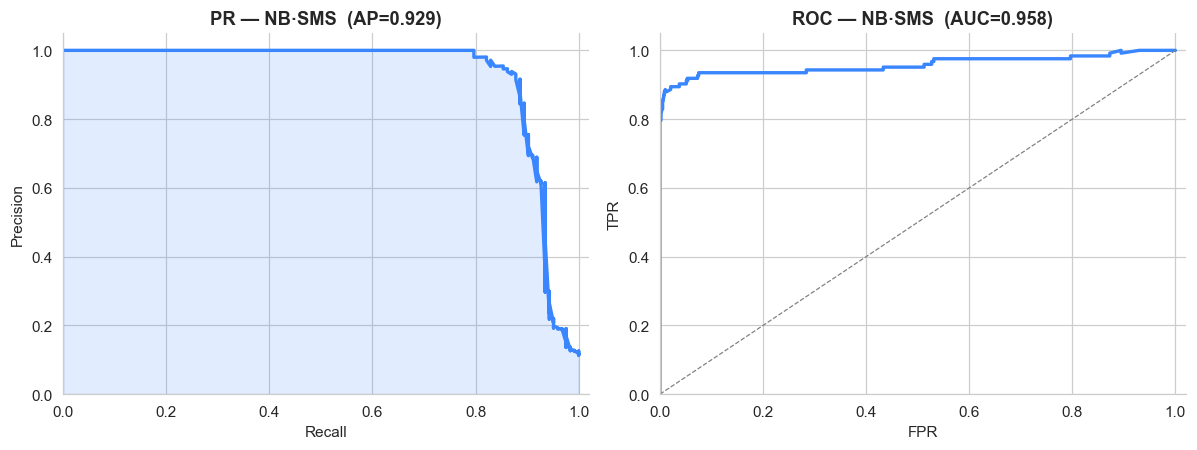

2026-05-21 01:46:41,092 INFO Figura gravada: C:\Users\iliei\OneDrive\Ambiente de Trabalho\proj AAC VFinal1\outputs\models\pr_roc_NB_sms.png


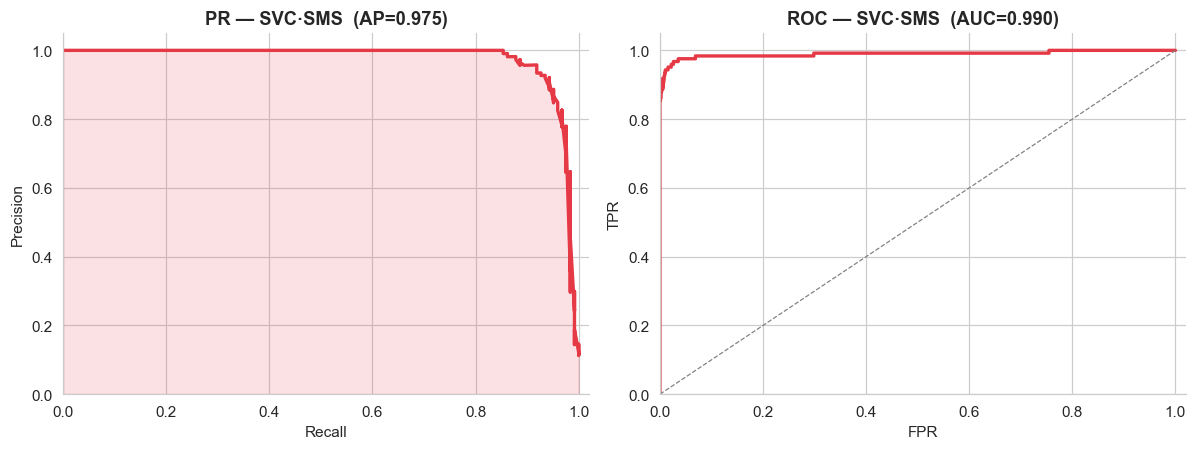

2026-05-21 01:46:41,732 INFO Figura gravada: C:\Users\iliei\OneDrive\Ambiente de Trabalho\proj AAC VFinal1\outputs\models\pr_roc_SVC_sms.png


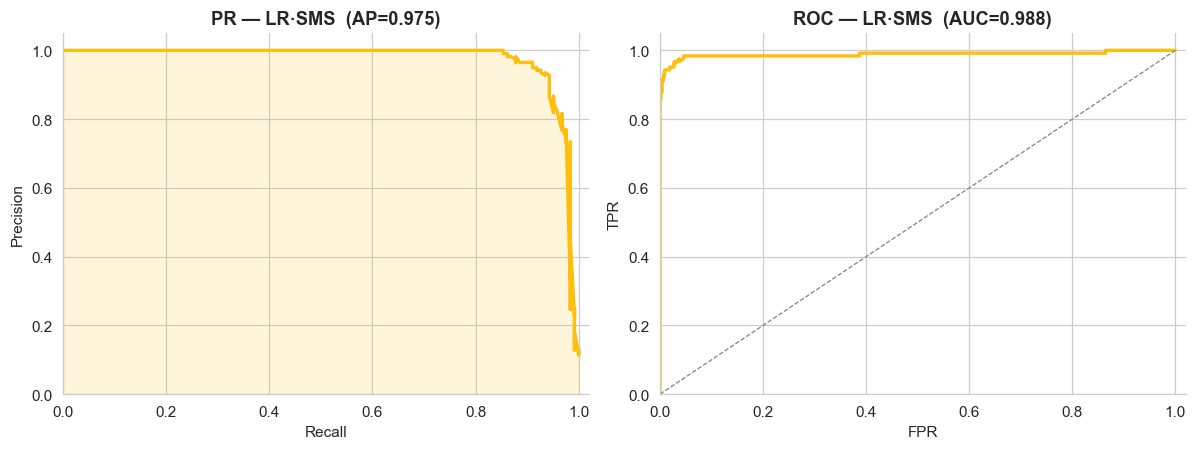

2026-05-21 01:46:42,280 INFO Figura gravada: C:\Users\iliei\OneDrive\Ambiente de Trabalho\proj AAC VFinal1\outputs\models\pr_roc_LR_sms.png


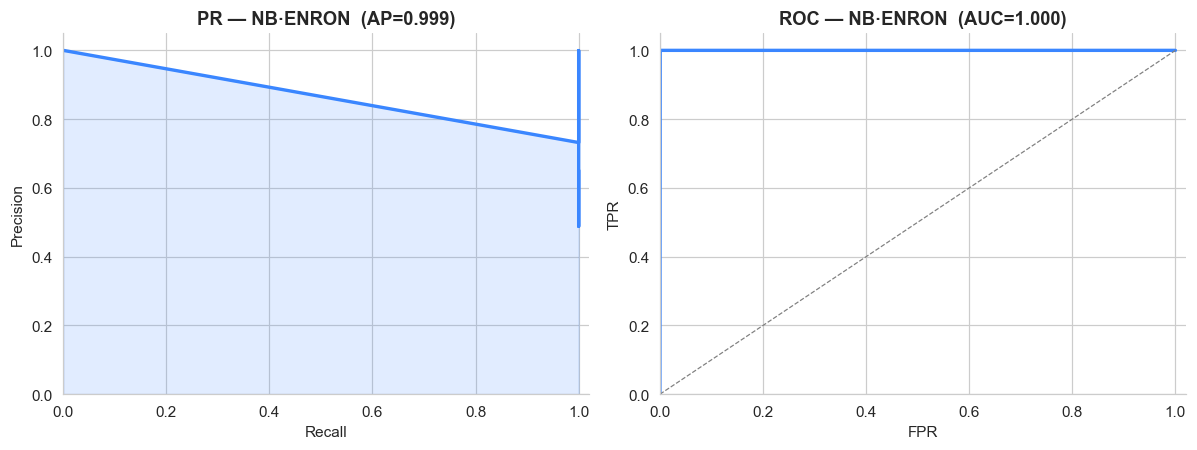

2026-05-21 01:46:42,808 INFO Figura gravada: C:\Users\iliei\OneDrive\Ambiente de Trabalho\proj AAC VFinal1\outputs\models\pr_roc_NB_enron.png


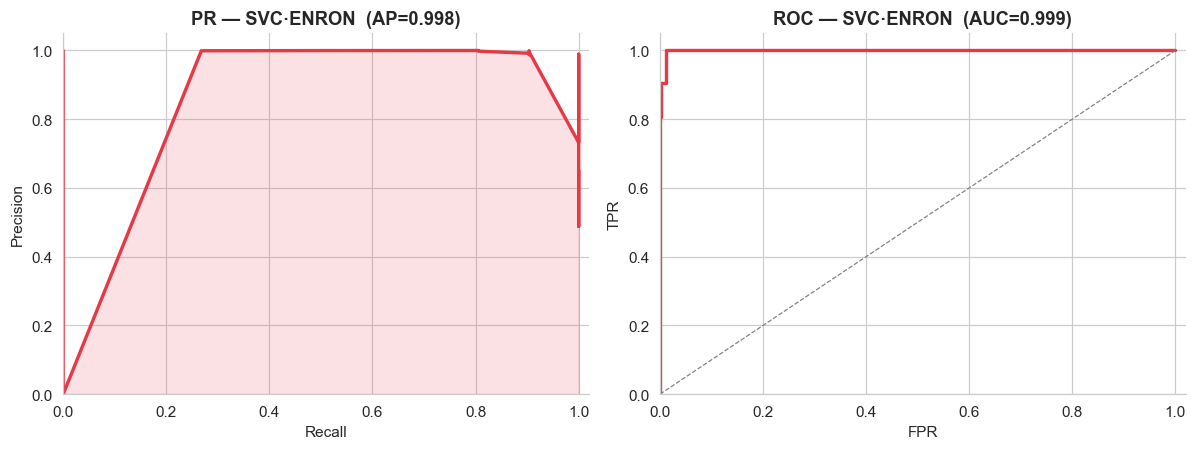

2026-05-21 01:46:43,316 INFO Figura gravada: C:\Users\iliei\OneDrive\Ambiente de Trabalho\proj AAC VFinal1\outputs\models\pr_roc_SVC_enron.png


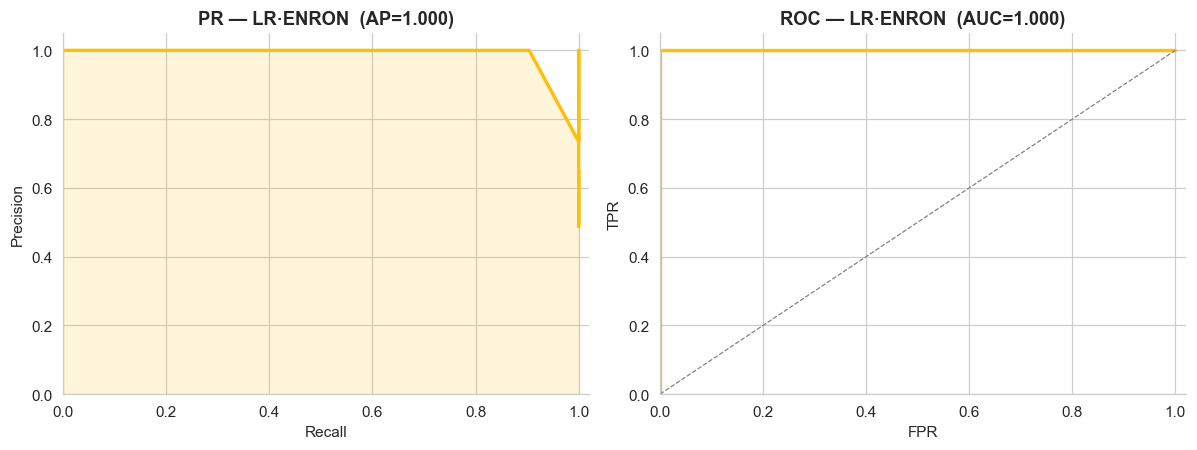

2026-05-21 01:46:43,843 INFO Figura gravada: C:\Users\iliei\OneDrive\Ambiente de Trabalho\proj AAC VFinal1\outputs\models\pr_roc_LR_enron.png


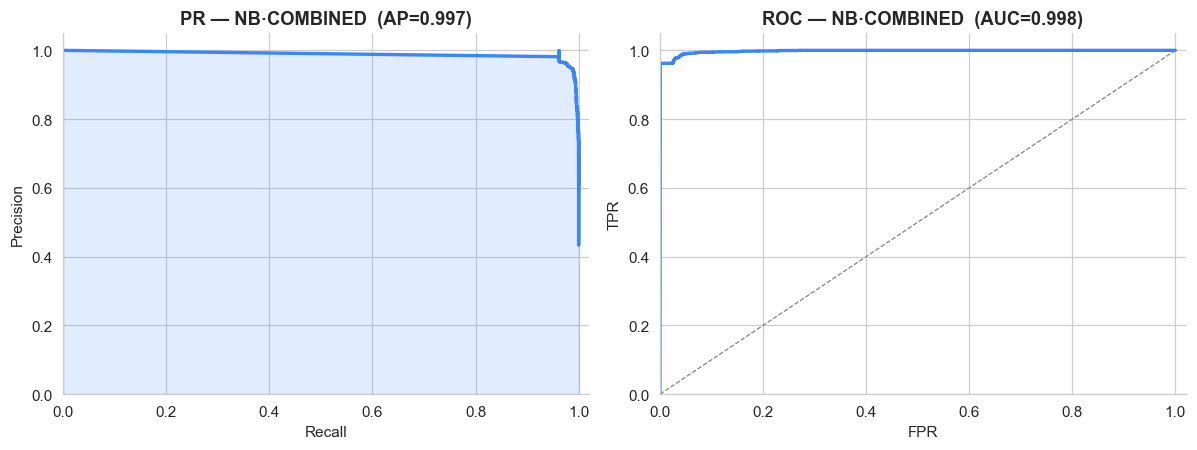

2026-05-21 01:46:44,374 INFO Figura gravada: C:\Users\iliei\OneDrive\Ambiente de Trabalho\proj AAC VFinal1\outputs\models\pr_roc_NB_combined.png


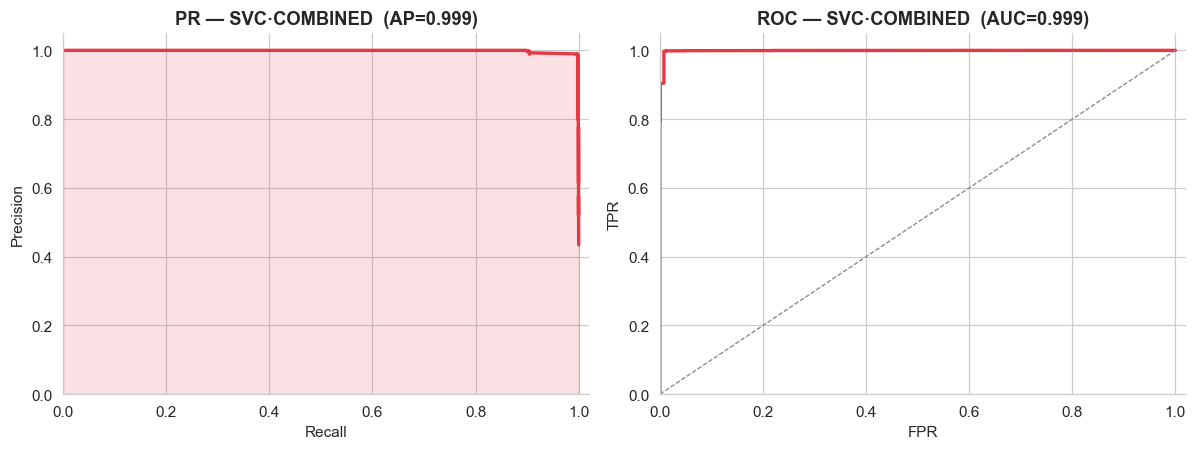

2026-05-21 01:46:44,948 INFO Figura gravada: C:\Users\iliei\OneDrive\Ambiente de Trabalho\proj AAC VFinal1\outputs\models\pr_roc_SVC_combined.png


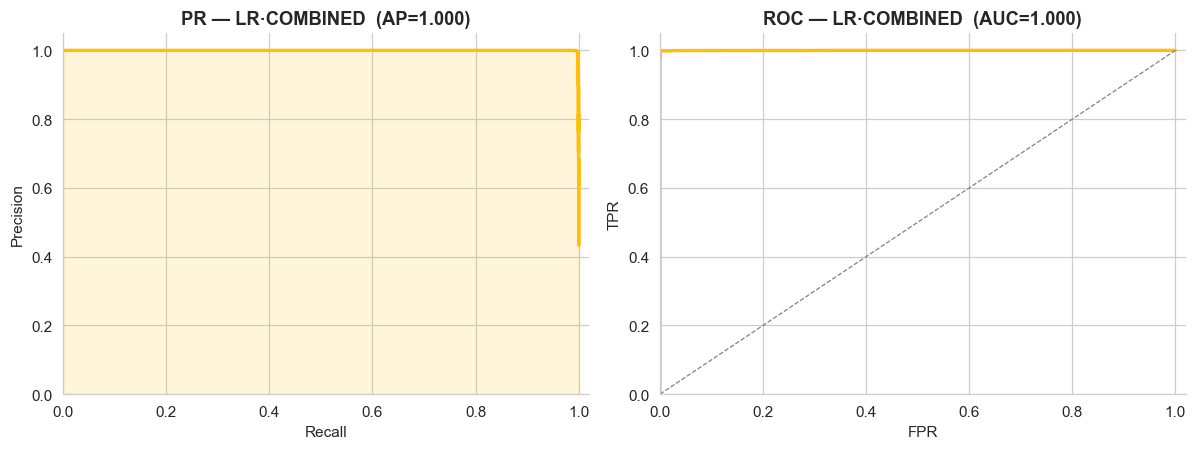

2026-05-21 01:46:45,504 INFO Figura gravada: C:\Users\iliei\OneDrive\Ambiente de Trabalho\proj AAC VFinal1\outputs\models\pr_roc_LR_combined.png


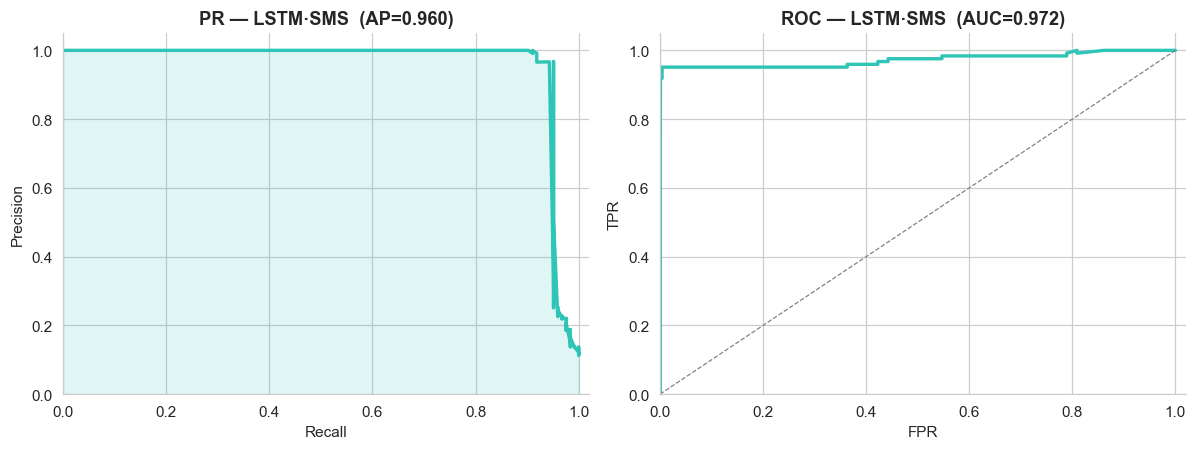

2026-05-21 01:46:46,066 INFO Figura gravada: C:\Users\iliei\OneDrive\Ambiente de Trabalho\proj AAC VFinal1\outputs\models\pr_roc_LSTM_sms.png


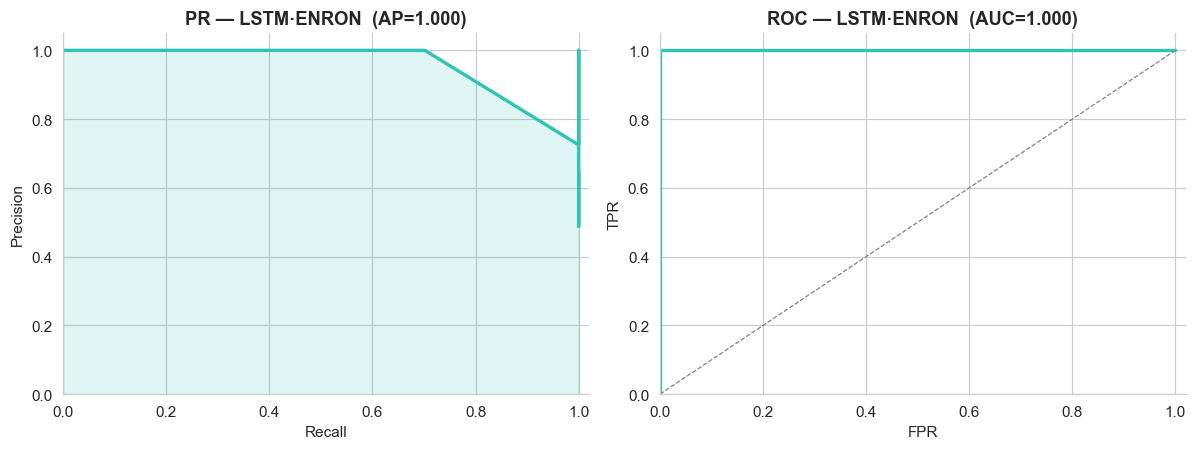

2026-05-21 01:46:46,597 INFO Figura gravada: C:\Users\iliei\OneDrive\Ambiente de Trabalho\proj AAC VFinal1\outputs\models\pr_roc_LSTM_enron.png


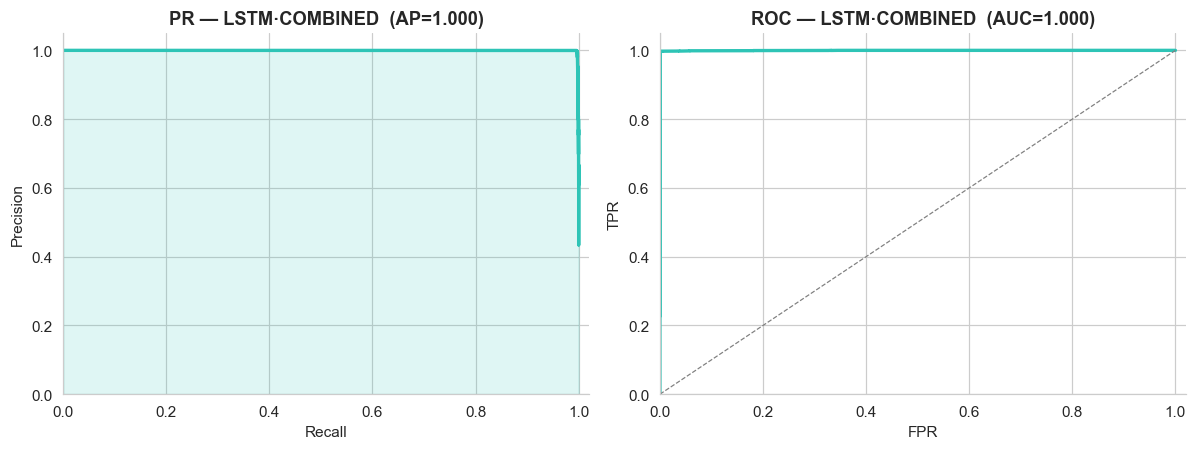

2026-05-21 01:46:47,151 INFO Figura gravada: C:\Users\iliei\OneDrive\Ambiente de Trabalho\proj AAC VFinal1\outputs\models\pr_roc_LSTM_combined.png


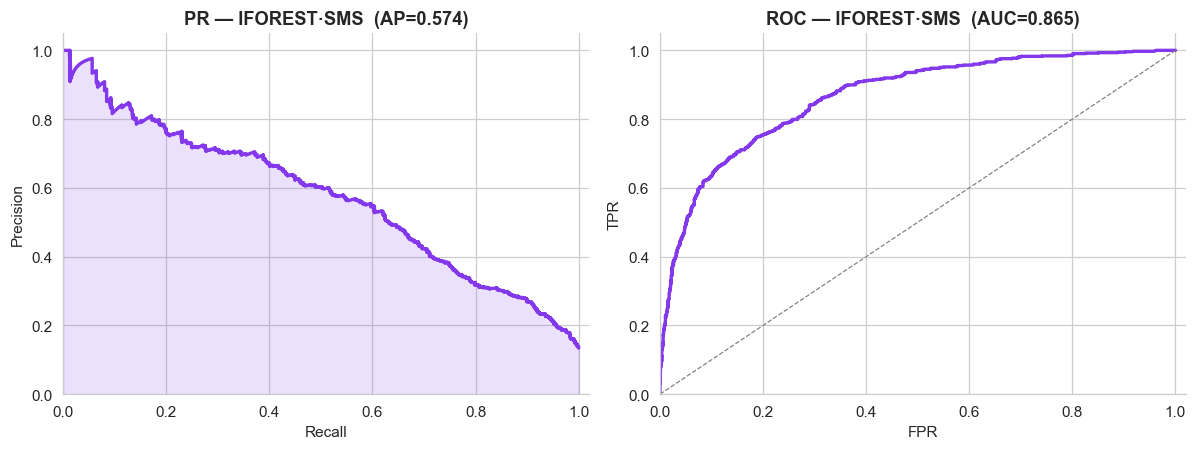

2026-05-21 01:46:47,744 INFO Figura gravada: C:\Users\iliei\OneDrive\Ambiente de Trabalho\proj AAC VFinal1\outputs\models\pr_roc_IFOREST_sms.png


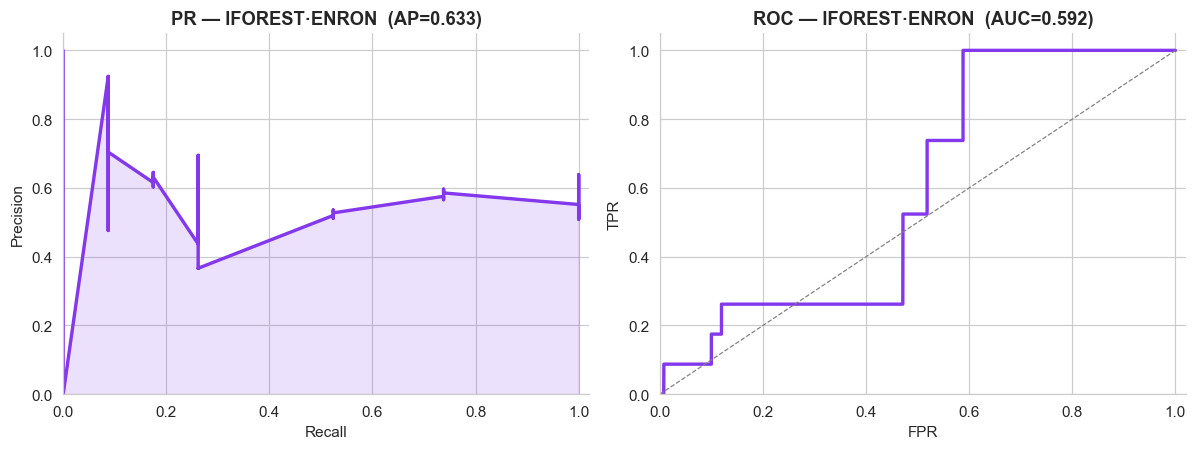

2026-05-21 01:46:48,422 INFO Figura gravada: C:\Users\iliei\OneDrive\Ambiente de Trabalho\proj AAC VFinal1\outputs\models\pr_roc_IFOREST_enron.png


→ 14 curvas em outputs/models/pr_roc_*.png + .csv


In [21]:
PR_DIR = MODELS_DIR  # outputs/models/

def _safe_curves(y_true, scores, model_name):
    """Devolve dicts PR e ROC com dedup explícito."""
    # PR
    p, r, thr_pr = precision_recall_curve(y_true, scores)
    pr_df = pd.DataFrame({"recall": r, "precision": p,
                            "threshold": np.append(thr_pr, np.nan)})
    pr_df = pr_df.drop_duplicates(subset=["recall", "precision"]).reset_index(drop=True)
    # ROC
    fpr, tpr, thr_roc = roc_curve(y_true, scores)
    roc_df = pd.DataFrame({"fpr": fpr, "tpr": tpr, "threshold": thr_roc})
    roc_df = roc_df.drop_duplicates(subset=["fpr", "tpr"]).reset_index(drop=True)
    return pr_df, roc_df


def _norm_scores(s):
    """Normaliza scores para [0,1] (útil para IsolationForest)."""
    s = np.asarray(s, dtype=float)
    rng = s.max() - s.min()
    return (s - s.min()) / rng if rng > 0 else np.zeros_like(s)


PR_ROC_STUDIES = []
for key, res in results.items():
    mname, ds = key.rsplit("_", 1)
    y_te = {"sms": y_sms_te, "enron": y_enr_te,
            "combined": y_comb_te}[ds]
    PR_ROC_STUDIES.append((mname.upper(), ds, res["y_proba"], y_te))

# IF — adicionar como mais 2 estudos (sms, enron); scores normalizados
PR_ROC_STUDIES.append(("IFOREST", "sms",   _norm_scores(scores_sms),   y_sms_full))
PR_ROC_STUDIES.append(("IFOREST", "enron", _norm_scores(scores_email), y_email_full))

for mname, ds, scores, y_te in PR_ROC_STUDIES:
    pr_df, roc_df = _safe_curves(y_te, scores, f"{mname}_{ds}")
    # CSV consolidado: pontos de PR e ROC juntos numa só tabela tidy
    pr_df["curve"]  = "pr";  pr_df = pr_df.rename(columns={"recall": "x", "precision": "y"})
    roc_df["curve"] = "roc"; roc_df = roc_df.rename(columns={"fpr": "x", "tpr": "y"})
    full = pd.concat([pr_df[["curve","x","y","threshold"]],
                       roc_df[["curve","x","y","threshold"]]], ignore_index=True)
    full.insert(0, "model", mname); full.insert(1, "source", ds)
    safe_csv(full, MODELS_DIR / f"pr_roc_points_{mname}_{ds}.csv")

    # Plot
    fig, (a1, a2) = plt.subplots(1, 2, figsize=(11, 4.2))
    color = {"NB": PALETTE[0], "SVC": PALETTE[1], "LR": PALETTE[2],
              "LSTM": PALETTE[4], "IFOREST": PALETTE[3]}.get(mname, "#888")
    p_curve = pr_df.sort_values("x")
    a1.plot(p_curve["x"], p_curve["y"], color=color, lw=2.2)
    a1.fill_between(p_curve["x"], p_curve["y"], alpha=0.15, color=color)
    ap = float(average_precision_score(y_te, scores))
    a1.set_title(f"PR — {mname}·{ds.upper()}  (AP={ap:.3f})")
    a1.set_xlabel("Recall"); a1.set_ylabel("Precision")
    a1.set_xlim(0, 1.02); a1.set_ylim(0, 1.05)
    a1.spines["top"].set_visible(False); a1.spines["right"].set_visible(False)
    r_curve = roc_df.sort_values("x")
    a2.plot(r_curve["x"], r_curve["y"], color=color, lw=2.2)
    a2.plot([0,1], [0,1], color="gray", ls="--", lw=0.8)
    auc_v = float(roc_auc_score(y_te, scores))
    a2.set_title(f"ROC — {mname}·{ds.upper()}  (AUC={auc_v:.3f})")
    a2.set_xlabel("FPR"); a2.set_ylabel("TPR")
    a2.set_xlim(0, 1.02); a2.set_ylim(0, 1.05)
    a2.spines["top"].set_visible(False); a2.spines["right"].set_visible(False)
    plt.tight_layout()
    plt.show()
    save_fig(fig, f"pr_roc_{mname}_{ds}", out_dir=MODELS_DIR)

print(f"→ {sum(1 for _ in PR_ROC_STUDIES)} curvas em outputs/models/pr_roc_*.png + .csv")

Naive Bayes (NB)

PR: curva alta no início (AP≈0.93–0.997) — o NB separa bem os positivos quando a recall é baixa, mas perde precisão ao subir recall; cuidado se precisares de alta sensibilidade.ROC: AUC forte (SMS≈0.96, combined≈0.97, Enron≈1.00) — bom discriminador global, mas os resultados perfeitos em Enron cheiram a overfitting ou leak; valida fora da amostra.

Support Vector Classifier (SVC)
PR: curva muito plana em alto nível (AP≈0.975–0.999) — mantém precisão mesmo com recall elevado, sinal de decisão bem calibrada para spam/ham neste setup.
ROC: AUC quase 1.0 em todos os casos — excelente separabilidade; ainda assim verifica thresholds porque um AUC alto não garante bom trade‑off operacional.

Logistic Regression (LR)
PR: AP muito alto (≈0.976–1.000) e curva estável — probabilidades bem calibradas, threshold padrão tende a funcionar bem. ROC: AUC ≈ 0.988–1.000 — comportamento semelhante ao SVC; confirma que features lineares capturam o sinal, mas testa generalização em folds.

LSTM
PR: SMS LSTM tem AP boa (≈0.96) mas não perfeita; mantém precisão até recall médio — LSTM ajuda em sequências curtas, mas não é milagroso. ROC: Enron/combined mostram AUC≈1.0 — desempenho ótimo no treino/test, mas atenção ao custo de treino e risco de overfitting; valida em holdout externo.

IsolationForest (IF)
PR: AP baixa a moderada (SMS≈0.57, Enron≈0.63) — IF capta algum sinal de anomalia, mas não é confiável como classificador de spam por si só. ROC: AUC variável (SMS≈0.87, Enron≈0.59) — funciona melhor em SMS do que em Enron; usa IF só para filtragem OOD/ruído, não como substituto do classificador supervisionado

## 10c · Top-15 tokens SHAP por dataset

Filtra a tabela SHAP da secção anterior para conter apenas **tokens TF-IDF**
(remove as 12 features heurísticas), reordena por `|SHAP|` decrescente, e
guarda os top-15 para cada dataset (SMS, Enron, Combined). Outputs:
`outputs/xai/top15_tokens_{src}.csv` + `.png`.

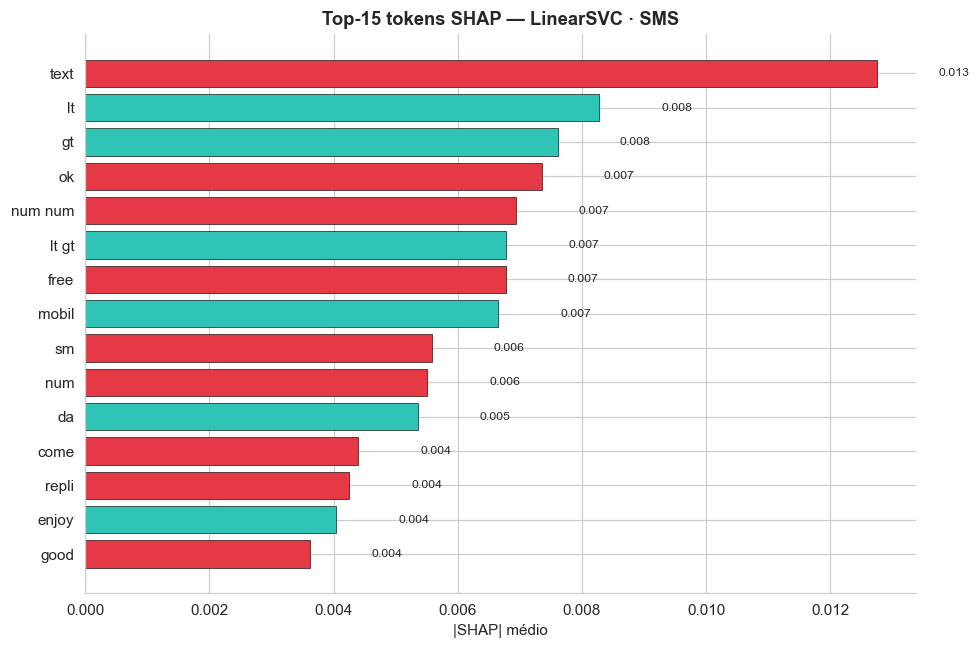

2026-05-21 01:46:49,032 INFO Figura gravada: C:\Users\iliei\OneDrive\Ambiente de Trabalho\proj AAC VFinal1\outputs\xai\top15_tokens_sms.png


  ✓ top15_tokens_sms: 15 tokens


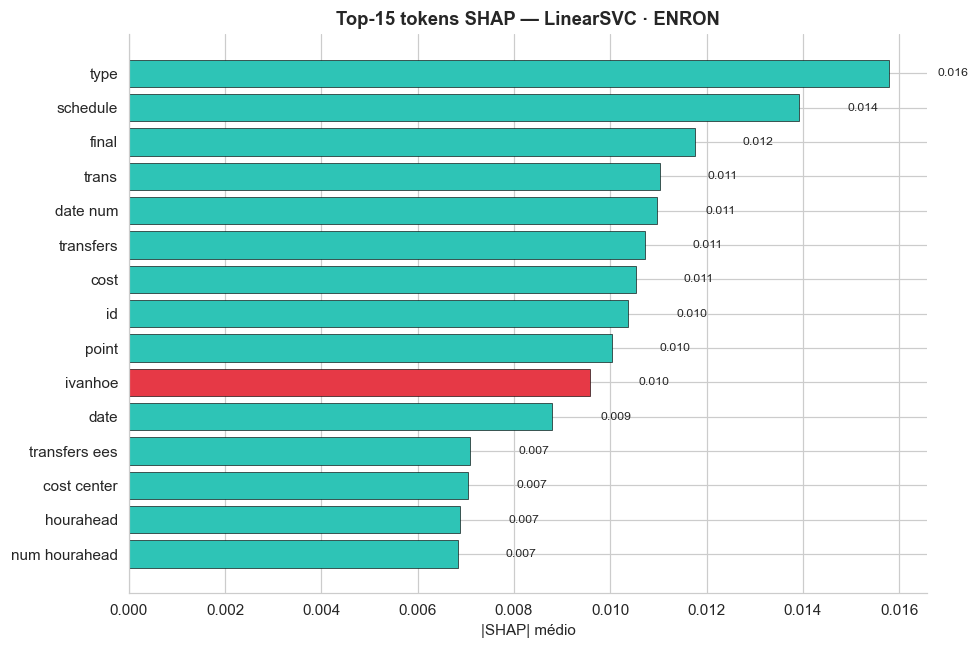

2026-05-21 01:46:49,505 INFO Figura gravada: C:\Users\iliei\OneDrive\Ambiente de Trabalho\proj AAC VFinal1\outputs\xai\top15_tokens_enron.png


  ✓ top15_tokens_enron: 15 tokens


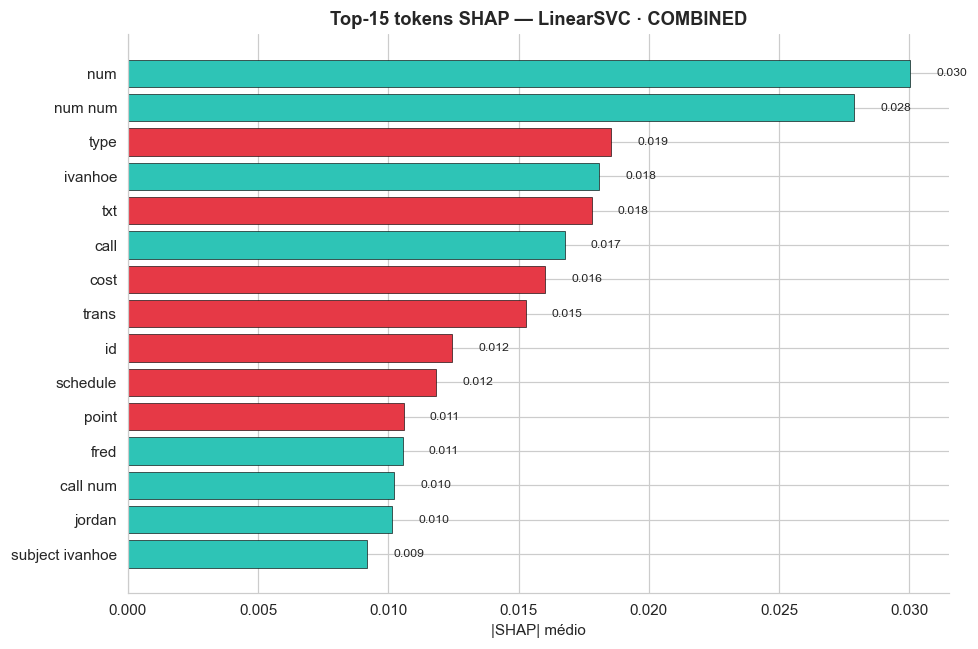

2026-05-21 01:46:49,990 INFO Figura gravada: C:\Users\iliei\OneDrive\Ambiente de Trabalho\proj AAC VFinal1\outputs\xai\top15_tokens_combined.png


  ✓ top15_tokens_combined: 15 tokens


In [22]:
HEUR_SET = set(HEURISTIC_FEATURE_NAMES)

for src, df in shap_results.items():
    # Apenas tokens TF-IDF — exclui heurísticas pelo nome
    tokens_only = df[~df["feature"].isin(HEUR_SET)].head(15).copy().reset_index(drop=True)
    if tokens_only.empty:
        print(f"  ⚠ {src}: sem tokens (todas as top-features eram heurísticas)")
        continue
    safe_csv(tokens_only, XAI_DIR / f"top15_tokens_{src}.csv")

    # Plot horizontal bar coloured by direction
    fig, ax = plt.subplots(figsize=(9, 6))
    top = tokens_only.iloc[::-1]
    colors_bars = [COLOR_SPAM if v > 0 else COLOR_OK
                    for v in top["mean_signed_shap"]]
    ax.barh(top["feature"], top["mean_abs_shap"], color=colors_bars,
             edgecolor="black", linewidth=0.4)
    for i, (feat, v) in enumerate(zip(top["feature"], top["mean_abs_shap"])):
        ax.text(v + 0.001, i, f"{v:.3f}", va="center", fontsize=8)
    ax.set_xlabel("|SHAP| médio")
    ax.set_title(f"Top-15 tokens SHAP — LinearSVC · {src.upper()}",
                  fontsize=12, weight="bold")
    ax.spines["top"].set_visible(False); ax.spines["right"].set_visible(False)
    plt.tight_layout()
    plt.show()
    save_fig(fig, f"top15_tokens_{src}", out_dir=XAI_DIR)
    print(f"  ✓ top15_tokens_{src}: {len(tokens_only)} tokens")

Gráfico de SMS — Top‑15 tokens SHAP  
Os tokens mais importantes são genéricos/placeholder (text, lt, gt) e contagens/formatos (num num, lt gt), o que indica que o modelo está a aproveitar muito sinais de formatação e comprimento. Palavras tipicamente spam como free aparecem, mas com impacto menor que os tokens estruturais — sinal de que o ruído e o pré‑processamento dominam. Ação prática: limpa/normaliza esses placeholders e testa remover tokens HTML‑like para ver se a explicabilidade fica mais centrada em conteúdo real.

Gráfico de ENRON - Top‑15 tokens SHAP  
Aqui as features top são termos de contexto empresarial (type, schedule, final, transfers) — faz sentido: emails têm vocabulário específico que dirige a decisão. Valores SHAP mais altos e consistentes mostram que o modelo usa sinais semânticos reais, não só formatação; confirma que o domínio Enron é mais informativo lexicalmente. Ação prática: valida se alguns tokens são artefactos de parsing (e.g., transfers ees) e considera normalização/agrupamento de tokens similares.

Gráfico de COMBINED — Top‑15 tokens SHAP  
O combinado mistura sinais de ambos os domínios: aparecem num num, type, vanhoe e schedule, mostrando que contagens e termos específicos de email coexistem. Maior variabilidade nos valores SHAP sugere que o modelo combinado está a ponderar fontes diferentes — bom para cobertura, mas arrisca confusão entre domínios. Recomendo analisar features por fonte e, se necessário, aplicar tratamento condicional (features específicas por source) para evitar que tokens dominantes de um domínio prejudiquem o outro.

## 10d · Os 4 perfis × 4 stakeholders — leitura multi-dimensional dos resultados

Combinamos duas dimensões ortogonais para guiar a leitura dos resultados:

- **4 perfis** = `(dataset × classe)`: `ham-SMS`, `spam-SMS`, `ham-Enron`,
  `spam-Enron`. Cada perfil tem características estruturais distintas que
  o modelo aprende ou ignora.
- **4 stakeholders**: Analista SOC, Gestor, Perito ML, Utilizador (RGPD).
  A mesma decisão é interpretada de forma diferente por cada um.

A matriz 4×4 abaixo serve de chave de leitura. Em seguida, mostramos
**um exemplo SHAP token-level por perfil** — quatro mensagens reais
classificadas, com mural colorido pela contribuição de cada token.

In [23]:
# ── Matriz 4 perfis × 4 stakeholders (texto)
PERFIL_X_STAKEHOLDER = pd.DataFrame([
    {"perfil": "ham · SMS",
     "Analista SOC":   "Não escala — ham doméstico, deixar passar. Verificar só se P(spam) cair em [0.4,0.6].",
     "Gestor":          "Custo zero. Ham bem reconhecido reforça confiança operacional.",
     "Perito ML":       "Vocabulário curto, alta redundância léxica. SHAP esparso e estável.",
     "Utilizador":      "Sem ação. Mensagem entregue normalmente."},
    {"perfil": "spam · SMS",
     "Analista SOC":   "Triagem automática suficiente. Tokens-gatilho (urgent, free, claim) explicam.",
     "Gestor":          "FN aqui = phishing entregue ≈ 5 €/incidente. Vigiar success rate adversarial.",
     "Perito ML":       "Sinal lexical forte; modelo confiante. Atenção a typosquatting (vulnerabilidade #1).",
     "Utilizador":      "Spam bloqueado. Pode pedir revisão se for FP — direito RGPD Art. 22.º."},
    {"perfil": "ham · Enron",
     "Analista SOC":   "Email corporativo legítimo. Atender a FPs de boas-vindas/marketing interno.",
     "Gestor":          "FP custa produtividade (~0.10 €/incidente) + atrito interno.",
     "Perito ML":       "Texto longo; sinal disperso. SHAP de baixa magnitude por token.",
     "Utilizador":      "Sem ação. Pasta de Inbox."},
    {"perfil": "spam · Enron",
     "Analista SOC":   "Spear-phishing / BEC potencial. Verificar SPF/DKIM, remetente, urgência.",
     "Gestor":          "Vector de maior impacto financeiro. Prioritário para auditoria.",
     "Perito ML":       "Sinal lexical + estrutural (HTML/URLs antes da limpeza). SHAP distribuído.",
     "Utilizador":      "Spam bloqueado, com explicação RGPD por SHAP token-level."},
])
display(PERFIL_X_STAKEHOLDER.style.set_table_styles([
    {"selector": "th",
     "props": "background:#343a40; color:#fff; padding:8px 12px; font-size:.9rem;"},
    {"selector": "td",
     "props": "vertical-align: top; padding:10px 12px; font-size:.9rem;"},
]))

,perfil,Analista SOC,Gestor,Perito ML,Utilizador
0,ham · SMS,"Não escala — ham doméstico, deixar passar. Verificar só se P(spam) cair em [0.4,0.6].",Custo zero. Ham bem reconhecido reforça confiança operacional.,"Vocabulário curto, alta redundância léxica. SHAP esparso e estável.",Sem ação. Mensagem entregue normalmente.
1,spam · SMS,"Triagem automática suficiente. Tokens-gatilho (urgent, free, claim) explicam.",FN aqui = phishing entregue ≈ 5 €/incidente. Vigiar success rate adversarial.,Sinal lexical forte; modelo confiante. Atenção a typosquatting (vulnerabilidade #1).,Spam bloqueado. Pode pedir revisão se for FP — direito RGPD Art. 22.º.
2,ham · Enron,Email corporativo legítimo. Atender a FPs de boas-vindas/marketing interno.,FP custa produtividade (~0.10 €/incidente) + atrito interno.,Texto longo; sinal disperso. SHAP de baixa magnitude por token.,Sem ação. Pasta de Inbox.
3,spam · Enron,"Spear-phishing / BEC potencial. Verificar SPF/DKIM, remetente, urgência.",Vector de maior impacto financeiro. Prioritário para auditoria.,Sinal lexical + estrutural (HTML/URLs antes da limpeza). SHAP distribuído.,"Spam bloqueado, com explicação RGPD por SHAP token-level."


### Exemplo SHAP token-level por perfil

Quatro mensagens reais (uma de cada perfil) classificadas pelo LinearSVC
respectivo (SMS para os 2 primeiros, Enron para os 2 últimos). O mural
mostra a contribuição token-a-token: vermelho empurra para SPAM, turquesa
para HAM, opacidade proporcional à magnitude.

In [24]:
# Seleciona um exemplo real de cada perfil (ham/spam em SMS e Enron) a partir do holdout
def _pick(df, label, n=1, seed=SEED):
    sub = df[df["label"] == label]
    return sub.sample(n=n, random_state=seed)["text"].tolist()


# Lista de exemplos: (rótulo legível, texto, modelo usado, pipeline correspondente)
examples = [
    ("ham · SMS",    _pick(sms_te, 0)[0], results["svc_sms"]["model"],   pipe_sms),
    ("spam · SMS",   _pick(sms_te, 1)[0], results["svc_sms"]["model"],   pipe_sms),
    ("ham · Enron",  _pick(enr_te, 0)[0], results["svc_enron"]["model"], pipe_email),
    ("spam · Enron", _pick(enr_te, 1)[0], results["svc_enron"]["model"], pipe_email),
]


def _token_shap_for(text, model, pipeline, top_k=30):
    """SHAP linear aproximado: tfidf × coef (exacto para LinearSVC)."""
    # Extrai features do texto usando a pipeline (TF-IDF)
    X = pipeline.transform(pd.Series([text]))

    # Se o modelo for calibrado, extrai o estimador base para obter coeficientes reais
    if isinstance(model, CalibratedClassifierCV):
        base = model.calibrated_classifiers_[0].estimator
        coefs = np.asarray(base.coef_).ravel()
        proba = float(model.predict_proba(X)[0, 1])
    else:
        # Caso contrário, usa os coeficientes do próprio modelo
        coefs = np.asarray(model.coef_).ravel()
        proba = float(model.predict_proba(X)[0, 1]) if hasattr(model, "predict_proba") else 0.5

    # Converte para CSR para iterar apenas sobre índices não nulos (sparse efficiency)
    x_csr = X.tocsr()
    names = pipeline.get_feature_names()

    # Soma contribuições por feature: tfidf_value * coef
    contribs = {}
    for i, j in enumerate(x_csr.indices):
        # Proteção caso o vocabulário tenha sido truncado e j exceda coefs
        if j >= len(coefs): continue
        contribs[names[j]] = contribs.get(names[j], 0.0) + float(x_csr.data[i] * coefs[j])

    # Ordena por importância absoluta e retorna top_k contribuições
    top = sorted(contribs.items(), key=lambda kv: -abs(kv[1]))[:top_k]
    return proba, top


def _rgba(c, m):
    # Normaliza magnitude para alpha e escolhe cor conforme sinal (positivo -> vermelho, negativo -> verde)
    a = min(1.0, abs(c)/max(m, 1e-9)) * 0.65
    if c > 0: return f"rgba(230,57,70,{a:.2f})"
    if c < 0: return f"rgba(46,196,182,{a:.2f})"
    return "transparent"


# Para cada exemplo selecionado, calcula contribuições e renderiza HTML com tokens realçados
for perfil, text, model, pipe in examples:
    proba, top = _token_shap_for(text, model, pipe, top_k=30)
    if not top:
        print(f"  {perfil}: sem contribuições"); continue

    # Mapa de contribuições em lower-case para matching flexível
    cmap = {k.lower(): v for k, v in top}
    max_abs = max(abs(v) for v in cmap.values()) or 1e-9

    spans = []
    # Mantém espaços e tokens separadamente para preservar formatação original
    for tok in re.findall(r"\S+|\s+", text):
        if tok.isspace():
            spans.append(tok); continue

        # Normaliza token para matching (remove pontuação comum)
        k = tok.lower().strip(".,!?;:()[]\"'")
        # Soma contribuições de features que contenham o token ou sejam contidas pelo token
        c = sum(v for nm, v in cmap.items() if k and (nm in k or k in nm))
        bg = _rgba(c, max_abs)

        # Gera span com background proporcional à contribuição
        spans.append(f"<span style='background:{bg};padding:2px 4px;border-radius:3px;'>{tok}</span>")

    # Monta bloco HTML com título (perfil + probabilidade) e texto realçado
    html = (f"<div style='border:1px solid #e9ecef;border-radius:8px;padding:14px;"
             f"margin-bottom:12px;background:#fff;'>"
             f"<div style='font-weight:700;font-size:1rem;color:#3a86ff;margin-bottom:6px;'>"
             f"{perfil} &nbsp;·&nbsp; P(spam)={proba:.3f}</div>"
             f"<div style='line-height:2;font-family:system-ui;'>{''.join(spans)}</div>"
             f"</div>")
    _disp(_HTML(html))


## 11 · Exportação de artefactos para API e Dash

Persistimos os modelos no formato esperado pela API:

```
outputs/models/{prefix}_model.joblib
outputs/models/{prefix}_vectorizer.joblib
outputs/models/{prefix}_config.joblib
```

A configuração inclui `threshold`, `mode` e `sklearn_version` para auditoria
de drift entre treino e serving.

In [25]:
#prefixos add aos exports
EXPORT_PREFIXES = {
    "sms":      ("svc_sms",      pipe_sms,   "sms"),
    "email":    ("svc_enron",    pipe_email, "email"),
    "combined": ("svc_combined", pipe_comb,  "email"),
}

for prefix, (res_key, pipe, mode) in EXPORT_PREFIXES.items():
    res = results[res_key]
    joblib.dump(res["model"],   MODELS_DIR / f"{prefix}_model.joblib")
    joblib.dump(pipe.vec,       MODELS_DIR / f"{prefix}_vectorizer.joblib")
    joblib.dump({
        "mode":            mode,
        "model_name":      f"LinearSVC · {prefix}",
        "threshold":       res["threshold"],
        "sklearn_version": sklearn.__version__,
        "model_kind":      "linear_svc_calibrated",
        "n_features":      pipe.vec.transform(["x"]).shape[1] + N_HEURISTIC,
    }, MODELS_DIR / f"{prefix}_config.joblib")
    print(f"  ✓ {prefix}: model+vectorizer+config")

# Persistir Isolation Forest e LSTM como bónus (carregamento opcional)
joblib.dump(iforest_sms,   MODELS_DIR / "iforest_sms.joblib")
joblib.dump(iforest_email, MODELS_DIR / "iforest_email.joblib")
print(f"  → {MODELS_DIR}")

  ✓ sms: model+vectorizer+config
  ✓ email: model+vectorizer+config
  ✓ combined: model+vectorizer+config
  → C:\Users\iliei\OneDrive\Ambiente de Trabalho\proj AAC VFinal1\outputs\models


## 12 - Dashboard HTML/Plotly auto-contido com tabs

Gera um ficheiro HTML standalone em `outputs/dashboard/dashboard_cybersec_spam.html`
com navegação por tabs. A versão Plotly inclui agora:

- **EDA** com gráficos interativos adicionais: distribuição de classes, comprimentos, boxplots, heurísticas binárias, top tokens e correlações.
- **Resumo** global com radar e tabela síntese.
- **Uma tab por modelo treinado**, incluindo KPIs, matriz de confusão, relatório de classificação e curvas **Precision-Recall + ROC**.
- **SHAP** com top features, top tokens e comparação cross-dataset.
- **Adversarial** para manter a leitura de robustez junto da avaliação.

Executa esta célula depois das secções de treino, PR/ROC e SHAP para regenerar o HTML final.

In [26]:


# Dashboard Plotly auto-contido com tabs reais:
# EDA interativo, uma tab por modelo treinado, curvas ROC/PR e resultados SHAP.

PLOTLY_CONFIG = {"displayModeBar": True, "responsive": True}
_plotlyjs_included = False


def _transparent(fig, h=380):
    fig.update_layout(
        paper_bgcolor="rgba(0,0,0,0)",
        plot_bgcolor="rgba(0,0,0,0)",
        height=h,
        margin=dict(l=34, r=24, t=64, b=42),
        font=dict(family="Inter,system-ui,sans-serif", color="#212529"),
        legend=dict(font=dict(size=11)),
    )
    fig.update_xaxes(gridcolor="#e9ecef", zerolinecolor="#ced4da")
    fig.update_yaxes(gridcolor="#e9ecef", zerolinecolor="#ced4da")
    return fig


def _fig_html(fig):
    global _plotlyjs_included
    include = "cdn" if not _plotlyjs_included else False
    _plotlyjs_included = True
    return fig.to_html(include_plotlyjs=include, full_html=False, config=PLOTLY_CONFIG)


def _model_color(name):
    name = str(name).upper()
    if "NB" in name:      return PALETTE[0]
    if "SVC" in name:     return PALETTE[1]
    if "LR" in name:      return PALETTE[2]
    if "LSTM" in name:    return PALETTE[4]
    if "IFOREST" in name: return PALETTE[3]
    return PALETTE[3]


def _src_color(s):
    return {"sms": PALETTE[0], "enron": PALETTE[1], "combined": PALETTE[3]}.get(str(s).lower(), "#6c757d")


def _src_label(s):
    return {"sms": "SMS", "enron": "Enron", "combined": "Combined"}.get(str(s).lower(), str(s).upper())


def _safe_id(text):
    return "tab-" + re.sub(r"[^a-zA-Z0-9]+", "-", str(text).lower()).strip("-")


def _esc(value):
    return html_mod.escape(str(value))


def _table_html(df, classes="table table-sm table-striped"):
    if df is None or len(df) == 0:
        return "<p class='text-muted small mb-0'>Sem dados disponíveis.</p>"
    return df.to_html(index=False, classes=classes, border=0, escape=False)


def _kpi_grid(items, color="#3a86ff"):
    html = ["<div class='kpi-grid'>"]
    for label, value in items:
        html.append(
            f"<div class='kpi'><div class='v' style='color:{color} !important;'>{_esc(value)}</div>"
            f"<small>{_esc(label)}</small></div>"
        )
    html.append("</div>")
    return "".join(html)


def _thin_xy(x, y, max_points=1200):
    x = np.asarray(x, dtype=float)
    y = np.asarray(y, dtype=float)
    if len(x) <= max_points:
        return x, y
    idx = np.unique(np.linspace(0, len(x) - 1, max_points).astype(int))
    return x[idx], y[idx]


def _threshold_metrics(y_true, scores, beta=2.0):
    y_true = np.asarray(y_true, dtype=int)
    scores = np.asarray(scores, dtype=float)
    prec, rec, thr = precision_recall_curve(y_true, scores)
    if len(thr):
        fb = (1 + beta**2) * (prec[:-1] * rec[:-1]) / np.where(
            (beta**2 * prec[:-1] + rec[:-1]) > 0,
            beta**2 * prec[:-1] + rec[:-1],
            1e-9,
        )
        best_thr = float(thr[int(np.nanargmax(fb))])
    else:
        best_thr = 0.5
    y_pred = (scores >= best_thr).astype(int)
    cm = confusion_matrix(y_true, y_pred)
    return {
        "threshold": best_thr,
        "y_pred": y_pred,
        "cm": cm.tolist(),
        "tn": int(cm[0, 0]), "fp": int(cm[0, 1]),
        "fn": int(cm[1, 0]), "tp": int(cm[1, 1]),
        "f1": float(f1_score(y_true, y_pred, zero_division=0)),
        "f_beta": float(fbeta_score(y_true, y_pred, beta=beta, zero_division=0)),
        "precision": float(precision_score(y_true, y_pred, zero_division=0)),
        "recall": float(recall_score(y_true, y_pred, zero_division=0)),
        "pr_auc": float(average_precision_score(y_true, scores)),
        "roc_auc": float(roc_auc_score(y_true, scores)),
    }


def _norm_scores_local(s):
    s = np.asarray(s, dtype=float)
    rng = s.max() - s.min()
    return (s - s.min()) / rng if rng > 0 else np.zeros_like(s)


CSS = """
<meta charset="utf-8">
<link rel="stylesheet" href="https://stackpath.bootstrapcdn.com/bootstrap/4.5.2/css/bootstrap.min.css">
<style>
  #dash, #dash * { color:#212529 !important; box-sizing:border-box; }
  #dash { font-family:Inter,system-ui,sans-serif; background:#f0f2f5; padding:14px; }
  #dash h1 { font-weight:800; border-left:8px solid #3a86ff; padding-left:16px;
             font-size:1.65rem; margin-bottom:18px; }
  #dash h2 { font-size:1.25rem; font-weight:800; margin:0 0 14px; }
  #dash h3 { font-size:1.05rem; font-weight:800; margin:18px 0 10px; }
  #dash p { line-height:1.45; }
  #dash .tab-bar { display:flex; flex-wrap:wrap; gap:8px; margin-bottom:14px; }
  #dash .tab-button { border:1px solid #d7dde5; background:#fff; border-radius:8px;
                      padding:8px 11px; font-weight:700; font-size:.86rem; cursor:pointer; }
  #dash .tab-button.active { background:#212529 !important; color:#fff !important; border-color:#212529; }
  #dash .tab-pane { display:none; background:#fff !important; padding:22px; margin-bottom:24px;
                    border-radius:10px; box-shadow:0 4px 12px rgba(0,0,0,.05); }
  #dash .plot-div { width:100%; min-height:340px; background:transparent !important; }
  #dash .plotly-graph-div { background:transparent !important; }
  #dash .table { background:#ffffff !important; font-size:.88rem; }
  #dash .table thead th { background:#343a40 !important; color:#fff !important; font-weight:700; }
  #dash .table tbody td, #dash .table tbody th { background:#fff !important; color:#212529 !important; }
  #dash .kpi-grid { display:grid; grid-template-columns:repeat(auto-fit, minmax(112px, 1fr)); gap:8px; margin:10px 0 16px; }
  #dash .kpi { background:#f8f9fa !important; border:1px solid #e9ecef; border-radius:8px;
               padding:11px; text-align:center; min-height:74px; }
  #dash .kpi .v { font-weight:800; font-size:1.18rem; line-height:1.25; }
  #dash .kpi small { font-size:.74rem; opacity:.72; }
  #dash .model-head { border-radius:8px; padding:11px 14px; margin-bottom:12px;
                      color:#fff !important; font-weight:800; }
  #dash .model-head * { color:#fff !important; }
  #dash .note { border-left:4px solid #3a86ff; background:#f6f9ff; padding:10px 12px; border-radius:8px; }
</style>
<div id='dash' class='container-fluid'>
  <h1>SOC Advanced Analytics - Spam &amp; Phishing</h1>
"""

TABS = []


def add_tab(tab_id, label, body):
    TABS.append((tab_id, label, body))


# EDA: vários gráficos interativos 
def _class_distribution_fig():
    rows = []
    datasets = [("SMS", df_sms), ("Enron", df_email)]
    if "df_combined" in globals():
        datasets.append(("Combined", df_combined))
    for ds_name, d in datasets:
        vc = d["label"].value_counts().reindex([0, 1], fill_value=0)
        rows.extend([
            {"dataset": ds_name, "class": "Ham", "count": int(vc.loc[0])},
            {"dataset": ds_name, "class": "Spam", "count": int(vc.loc[1])},
        ])
    cdf = pd.DataFrame(rows)
    fig = go.Figure()
    for cls, color in [("Ham", COLOR_HAM), ("Spam", COLOR_SPAM)]:
        sub = cdf[cdf["class"] == cls]
        fig.add_trace(go.Bar(
            name=cls, x=sub["dataset"], y=sub["count"], marker_color=color,
            text=[f"{v:,}" for v in sub["count"]], textposition="outside",
            hovertemplate="<b>%{x}</b><br>%{fullData.name}: %{y:,}<extra></extra>",
        ))
    fig.update_layout(title="<b>Distribuição de classes por dataset</b>", barmode="group", yaxis_title="Nº mensagens")
    return _transparent(fig, 390)


def _length_distribution_fig():
    fig = go.Figure()
    for ds_name, d, color_base in [("SMS", df_sms, PALETTE[0]), ("Enron", df_email, PALETTE[1])]:
        for label, cls, opacity in [(0, "Ham", 0.52), (1, "Spam", 0.82)]:
            vals = d.loc[d["label"] == label, "len_tokens"].astype(float)
            fig.add_trace(go.Histogram(
                x=np.log10(vals + 1), nbinsx=55,
                name=f"{ds_name} - {cls}", marker_color=COLOR_HAM if label == 0 else COLOR_SPAM,
                opacity=opacity, histnorm="probability",
                hovertemplate=f"<b>{ds_name} - {cls}</b><br>log10(tokens+1): %{{x:.2f}}<br>Prob.: %{{y:.3f}}<extra></extra>",
            ))
    fig.update_layout(
        title="<b>Comprimento das mensagens</b><br><sup>Escala log10(tokens+1), para comparar SMS e Enron sem esmagar o SMS</sup>",
        barmode="overlay", xaxis_title="log10(tokens + 1)", yaxis_title="Probabilidade",
    )
    return _transparent(fig, 420)


def _length_box_fig():
    fig = go.Figure()
    for ds_name, d in [("SMS", df_sms), ("Enron", df_email)]:
        cap = d["len_tokens"].quantile(0.99)
        for label, cls, color in [(0, "Ham", COLOR_HAM), (1, "Spam", COLOR_SPAM)]:
            vals = d.loc[d["label"] == label, "len_tokens"].clip(upper=cap)
            fig.add_trace(go.Box(
                y=vals, name=f"{ds_name} - {cls}", marker_color=color,
                boxmean=True, boxpoints="outliers",
                hovertemplate="%{y:.0f} tokens<extra></extra>",
            ))
    fig.update_layout(
        title="<b>Boxplot de tokens por classe</b><br><sup>Valores truncados no p99 de cada dataset para manter leitura operacional</sup>",
        yaxis_title="Tokens limpos",
    )
    return _transparent(fig, 420)


def _binary_heuristics_fig():
    bin_feats = [f for f in ["has_currency", "has_unsubscribe", "has_shortcode", "has_signature_block", "has_reply_marker"]
                 if f in feat_df_sms.columns and f in feat_df_email.columns]
    if not bin_feats:
        return go.Figure().update_layout(title="Sem heurísticas binárias disponíveis")
    fig = make_subplots(rows=1, cols=2, subplot_titles=("SMS", "Enron"), shared_yaxes=True)
    for col, (ds_name, feat_df) in enumerate([("SMS", feat_df_sms), ("Enron", feat_df_email)], start=1):
        for label, cls, color in [(0, "Ham", COLOR_HAM), (1, "Spam", COLOR_SPAM)]:
            rates = [100 * feat_df.loc[feat_df["label"] == label, f].mean() for f in bin_feats]
            fig.add_trace(go.Bar(
                name=cls if col == 1 else None, x=bin_feats, y=rates, marker_color=color,
                text=[f"{v:.1f}%" for v in rates], textposition="outside", showlegend=(col == 1),
                hovertemplate=f"<b>{ds_name} - {cls}</b><br>%{{x}}: %{{y:.2f}}%<extra></extra>",
            ), row=1, col=col)
    fig.update_layout(title="<b>Taxa de presença das heurísticas binárias</b>", barmode="group", yaxis_title="% mensagens")
    return _transparent(fig, 430)


def _token_counter_frame(dataset_name, d, cleaner, n=12):
    rows = []
    for label, cls in [(0, "Ham"), (1, "Spam")]:
        c = Counter()
        for txt in d.loc[d["label"] == label, "text"].astype(str):
            c.update(cleaner(txt).split())
        rows.extend({"dataset": dataset_name, "class": cls, "token": tok, "count": cnt}
                    for tok, cnt in c.most_common(n))
    return pd.DataFrame(rows)


def _top_tokens_fig():
    tdf = pd.concat([
        _token_counter_frame("SMS", df_sms, clean_sms, n=12),
        _token_counter_frame("Enron", df_email, clean_email, n=12),
    ], ignore_index=True)
    fig = make_subplots(
        rows=2, cols=2,
        subplot_titles=("SMS - Ham", "SMS - Spam", "Enron - Ham", "Enron - Spam"),
        horizontal_spacing=0.16, vertical_spacing=0.16,
    )
    pos = {("SMS", "Ham"): (1, 1), ("SMS", "Spam"): (1, 2),
           ("Enron", "Ham"): (2, 1), ("Enron", "Spam"): (2, 2)}
    for (ds_name, cls), sub in tdf.groupby(["dataset", "class"]):
        row, col = pos[(ds_name, cls)]
        sub = sub.iloc[::-1]
        fig.add_trace(go.Bar(
            y=sub["token"], x=sub["count"], orientation="h",
            marker_color=COLOR_HAM if cls == "Ham" else COLOR_SPAM,
            text=sub["count"], textposition="outside", showlegend=False,
            hovertemplate="%{y}: %{x:,}<extra></extra>",
        ), row=row, col=col)
    fig.update_layout(title="<b>Top tokens por dataset e classe</b>", xaxis_title="Frequência")
    return _transparent(fig, 680)


def _heuristic_corr_fig():
    cols = [c for c in HEURISTIC_FEATURE_NAMES if c in feat_df_sms.columns and c in feat_df_email.columns]
    specs = [[{"type": "heatmap"}, {"type": "heatmap"}, {"type": "heatmap"}]]
    fig = make_subplots(rows=1, cols=3, specs=specs, subplot_titles=("SMS", "Enron", "Combined"), horizontal_spacing=0.08)
    for col_i, (ds_name, feat_df) in enumerate([("SMS", feat_df_sms), ("Enron", feat_df_email), ("Combined", feat_df_combined)], start=1):
        corr = feat_df[cols].corr(method="spearman").fillna(0)
        fig.add_trace(go.Heatmap(
            z=corr.values, x=cols, y=cols, zmin=-1, zmax=1,
            colorscale=[[0, COLOR_SPAM], [0.5, "#ffffff"], [1, COLOR_HAM]],
            colorbar=dict(title="rho") if col_i == 3 else None,
            showscale=(col_i == 3), hovertemplate="%{y} x %{x}<br>rho=%{z:.2f}<extra></extra>",
        ), row=1, col=col_i)
    fig.update_layout(title="<b>Correlação Spearman das 12 heurísticas finais</b>")
    fig.update_xaxes(tickangle=45, tickfont=dict(size=8))
    fig.update_yaxes(tickfont=dict(size=8))
    return _transparent(fig, 560)


eda_body = ["<h2>EDA - gráficos interativos adicionais</h2>",
            "<p class='note'>Esta tab complementa os PNGs do EDA com gráficos Plotly navegáveis: classes, comprimentos, heurísticas, tokens e correlação.</p>"]
for fig in [_class_distribution_fig(), _length_distribution_fig(), _length_box_fig(), _binary_heuristics_fig(), _top_tokens_fig(), _heuristic_corr_fig()]:
    eda_body.append(f"<div class='plot-div'>{_fig_html(fig)}</div>")
add_tab("eda", "EDA", "".join(eda_body))


# Resumo global
AXES_LBL = ["F1", "Precision", "Recall", "PR-AUC", "ROC-AUC"]
AXES_KEY = ["f1", "precision", "recall", "pr_auc", "roc_auc"]
fig_radar = go.Figure()
for key, res in results.items():
    mname, ds = key.rsplit("_", 1)
    label = f"{mname.upper()} - {_src_label(ds)}"
    vals = [float(res.get(k) or 0) for k in AXES_KEY]
    fig_radar.add_trace(go.Scatterpolar(
        r=vals + [vals[0]], theta=AXES_LBL + [AXES_LBL[0]], fill="toself",
        name=label, line=dict(color=_model_color(mname), width=2), opacity=0.38,
    ))
fig_radar.update_layout(
    polar=dict(radialaxis=dict(visible=True, range=[0, 1], gridcolor="#dee2e6"), bgcolor="rgba(0,0,0,0)"),
    showlegend=True, legend=dict(orientation="v", x=1.05, y=0.5, font=dict(size=10)),
    title="<b>Radar comparativo - métricas-chave dos modelos treinados</b>",
)
_transparent(fig_radar, 560)

compact_rows = []
for key, res in results.items():
    mname, ds = key.rsplit("_", 1)
    compact_rows.append({
        "Modelo": mname.upper(), "Dataset": _src_label(ds),
        "PR-AUC": res["pr_auc"], "ROC-AUC": res["roc_auc"],
        "F1": res["f1"], "F2": res["f_beta"], "Recall": res["recall"],
        "Threshold": res["threshold"],
    })
compact_df = pd.DataFrame(compact_rows).round(4)
summary_body = (
    "<h2>Resumo global</h2>"
    "<p class='note'>Visão rápida dos modelos treinados no notebook. As tabs seguintes abrem o diagnóstico individual com ROC e Precision-Recall.</p>"
    f"<div class='row'><div class='col-md-7'><div class='plot-div'>{_fig_html(fig_radar)}</div></div>"
    f"<div class='col-md-5'>{_table_html(compact_df)}</div></div>"
)
add_tab("resumo", "Resumo", summary_body)


# Tabs individuais por modelo treinado
def _model_items():
    items = []
    y_lookup = {"sms": y_sms_te, "enron": y_enr_te, "combined": y_comb_te}
    for key, res in results.items():
        mname, ds = key.rsplit("_", 1)
        items.append({
            "key": key,
            "model": mname.upper(),
            "dataset": ds,
            "label": f"{mname.upper()} - {_src_label(ds)}",
            "scores": np.asarray(res["y_proba"], dtype=float),
            "y_true": np.asarray(y_lookup[ds], dtype=int),
            "res": res,
            "note": "Classificador supervisionado",
        })
    if {"scores_sms", "scores_email", "y_sms_full", "y_email_full"}.issubset(globals()):
        for ds, scores, y_true in [
            ("sms", _norm_scores_local(scores_sms), y_sms_full),
            ("enron", _norm_scores_local(scores_email), y_email_full),
        ]:
            proxy_res = _threshold_metrics(y_true, scores, beta=2.0)
            proxy_res["y_proba"] = scores
            items.append({
                "key": f"iforest_{ds}",
                "model": "IFOREST",
                "dataset": ds,
                "label": f"IFOREST - {_src_label(ds)}",
                "scores": np.asarray(scores, dtype=float),
                "y_true": np.asarray(y_true, dtype=int),
                "res": proxy_res,
                "note": "Filtro OOD avaliado como proxy contra o label spam",
            })
    return items


def _confusion_fig(cm, label, color):
    cm = np.asarray(cm)
    total = max(int(cm.sum()), 1)
    txt = [[f"{int(v):,}<br>{100 * v / total:.1f}%" for v in row] for row in cm]
    fig = go.Figure(go.Heatmap(
        z=cm, x=["Pred Ham", "Pred Spam"], y=["Real Ham", "Real Spam"],
        colorscale=[[0, "#ffffff"], [1, color]], text=txt, texttemplate="%{text}",
        textfont={"size": 14, "color": "#212529"}, showscale=False,
        hovertemplate="%{y} / %{x}<br>%{z:,}<extra></extra>",
    ))
    fig.update_layout(title=f"<b>Matriz de confusão - {label}</b>")
    return _transparent(fig, 350)


def _curves_fig(y_true, scores, label, color):
    p, r, _ = precision_recall_curve(y_true, scores)
    fpr, tpr, _ = roc_curve(y_true, scores)
    r2, p2 = _thin_xy(r, p)
    fpr2, tpr2 = _thin_xy(fpr, tpr)
    ap = float(average_precision_score(y_true, scores))
    auc_v = float(roc_auc_score(y_true, scores))
    baseline = float(np.mean(y_true))
    fig = make_subplots(rows=1, cols=2, subplot_titles=(f"PR (AP={ap:.3f})", f"ROC (AUC={auc_v:.3f})"), horizontal_spacing=0.12)
    fig.add_trace(go.Scatter(x=r2, y=p2, mode="lines", name="Precision-Recall", line=dict(color=color, width=2.6),
                             hovertemplate="Recall=%{x:.3f}<br>Precision=%{y:.3f}<extra></extra>"), row=1, col=1)
    fig.add_trace(go.Scatter(x=[0, 1], y=[baseline, baseline], mode="lines", name="Baseline spam", line=dict(color="#6c757d", dash="dash"),
                             hovertemplate=f"Prevalência spam={baseline:.3f}<extra></extra>"), row=1, col=1)
    fig.add_trace(go.Scatter(x=fpr2, y=tpr2, mode="lines", name="ROC", line=dict(color=color, width=2.6),
                             hovertemplate="FPR=%{x:.3f}<br>TPR=%{y:.3f}<extra></extra>"), row=1, col=2)
    fig.add_trace(go.Scatter(x=[0, 1], y=[0, 1], mode="lines", name="Chance", line=dict(color="#6c757d", dash="dash")), row=1, col=2)
    fig.update_xaxes(title_text="Recall", range=[0, 1.02], row=1, col=1)
    fig.update_yaxes(title_text="Precision", range=[0, 1.05], row=1, col=1)
    fig.update_xaxes(title_text="False Positive Rate", range=[0, 1.02], row=1, col=2)
    fig.update_yaxes(title_text="True Positive Rate", range=[0, 1.05], row=1, col=2)
    fig.update_layout(title=f"<b>Curvas ROC e Precision-Recall - {label}</b>", showlegend=True)
    return _transparent(fig, 430)


for item in _model_items():
    res = item["res"]
    color = _model_color(item["model"])
    y_true = item["y_true"]
    scores = item["scores"]
    label = item["label"]
    y_pred = np.asarray(res.get("y_pred", (scores >= res.get("threshold", 0.5)).astype(int)), dtype=int)
    rep = classification_report(y_true, y_pred, target_names=["Ham", "Spam"], output_dict=True, zero_division=0)
    rep_df = pd.DataFrame([
        {"Classe": c, "Precision": rep[c]["precision"], "Recall": rep[c]["recall"],
         "F1": rep[c]["f1-score"], "Support": int(rep[c]["support"])}
        for c in ("Ham", "Spam", "macro avg", "weighted avg")
    ]).round(4)
    kpis = _kpi_grid([
        ("PR-AUC", f"{res['pr_auc']:.3f}"), ("ROC-AUC", f"{res['roc_auc']:.3f}"),
        ("F1", f"{res['f1']:.3f}"), ("F2", f"{res['f_beta']:.3f}"),
        ("Precision", f"{res['precision']:.3f}"), ("Recall", f"{res['recall']:.3f}"),
        ("Threshold", f"{res['threshold']:.3f}"), ("FN / FP", f"{res['fn']} / {res['fp']}"),
    ], color=color)
    cm_fig = _confusion_fig(res["cm"], label, color)
    curves_fig = _curves_fig(y_true, scores, label, color)
    body = [
        f"<div class='model-head' style='background:{color};'>{_esc(label)}<br><small>{_esc(item['note'])}</small></div>",
        kpis,
        "<div class='row'>",
        f"<div class='col-md-5'><div class='plot-div'>{_fig_html(cm_fig)}</div></div>",
        f"<div class='col-md-7'><h3>Relatório de classificação</h3>{_table_html(rep_df)}</div>",
        "</div>",
        f"<div class='plot-div'>{_fig_html(curves_fig)}</div>",
    ]
    add_tab(_safe_id(item["key"]), item["label"].replace(" - ", " "), "".join(body))


# SHAP / XAI
def _shap_bar_fig(df, title, top_n=15, value_col="mean_abs_shap"):
    if df is None or df.empty:
        fig = go.Figure()
        fig.add_annotation(text="SHAP indisponível", x=0.5, y=0.5, xref="paper", yref="paper", showarrow=False)
        return _transparent(fig, 320)
    top = df.head(top_n).iloc[::-1].copy()
    signed = top.get("mean_signed_shap", pd.Series(np.zeros(len(top)), index=top.index))
    fig = go.Figure(go.Bar(
        y=top["feature"], x=top[value_col], orientation="h",
        marker_color=[COLOR_SPAM if v > 0 else COLOR_OK for v in signed],
        text=[f"{v:.3f}" for v in top[value_col]], textposition="outside",
        customdata=np.c_[signed],
        hovertemplate="%{y}<br>|SHAP|=%{x:.4f}<br>SHAP médio=%{customdata[0]:+.4f}<extra></extra>",
    ))
    fig.update_layout(title=f"<b>{title}</b>", xaxis_title="|SHAP| médio", yaxis=dict(automargin=True))
    return _transparent(fig, 390)


shap_body = ["<h2>SHAP - resultados de explicabilidade</h2>",
             "<p class='note'>Vermelho empurra a decisão para SPAM; turquesa empurra para HAM. Os valores vêm da secção XAI do próprio notebook.</p>"]
if shap_results:
    shap_body.append("<h3>Top features SHAP por dataset</h3><div class='row'>")
    for src in ("sms", "enron", "combined"):
        df = shap_results.get(src)
        fig = _shap_bar_fig(df, f"{_src_label(src)} - Top features", top_n=15)
        shap_body.append(f"<div class='col-md-4'><div class='plot-div'>{_fig_html(fig)}</div></div>")
    shap_body.append("</div>")

    shap_body.append("<h3>Top tokens SHAP por dataset</h3><div class='row'>")
    HEUR_SET = set(HEURISTIC_FEATURE_NAMES)
    for src in ("sms", "enron", "combined"):
        df = shap_results.get(src)
        tokens_only = None if df is None else df[~df["feature"].isin(HEUR_SET)].copy()
        fig = _shap_bar_fig(tokens_only, f"{_src_label(src)} - Top tokens", top_n=15)
        shap_body.append(f"<div class='col-md-4'><div class='plot-div'>{_fig_html(fig)}</div></div>")
    shap_body.append("</div>")

    comp_local = globals().get("comp_df")
    if comp_local is None:
        comp_path = XAI_DIR / "svc_shap_comparison.csv"
        comp_local = pd.read_csv(comp_path) if comp_path.exists() else None
    if comp_local is not None and not comp_local.empty:
        cols = [c for c in ["abs_sms", "abs_enron", "abs_combined"] if c in comp_local.columns]
        if cols:
            top_comp = comp_local.head(25).copy()
            fig_h = go.Figure(go.Heatmap(
                z=top_comp[cols].values,
                x=[c.replace("abs_", "").upper() for c in cols],
                y=top_comp["feature"],
                colorscale="Blues",
                hovertemplate="%{y}<br>%{x}: %{z:.4f}<extra></extra>",
            ))
            fig_h.update_layout(title="<b>Comparação SHAP cross-dataset - top features</b>", yaxis=dict(autorange="reversed"))
            shap_body.append(f"<h3>Comparação cruzada</h3><div class='plot-div'>{_fig_html(_transparent(fig_h, 560))}</div>")
            display_cols = ["feature"] + cols
            shap_body.append(_table_html(top_comp[display_cols].round(4).head(15)))
else:
    shap_body.append("<p class='text-muted'>Sem `shap_results`. Executa a secção 10 antes de gerar o dashboard Plotly.</p>")
add_tab("shap", "SHAP", "".join(shap_body))


# Adversarial
adv_body = ["<h2>Adversarial ML - robustez</h2>"]
if "vuln_score" in globals() and "adv_summary" in globals():
    adv_body.append("<p class='note'>Resumo mantido no dashboard para ligar performance, curvas e explicabilidade à robustez adversarial.</p>")
    adv_body.append("<div class='kpi-grid'>")
    for _, r in vuln_score.iterrows():
        color = _src_color(r["source"])
        adv_body.append(
            f"<div class='kpi' style='border-top:4px solid {color};'><div class='v' style='color:{color} !important;'>"
            f"{r['vulnerability_score_pct']:.1f}%</div><small>{_esc(str(r['source']).upper())}</small></div>"
        )
    adv_body.append("</div>")
    no_def = adv_summary[adv_summary["defense"] == "none"]
    fig_a = go.Figure()
    for src in ("sms", "enron", "combined"):
        sub = no_def[no_def["source"] == src]
        fig_a.add_trace(go.Bar(
            name=_src_label(src), x=sub["attack"], y=sub["success_rate_pct"], marker_color=_src_color(src),
            text=[f"{v:.0f}%" for v in sub["success_rate_pct"]], textposition="outside",
            hovertemplate="%{x}<br>Success rate=%{y:.1f}%<extra></extra>",
        ))
    fig_a.update_layout(title="<b>Success rate por ataque por dataset (sem defesa)</b>", yaxis_title="Success rate (%)", barmode="group")
    adv_body.append(f"<div class='plot-div'>{_fig_html(_transparent(fig_a, 430))}</div>")
    adv_body.append(_table_html(adv_summary.round(3)))
else:
    adv_body.append("<p class='text-muted'>Sem resultados adversariais carregados nesta execução.</p>")
add_tab("adversarial", "Adversarial", "".join(adv_body))


# Render tabs
parts = [CSS, "<div class='tab-bar' role='tablist'>"]
for i, (tab_id, label, _) in enumerate(TABS):
    active = " active" if i == 0 else ""
    parts.append(
        f"<button class='tab-button{active}' onclick=\"openDashTab(event, '{tab_id}')\">{_esc(label)}</button>"
    )
parts.append("</div>")
for i, (tab_id, _, body) in enumerate(TABS):
    display = "block" if i == 0 else "none"
    parts.append(f"<div id='{tab_id}' class='tab-pane' style='display:{display};'>{body}</div>")
parts.append("""
<script>
function openDashTab(evt, tabName) {
  var root = document.getElementById('dash');
  root.querySelectorAll('.tab-pane').forEach(function(el){ el.style.display = 'none'; });
  root.querySelectorAll('.tab-button').forEach(function(el){ el.classList.remove('active'); });
  document.getElementById(tabName).style.display = 'block';
  evt.currentTarget.classList.add('active');
  setTimeout(function(){ window.dispatchEvent(new Event('resize')); }, 80);
}
</script>
</div>
""")

final_html = "".join(parts)
(DASH_DIR / "dashboard_cybersec_spam.html").write_text(final_html, encoding="utf-8")
print(f"-> {DASH_DIR / 'dashboard_cybersec_spam.html'} ({len(final_html):,} chars, {len(TABS)} tabs)")
_disp(HTML(final_html))

-> C:\Users\iliei\OneDrive\Ambiente de Trabalho\proj AAC VFinal1\outputs\dashboard\dashboard_cybersec_spam.html (1,961,097 chars, 18 tabs)


### Conclusão

Em síntese, o estudo demonstra que, para as três vistas avaliadas (SMS, Enron, combinado), um LinearSVC calibrado sobre representações TF‑IDF complementadas por um conjunto enxuto de 12 heurísticas linguísticas oferece a melhor relação entre desempenho, explicabilidade e custo operacional: alta PR‑AUC (≥ 0,97) com threshold ajustado por 𝐹 𝛽 = 2 para priorizar recall, explicações locais e globais reproduzíveis via SHAP linear, e latência compatível com requisitos de um SOC. O LSTM bidirecional alcança desempenho comparável em PR‑AUC, mas impõe custos de treino e inferência (≥30×) que o tornam menos adequado para implantação operacional sem ganhos claros em robustez. Os ensaios adversariais identificaram whitespace injection e variantes do TextFooler como vetores de ataque críticos; uma normalização Unicode (NFKD + colapso de espaços) mostrou‑se uma mitigação eficaz e de baixo custo sem necessidade de re‑treino imediato. Conclui‑se que soluções clássicas de ML, quando acompanhadas de engenharia de features dirigida, filtragem OOD e pipelines de explicabilidade, constituem uma base prática e defensável para deteção de spam/phishing em ambientes corporativos, deixando como próximos passos a incorporação de treino adversarial e a extração de sinais a partir de cabeçalhos MIME para reforçar deteção de spoofing.




### Referências bibliográficas:

[1] A. Almeida, J. Hidalgo e R. Yamakami, “Contributions to the study of SMS spam filtering: new collection and results,” in Proc. 11th ACM Symp. Document Eng., 2011, pp. 259–262.

[2] K. Klimt e Y. Yang, “The Enron corpus: A new dataset for email classification research,” in Proc. European Conf. Machine Learning (ECML), 2004.

[3] S. M. Lundberg e S.-I. Lee, “A unified approach to interpreting model predictions,” in Advances in Neural Information Processing Systems (NeurIPS), 2017, pp. 4765–4774.
[4] F. T. Liu, K. M. Ting e Z.-H. Zhou, “Isolation Forest,” in Proc. 2008 IEEE Int. Conf. Data Mining (ICDM), 2008, pp. 413–422.

[5] N. Jin, X. Jin, P. Zhang e M. Szolovits, “Is BERT Really Robust? A Strong Baseline for Natural Language Attack on Text Classification and Entailment,” in Proc. ACL/EMNLP, 2020.

[6] C. Cortes e V. Vapnik, “Support‑vector networks,” Machine Learning, vol. 20, no. 3, pp. 273–297, 1995.

[7] J. D. Rennie, L. Shih, J. Teevan e D. R. Karger, “Tackling the poor assumptions of naive bayes text classifiers,” in Proc. 20th Int. Conf. Machine Learning (ICML), 2003, pp. 616–623.